In the name of God

# CA1 : Machine Learning

For this Computer Assignment, we will be implementing various classic machine learning algorithms for the provided datasets to see the strengths and weaknesses of each them, for each dataset we will preform the following steps:

1. Data Preprocessing

2. Model Training and Hyperparameter tuning

3. Evaluation and Analysis

# 1.Blobs (Well-Separated Clusters) data

## 1.1. Data Preprocessing

### 1.1.1. Creating the Dataset and Visualising

In [1]:
from sklearn.datasets import make_blobs
X_blobs, y_blobs = make_blobs(n_samples=300, centers=4, cluster_std=1.2, random_state=42)

In [2]:
X_blobs.shape

(300, 2)

In [3]:
y_blobs.shape

(300,)

As we can see the data consist of 300 points, we will now visualise them using matplotlib.

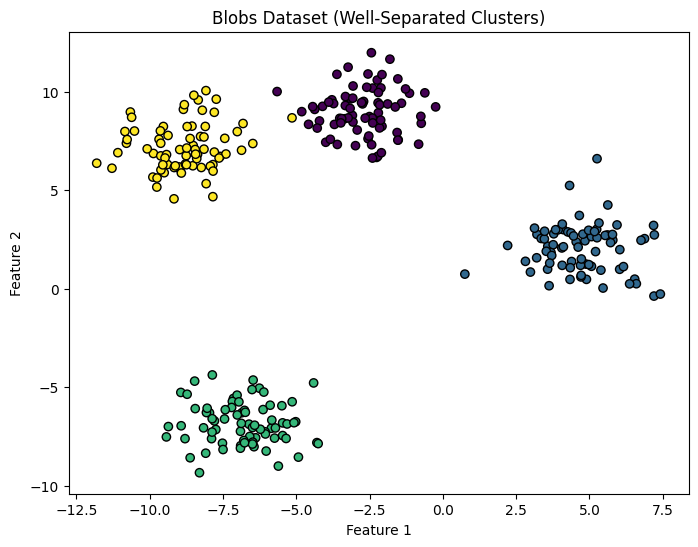

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, edgecolor='k')
plt.title('Blobs Dataset (Well-Separated Clusters)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

The data is quite well separated so most algorithms should be able to get a high accuracy!

Now we will analise the distribution of the features

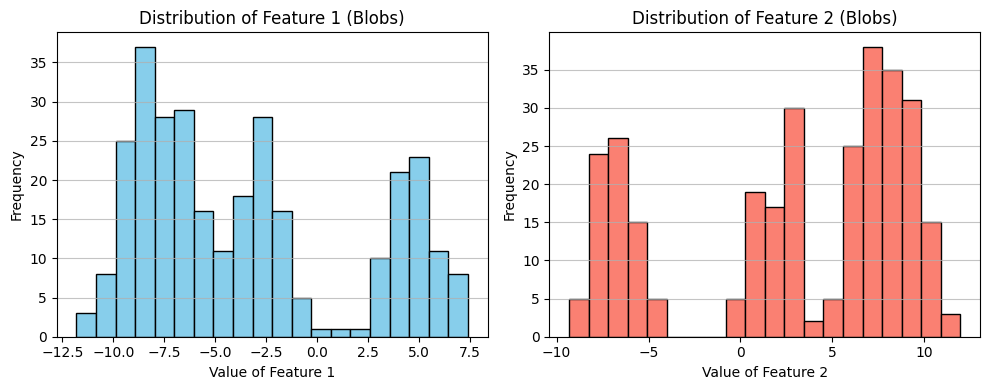

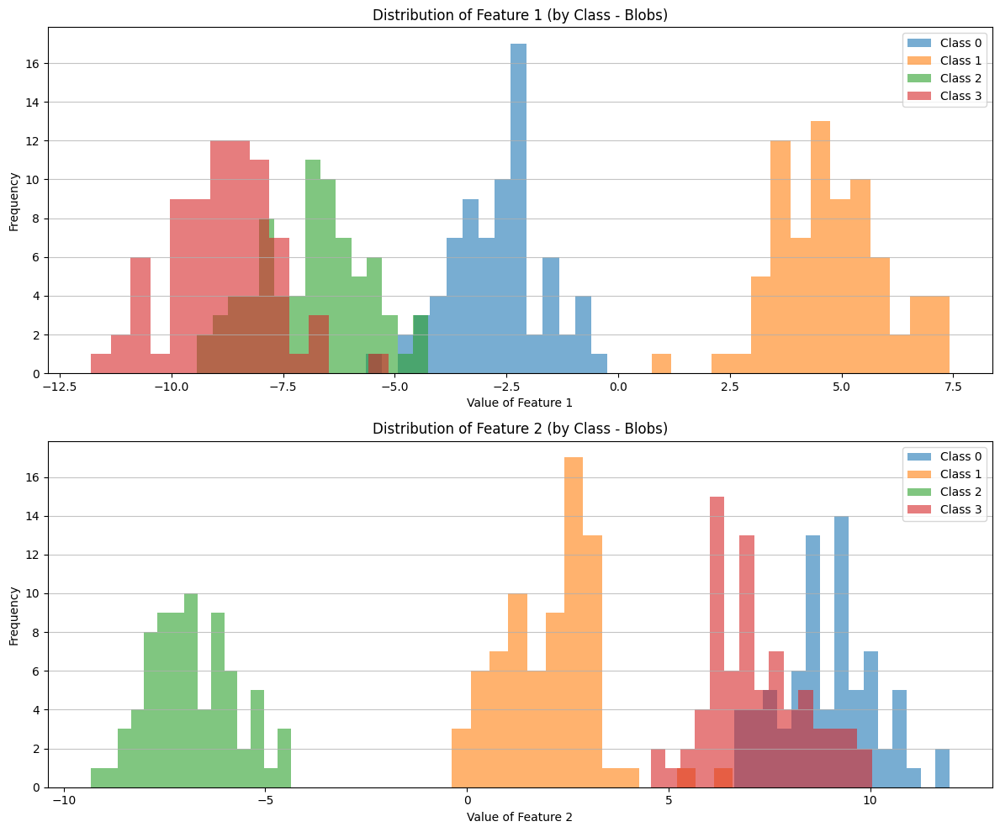

In [5]:
import numpy as np

# Feature Distribution plot

# Feature 1
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(X_blobs[:, 0], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Feature 1 (Blobs)')
plt.xlabel('Value of Feature 1')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Feature 2
plt.subplot(1, 2, 2)
plt.hist(X_blobs[:, 1], bins=20, color='salmon', edgecolor='black')
plt.title('Distribution of Feature 2 (Blobs)')
plt.xlabel('Value of Feature 2')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

# Plotting Histograms with Class Separation
plt.figure(figsize=(12, 10))

# Feature 1
plt.subplot(2, 1, 1)
for i in np.unique(y_blobs):
    plt.hist(X_blobs[y_blobs == i, 0], bins=15, alpha=0.6, label=f'Class {i}')
plt.title('Distribution of Feature 1 (by Class - Blobs)')
plt.xlabel('Value of Feature 1')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)

# Feature 2
plt.subplot(2, 1, 2)
for i in np.unique(y_blobs):
    plt.hist(X_blobs[y_blobs == i, 1], bins=15, alpha=0.6, label=f'Class {i}')
plt.title('Distribution of Feature 2 (by Class - Blobs)')
plt.xlabel('Value of Feature 2')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

### 1.1.2. Splitting & Scaling

Since most algorithms require the data to be distributed around 0, we will now try to scale the data.

From last section we observed that the features of each class had almost a normal distribution, but since overall the features were not distributed normally we will be using min-max scaling (normalization)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

random_state = 1

X_train, X_test, y_train, y_test = train_test_split(X_blobs, y_blobs, test_size=0.3, random_state=random_state)

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

Now we plot this scaled data

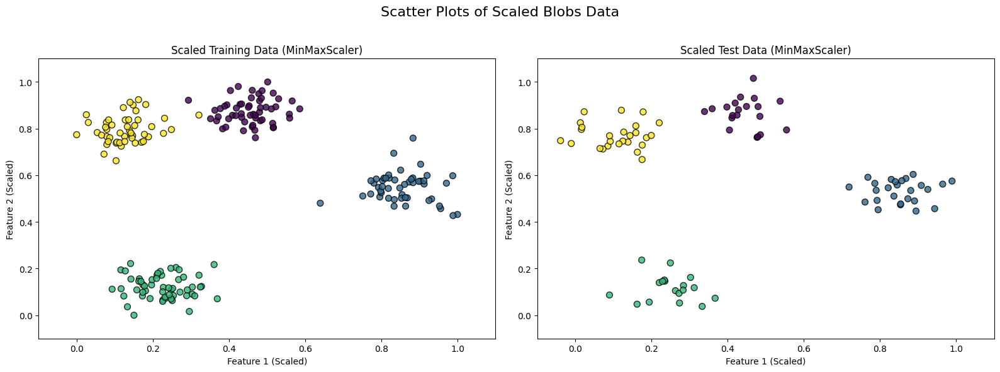

In [7]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap='viridis', edgecolor='k', s=50, alpha=0.8)
plt.title('Scaled Training Data (MinMaxScaler)')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)

plt.subplot(1, 2, 2)
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, cmap='viridis', edgecolor='k', s=50, alpha=0.8)
plt.title('Scaled Test Data (MinMaxScaler)')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)

plt.suptitle('Scatter Plots of Scaled Blobs Data', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 1.1.3. Feature Selection/Engineering

Since there are only two features and both seem to be quite informative, there is no need for this part! :)

## 1.2. Model Training and Hyperparamter Tuning

### 1.2.1. Preceptron

#### 1.2.1.1. Training

Here we will train a simple preceptron and tune its parameters, since the data is almost linearly seperable, we excpect the preceptron to get a very high accuracy.

In [8]:
from sklearn.linear_model import Perceptron
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay


print("--- Training Perceptron on Blobs Dataset ---")
print("\n1. Training a baseline Perceptron model...")
perceptron_base = Perceptron(random_state=random_state)
perceptron_base.fit(X_train_scaled, y_train)

# Make predictions
y_pred_base = perceptron_base.predict(X_test_scaled)
base_accuracy = accuracy_score(y_test, y_pred_base)
print(f"Baseline Perceptron Accuracy: {base_accuracy:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test, y_pred_base))



--- Training Perceptron on Blobs Dataset ---

1. Training a baseline Perceptron model...
Baseline Perceptron Accuracy: 0.9778
Baseline Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        20
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00        18
           3       0.93      1.00      0.96        26

    accuracy                           0.98        90
   macro avg       0.98      0.97      0.98        90
weighted avg       0.98      0.98      0.98        90



As we can see, withough any heyperparameter tuning the preceptron already achieved a 98% accuracy, so there isn't much need for hepyer parameter tuning but we will do it anyway in the next section.

#### 1.2.1.2. Hyperparameter Tuning

To improve the preformance even further (if we look at the test data, we can see it can theoretically be seperated using lines) we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardell of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters found: {'alpha': 0.0001, 'eta0': 0.0001, 'max_iter': 1000, 'penalty': 'l1'}

3. Evaluating the tuned Perceptron model...
Tuned Perceptron Accuracy: 1.0000
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        26

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90

Tuned Model Confusion Matrix:


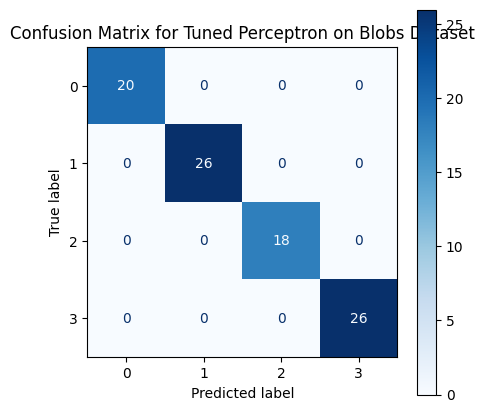

In [9]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

# eta0: learning rate
# max_iter: number of epochs
# penalty: regularization term (l1, l2, or elasticnet)
# alpha: regularization strength
param_grid_perceptron = {
    'eta0': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'max_iter': [1000, 2000, 3000],
    'penalty': ['l2', 'l1', 'elasticnet', None],
    'alpha': [0.0001, 0.001, 0.01]
}

grid_search = GridSearchCV(Perceptron(random_state=random_state), param_grid_perceptron, cv=5, n_jobs=-1, verbose=1)

grid_search.fit(X_train_scaled, y_train)

print("\nBest parameters found:", grid_search.best_params_)
best_perceptron = grid_search.best_estimator_


print("\n3. Evaluating the tuned Perceptron model...")
y_pred_tuned = best_perceptron.predict(X_test_scaled)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"Tuned Perceptron Accuracy: {tuned_accuracy:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_estimator(best_perceptron, X_test_scaled, y_test, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Perceptron on Blobs Dataset')
plt.show()

As we can see after tuning the hyperparameters and using a small learning rate and l1 regularization, we were able to get a perfect accuracy score on the test data!

which was expected given the linearly seperable nature of the data.

#### 1.2.1.3. Visualising the Predictions

Since we had only two features, we will use a code simillar to the one in the book to visualise the decision boundraies of the predictions.


4. Visualizing the Decision Boundary...


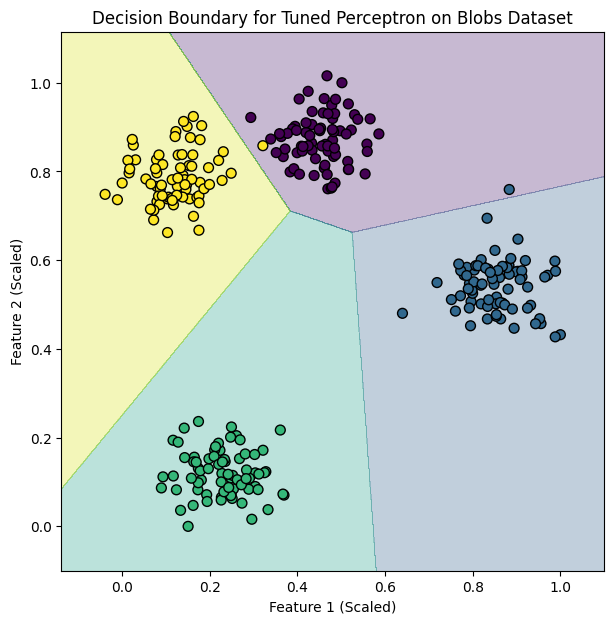

In [10]:
print("\n4. Visualizing the Decision Boundary...")

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.001),
                         np.arange(y_min, y_max, 0.001))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 7))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolor='k', cmap='viridis')
    plt.title(title)
    plt.xlabel('Feature 1 (Scaled)')
    plt.ylabel('Feature 2 (Scaled)')
    plt.show()

X_blobs_scaled = np.vstack((X_train_scaled, X_test_scaled))
y_blobs_combined = np.hstack((y_train, y_test))

plot_decision_boundary(best_perceptron, X_blobs_scaled, y_blobs_combined,
                       'Decision Boundary for Tuned Perceptron on Blobs Dataset')

From the picture above we can see the boundries of the prediction, there are two instances that have been mispredicted but since they were in the training dataset and not in the test dataset the accuracy of the model on the training dataset was 100%!

### 1.2.2. Logistic Regression

#### 1.2.2.1. Training

Here we will train a simple logistic regression and tune its parameters, since the data is almost linearly seperable, we excpect the logistic regression to get a very high accuracy.

In [11]:
from sklearn.linear_model import LogisticRegression
print("--- Training Logistic Regression on Blobs Dataset ---")

print("\n1. Training a baseline Logistic Regression model...")
log_reg_base = LogisticRegression(random_state=random_state, max_iter=1000)
log_reg_base.fit(X_train_scaled, y_train)

y_pred_base_lr = log_reg_base.predict(X_test_scaled)
base_accuracy_lr = accuracy_score(y_test, y_pred_base_lr)
print(f"Baseline Logistic Regression Accuracy: {base_accuracy_lr:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test, y_pred_base_lr))


--- Training Logistic Regression on Blobs Dataset ---

1. Training a baseline Logistic Regression model...
Baseline Logistic Regression Accuracy: 1.0000
Baseline Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        26

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



As we can see, the model already seperates everything perfectely but to get snse of what are its parameters we will still perform the hyperparametere tuning (mainly because I've already got the code :) )

#### 1.2.2.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardell of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best parameters found: {'C': 1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}

3. Evaluating the tuned Logistic Regression model...
Tuned Logistic Regression Accuracy: 1.0000
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        26

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90

Tuned Model Confusion Matrix:


/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/smani24/Desktop/Repositories/Machine-Learning-Course-Homework/MLenv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warning

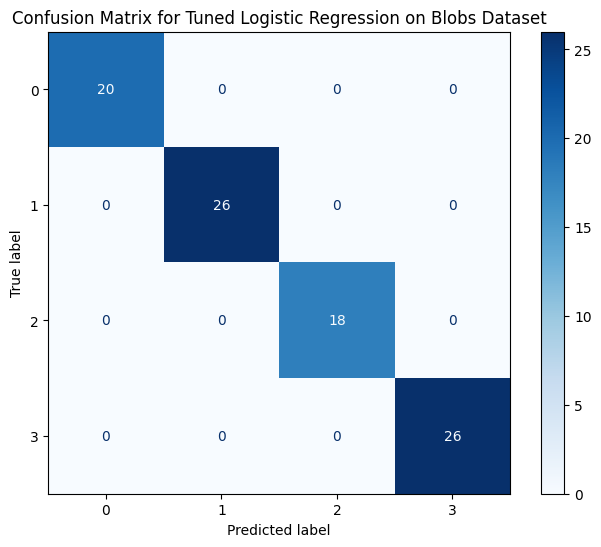

In [12]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_lr = [
    {
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear'],
        'max_iter': [1000, 2000]
    },
    {
        'penalty': ['l2', 'elasticnet'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['saga'],
        'l1_ratio': [0.5],
        'max_iter': [1000, 2000]
    }
]


grid_search_lr = GridSearchCV(LogisticRegression(random_state=random_state),
                              param_grid_lr, cv=5, n_jobs=-1, verbose=1)

grid_search_lr.fit(X_train_scaled, y_train)

print("\nBest parameters found:", grid_search_lr.best_params_)
best_log_reg = grid_search_lr.best_estimator_


print("\n3. Evaluating the tuned Logistic Regression model...")
y_pred_tuned_lr = best_log_reg.predict(X_test_scaled)
tuned_accuracy_lr = accuracy_score(y_test, y_pred_tuned_lr)

print(f"Tuned Logistic Regression Accuracy: {tuned_accuracy_lr:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned_lr))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_log_reg, X_test_scaled, y_test, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Logistic Regression on Blobs Dataset')
plt.show()


Again the model predicts all the labels perfectly with an accuracy of 100% (as excpected from the linearly seperable nature of the data), which is showen in the desicion boundy below.

#### 1.2.2.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundraies of the predictions.


4. Visualizing the Decision Boundary...


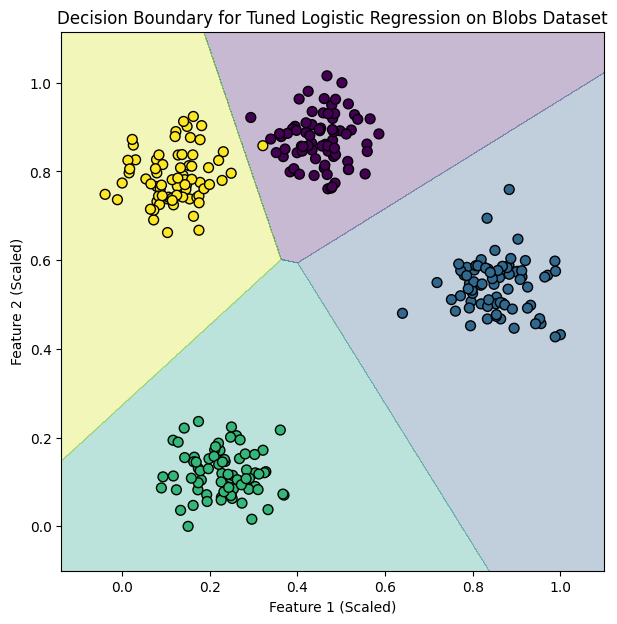

In [13]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_log_reg, X_blobs_scaled, y_blobs_combined,
                       'Decision Boundary for Tuned Logistic Regression on Blobs Dataset')

From the picture above we can see the boundries of the prediction, there is only one instance that have been mispredicted but since that was in the training dataset and not in the test dataset the accuracy of the model on the training dataset was 100%!

### 1.2.3. SVM (Without Kernel!)

#### 1.2.3.1. Training

Here we will train a simple SVM (with no kernels) and tune its parameters, since the data is almost linearly seperable, we excpect the svm to get a very high accuracy.

In [14]:
from sklearn.svm import SVC
print("--- Training Linear SVM on Blobs Dataset ---")

print("\n1. Training a baseline Linear SVM model...")
svm_base = SVC(kernel='linear', random_state=random_state)
svm_base.fit(X_train_scaled, y_train)

y_pred_base_svm = svm_base.predict(X_test_scaled)
base_accuracy_svm = accuracy_score(y_test, y_pred_base_svm)
print(f"Baseline Linear SVM Accuracy: {base_accuracy_svm:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test, y_pred_base_svm))

--- Training Linear SVM on Blobs Dataset ---

1. Training a baseline Linear SVM model...
Baseline Linear SVM Accuracy: 1.0000
Baseline Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        26

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



As we can see, just like the logistic regression SVM already seperates everything perfectely but to get snse of what are its parameters we will still perform the hyperparametere tuning (mainly because I've already got the code :) )

#### 1.2.3.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardell of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best parameters found: {'C': 1}

3. Evaluating the tuned Linear SVM model...
Tuned Linear SVM Accuracy: 1.0000
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        26

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90

Tuned Model Confusion Matrix:


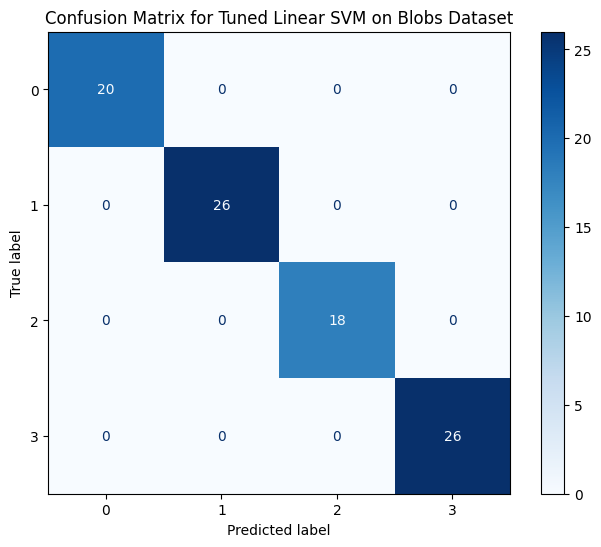

In [15]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

# 'C' is the regularization parameter. Lower C = stronger regularization (wider margin).
param_grid_svm = {
    'C': [0.1, 1, 10, 100, 1000]
}

grid_search_svm = GridSearchCV(SVC(kernel='linear', random_state=random_state),
                               param_grid_svm, cv=5, n_jobs=-1, verbose=1)

grid_search_svm.fit(X_train_scaled, y_train)

print("\nBest parameters found:", grid_search_svm.best_params_)
best_svm = grid_search_svm.best_estimator_


print("\n3. Evaluating the tuned Linear SVM model...")
y_pred_tuned_svm = best_svm.predict(X_test_scaled)
tuned_accuracy_svm = accuracy_score(y_test, y_pred_tuned_svm)

print(f"Tuned Linear SVM Accuracy: {tuned_accuracy_svm:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned_svm))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_svm, X_test_scaled, y_test, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Linear SVM on Blobs Dataset')
plt.show()

Again the model predicts all the labels perfectly with an accuracy of 100% (as excpected from the linearly seperable nature of the data), which is shown in the desicion boundry below.

#### 1.2.3.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundraies of the predictions.


4. Visualizing the Decision Boundary...


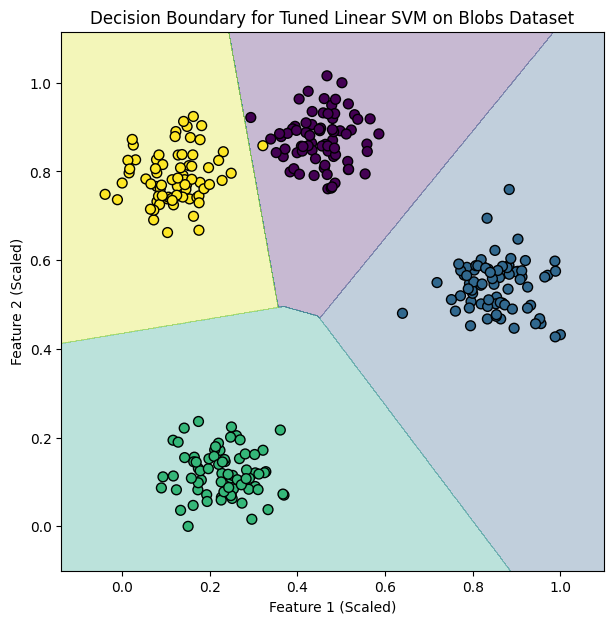

In [16]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_svm, X_blobs_scaled, y_blobs_combined,
                       'Decision Boundary for Tuned Linear SVM on Blobs Dataset')

From the picture above we can see the boundries of the prediction which are wider compared to logistic regression as SVM tries to maximise the boundries!

There is only one instance that have been mispredicted but since that was in the training dataset and not in the test dataset the accuracy of the model on the test dataset was 100%!

### 1.2.4. SVM (With Kernel!)

#### 1.2.4.1. Training

Here we will train a simple SVM (with rbf kernel) and tune its parameters, since the data is almost linearly seperable, we excpect the svm to get a very high accuracy.

In [17]:
print("--- Training Kernel SVM on Blobs Dataset ---")

print("\n1. Training a baseline Kernel SVM model (RBF kernel)...")
ksvm_base = SVC(random_state=random_state)
ksvm_base.fit(X_train_scaled, y_train)

y_pred_base_ksvm = ksvm_base.predict(X_test_scaled)
base_accuracy_ksvm = accuracy_score(y_test, y_pred_base_ksvm)
print(f"Baseline Kernel SVM Accuracy: {base_accuracy_ksvm:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test, y_pred_base_ksvm))

--- Training Kernel SVM on Blobs Dataset ---

1. Training a baseline Kernel SVM model (RBF kernel)...
Baseline Kernel SVM Accuracy: 1.0000
Baseline Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        26

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



As we can see, just like the logistic regression and the SVM with no kernel, kernel svm already separates everything perfectly but to get sense of what are its parameters we will still perform the hyperparameter tuning (mainly because I've already got the code :) )

#### 1.2.4.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameter, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Expanded Hyperparameter Tuning with GridSearchCV...
This may take a moment as we are testing multiple kernels and their parameters.
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters found: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}

3. Evaluating the tuned Kernel SVM model...
Tuned Kernel SVM Accuracy: 1.0000
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        26

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90

Tuned Model Confusion Matrix:


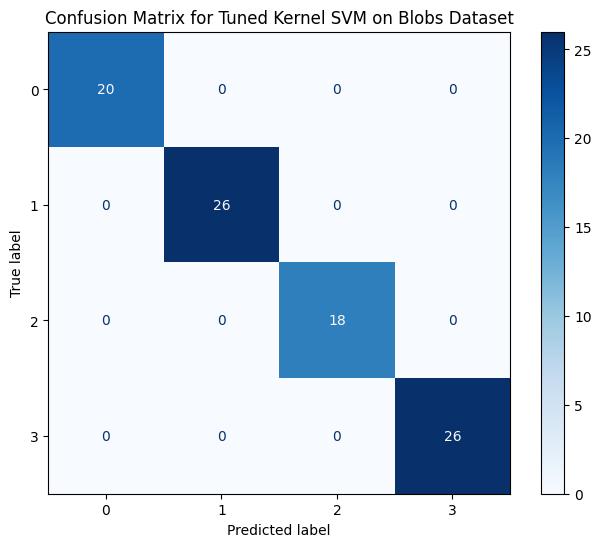

In [18]:
print("\n2. Performing Expanded Hyperparameter Tuning with GridSearchCV...")
print("This may take a moment as we are testing multiple kernels and their parameters.")

param_grid_ksvm_expanded = [
    {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 1, 0.1, 0.01],
        'kernel': ['rbf']
    },
    {
        'C': [0.1, 1, 10, 100],
        'degree': [2, 3, 4],
        'kernel': ['poly']
    },
    {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto'],
        'kernel': ['sigmoid']
    }
]

grid_search_ksvm = GridSearchCV(SVC(random_state=random_state),
                                param_grid_ksvm_expanded, cv=5, n_jobs=-1, verbose=1)

grid_search_ksvm.fit(X_train_scaled, y_train)

print("\nBest parameters found:", grid_search_ksvm.best_params_)
best_ksvm = grid_search_ksvm.best_estimator_


print("\n3. Evaluating the tuned Kernel SVM model...")
y_pred_tuned_ksvm = best_ksvm.predict(X_test_scaled)
tuned_accuracy_ksvm = accuracy_score(y_test, y_pred_tuned_ksvm)

print(f"Tuned Kernel SVM Accuracy: {tuned_accuracy_ksvm:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned_ksvm))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_ksvm, X_test_scaled, y_test, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Kernel SVM on Blobs Dataset')
plt.show()

Again the model predicts all the labels perfectly with an accuracy of 100% (as expected from the linearly separable nature of the data) and the use of kernel wasn't really necessary this is shown in the desicion boundry below.

#### 1.2.4.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundaries of the predictions.


4. Visualizing the Decision Boundary...


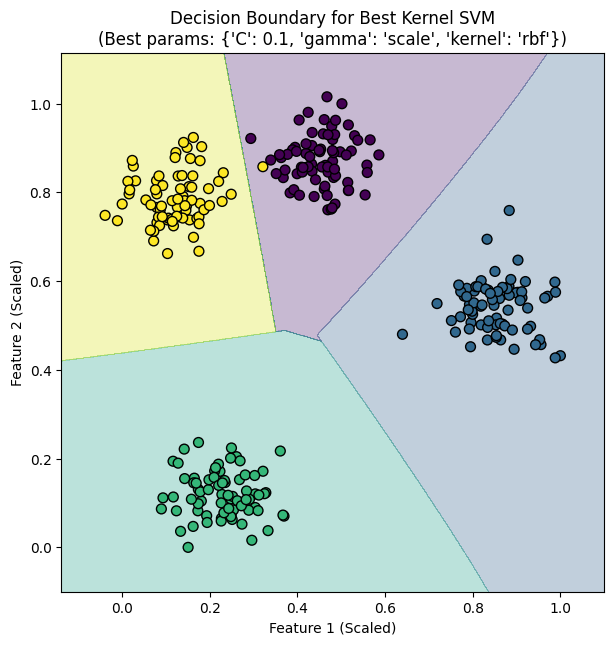

In [19]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_ksvm, X_blobs_scaled, y_blobs_combined,
                       f'Decision Boundary for Best Kernel SVM\n(Best params: {grid_search_ksvm.best_params_})')

From the boundaries we can see that despite the use of kernel, the data is still almost separated with lines showing that there was not a need for kernel (as seen perviously in normal SVM)

There is only one instance that have been mis-predicted but since that was in the training dataset and not in the test dataset the accuracy of the model on the test dataset was 100%!

### 1.2.5. Decision Tree

#### 1.2.5.1. Training

Here we will train a single decision tree and later tune its parameters, decision trees are quite prone to overfitting so in order to remedy this we need to carefully set the hyperparameters (or use random forests which is the next algorithm we will look at!)

Since the data is almost linearly separable, we expect the decision tree to get a very high accuracy.

In [20]:
from sklearn.tree import DecisionTreeClassifier
print("--- Training Decision Tree on Blobs Dataset ---")

print("\n1. Training a baseline Decision Tree model...")
dt_base = DecisionTreeClassifier(random_state=random_state)
dt_base.fit(X_train_scaled, y_train)

y_pred_base_dt = dt_base.predict(X_test_scaled)
base_accuracy_dt = accuracy_score(y_test, y_pred_base_dt)
print(f"Baseline Decision Tree Accuracy: {base_accuracy_dt:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test, y_pred_base_dt))

--- Training Decision Tree on Blobs Dataset ---

1. Training a baseline Decision Tree model...
Baseline Decision Tree Accuracy: 1.0000
Baseline Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        26

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



As we can see, just like the previous methods, decision tree already separates everything perfectly but we will still write the code for hyperparameter tuning so that we can used it in other datasets (by coping and pasting it)

#### 1.2.5.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameter, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 160 candidates, totalling 800 fits

Best parameters found: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

3. Evaluating the tuned Decision Tree model...
Tuned Decision Tree Accuracy: 1.0000
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        26

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90

Tuned Model Confusion Matrix:


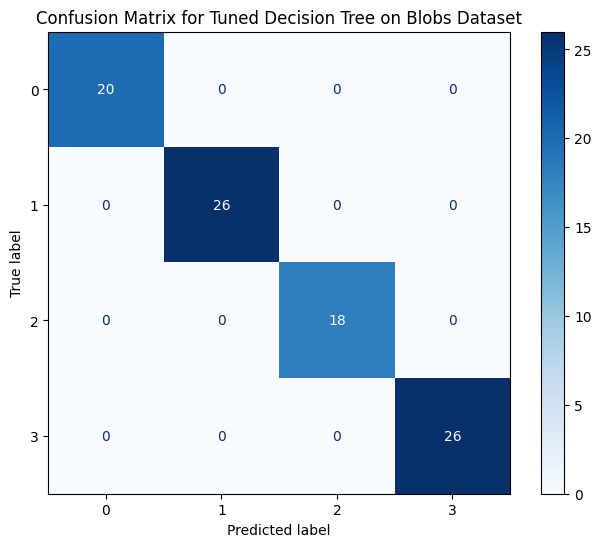

In [21]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

# criterion: The function to measure the quality of a split ('gini' or 'entropy').
# max_depth: The maximum depth of the tree. Controls overfitting.
# min_samples_split: The minimum number of samples required to split a node.
# min_samples_leaf: The minimum number of samples required at a leaf node.
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8]
}

grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=random_state),
                              param_grid_dt, cv=5, n_jobs=-1, verbose=1)

grid_search_dt.fit(X_train_scaled, y_train)

print("\nBest parameters found:", grid_search_dt.best_params_)
best_dt = grid_search_dt.best_estimator_


print("\n3. Evaluating the tuned Decision Tree model...")
y_pred_tuned_dt = best_dt.predict(X_test_scaled)
tuned_accuracy_dt = accuracy_score(y_test, y_pred_tuned_dt)

print(f"Tuned Decision Tree Accuracy: {tuned_accuracy_dt:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned_dt))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_dt, X_test_scaled, y_test, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Decision Tree on Blobs Dataset')
plt.show()

Again the model predicts all the labels perfectly with an accuracy of 100% (as expected from the linearly separable nature of the data).

#### 1.2.5.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundaries of the predictions.


4. Visualizing the Decision Boundary...


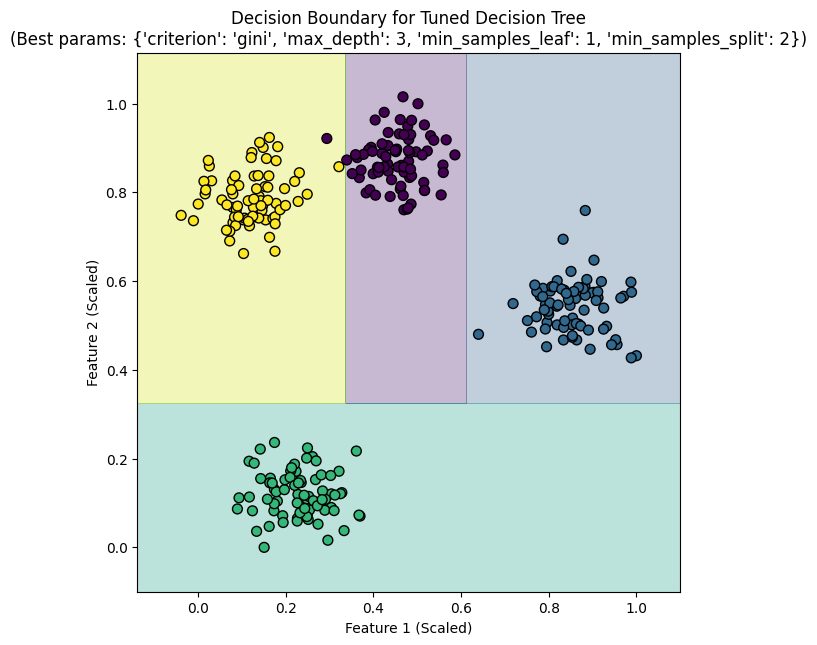

In [22]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_dt, X_blobs_scaled, y_blobs_combined,
                       f'Decision Boundary for Tuned Decision Tree\n(Best params: {grid_search_dt.best_params_})')

From the boundaries we can see that decision trees separate the data differently only using horizontal and vertical lines.

There is only one instance that have been mis-predicted but since that was in the training dataset and not in the test dataset the accuracy of the model on the test dataset was 100%!

### 1.2.6. Random Forest

#### 1.2.6.1. Training

Here we will train a random forest and later tune its parameters, random forest consist of multiple decision trees that have each been train of a portion of the data and then the final decision is made majority voting, the reason we use multiple decision trees is to prevent them from over fitting, another advantage of the random forest is the fact that it usually doesn't need much tuning.

Since the data is almost linearly separable, we expect the decision tree to get a very high accuracy.

In [23]:
from sklearn.ensemble import RandomForestClassifier
print("--- Training Random Forest on Blobs Dataset ---")

print("\n1. Training a baseline Random Forest model...")
rf_base = RandomForestClassifier(random_state=random_state, n_jobs=-1)
rf_base.fit(X_train_scaled, y_train)

y_pred_base_rf = rf_base.predict(X_test_scaled)
base_accuracy_rf = accuracy_score(y_test, y_pred_base_rf)
print(f"Baseline Random Forest Accuracy: {base_accuracy_rf:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test, y_pred_base_rf))

--- Training Random Forest on Blobs Dataset ---

1. Training a baseline Random Forest model...
Baseline Random Forest Accuracy: 1.0000
Baseline Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        26

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



As we can see, even the basic random forest without any tuning gets a perfect accuracy.

But we will still write the code for tuning the hyperparameters to be used on the other datasets as well (by cpying and pasting)

#### 1.2.6.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameter, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters found: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

3. Evaluating the tuned Random Forest model...
Tuned Random Forest Accuracy: 1.0000
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        26

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90

Tuned Model Confusion Matrix:


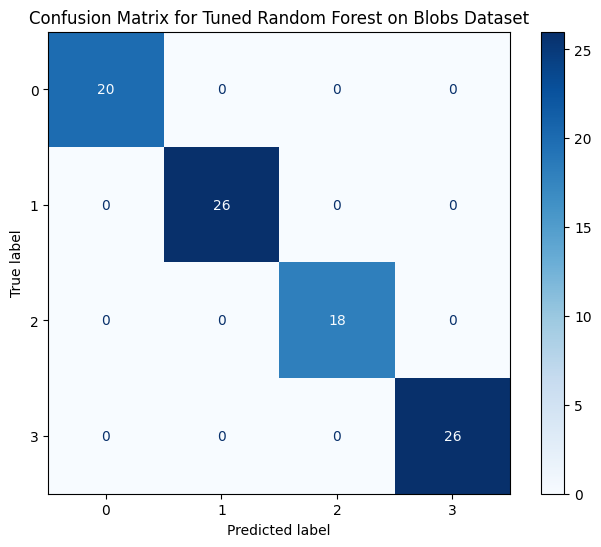

In [24]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_rf = {
    'n_estimators': [50, 100, 200, 300, 1000],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 7],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=random_state, n_jobs=-1),
                              param_grid_rf, cv=5, n_jobs=-1, verbose=1)

grid_search_rf.fit(X_train_scaled, y_train)

print("\nBest parameters found:", grid_search_rf.best_params_)
best_rf = grid_search_rf.best_estimator_


print("\n3. Evaluating the tuned Random Forest model...")
y_pred_tuned_rf = best_rf.predict(X_test_scaled)
tuned_accuracy_rf = accuracy_score(y_test, y_pred_tuned_rf)

print(f"Tuned Random Forest Accuracy: {tuned_accuracy_rf:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned_rf))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_rf, X_test_scaled, y_test, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Random Forest on Blobs Dataset')
plt.show()

Again the model predicts all the labels perfectly with an accuracy of 100% (as expected from the linearly separable nature of the data).

#### 1.2.6.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundaries of the predictions.


4. Visualizing the Decision Boundary...


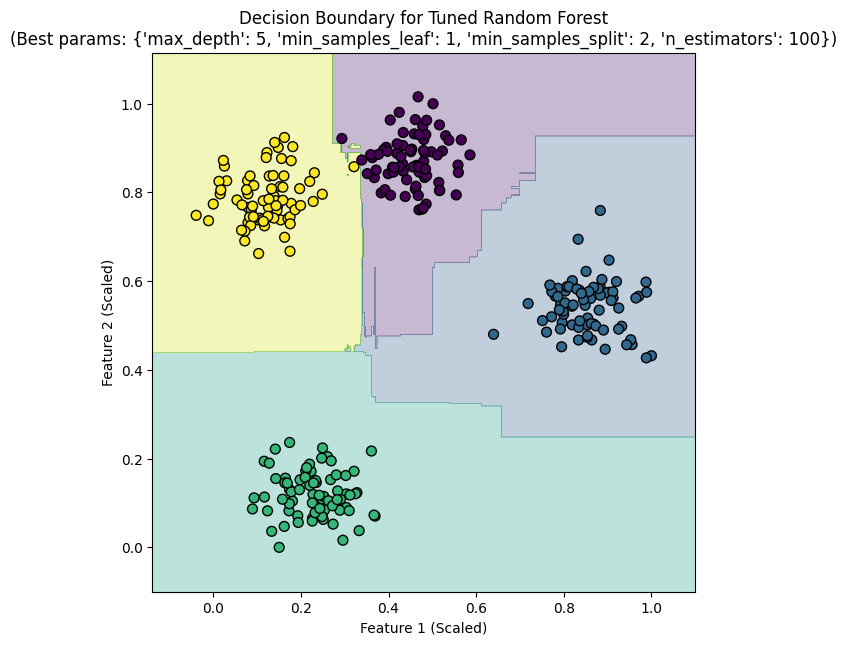

In [25]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_rf, X_blobs_scaled, y_blobs_combined,
                       f'Decision Boundary for Tuned Random Forest\n(Best params: {grid_search_rf.best_params_})')

One key differences between the decision boundaries of the random forest and other algorithms are the fact that since it's the result of voting, it can create much more complex boundaries.

Also this is the first algorithm that has managed to get every single datapoint in every class correctly (some of the previous algorithms had a 100% accuracy on the test data as well but they all had some misclassifications on the training data).

### 1.2.7. KNN

#### 1.2.7.1. Training

KNN is fundamentally different from all the previous models. It's a non-parametric algorithm, meaning it doesn't try to learn a model or a function from the training data. Instead, it memorizes the entire training dataset.

Since the classes in the data are well separated, we expect the KNN to get a very high accuracy.

In [26]:
from sklearn.neighbors import KNeighborsClassifier

print("--- Training K-Nearest Neighbors (KNN) on Blobs Dataset ---")

print("\n1. Training a baseline KNN model (K=5)...")
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_scaled, y_train)

y_pred_base_knn = knn_base.predict(X_test_scaled)
base_accuracy_knn = accuracy_score(y_test, y_pred_base_knn)
print(f"Baseline KNN Accuracy: {base_accuracy_knn:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test, y_pred_base_knn))

--- Training K-Nearest Neighbors (KNN) on Blobs Dataset ---

1. Training a baseline KNN model (K=5)...
Baseline KNN Accuracy: 1.0000
Baseline Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        26

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



As we can see, even the basic knn without any tuning gets a perfect accuracy.

But we will still write the code for tuning the hyperparameters to be used on the other datasets as well (by cpying and pasting)

#### 1.2.7.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameter, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters found: {'metric': 'euclidean', 'n_neighbors': 2, 'weights': 'uniform'}

3. Evaluating the tuned KNN model...
Tuned KNN Accuracy: 1.0000
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        26
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        26

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90

Tuned Model Confusion Matrix:


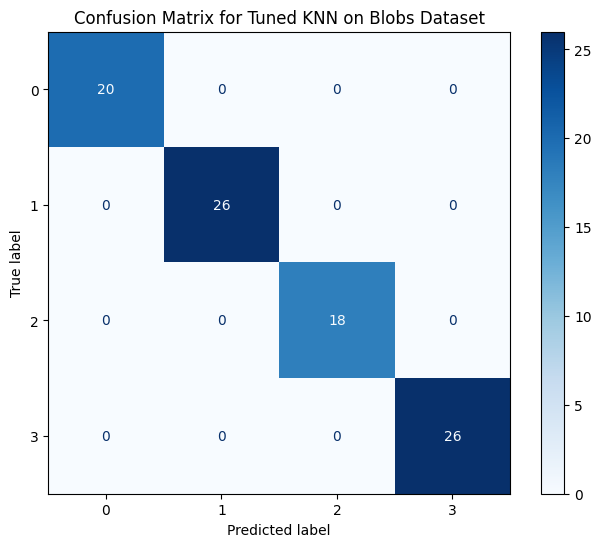

In [27]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_knn = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, n_jobs=-1, verbose=1)

grid_search_knn.fit(X_train_scaled, y_train)

print("\nBest parameters found:", grid_search_knn.best_params_)
best_knn = grid_search_knn.best_estimator_


print("\n3. Evaluating the tuned KNN model...")
y_pred_tuned_knn = best_knn.predict(X_test_scaled)
tuned_accuracy_knn = accuracy_score(y_test, y_pred_tuned_knn)

print(f"Tuned KNN Accuracy: {tuned_accuracy_knn:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned_knn))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_knn, X_test_scaled, y_test, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned KNN on Blobs Dataset')
plt.show()

Again the model predicts all the labels perfectly with an accuracy of 100% (Which was excpected by looking at the data distribution).

#### 1.2.7.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundaries of the predictions.


4. Visualizing the Decision Boundary...


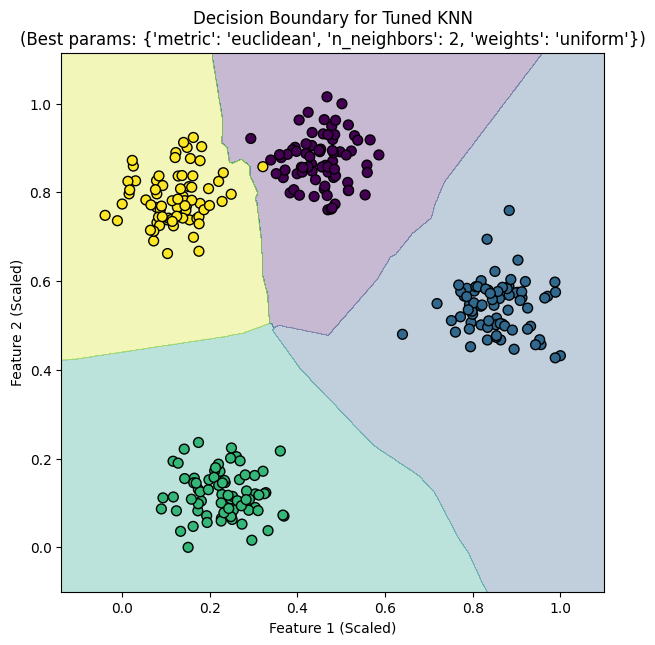

In [28]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_knn, X_blobs_scaled, y_blobs_combined,
                       f'Decision Boundary for Tuned KNN\n(Best params: {grid_search_knn.best_params_})')

Here we can see the non linear boundaries of the knn, since it measures the distance from other points in the class as upposed to ftting lines like other algorithms

# 2. Classification (Informative vs. Redundant Features)

## 2.1. Data Preprocessing

### 2.1.1. Creating the Dataset and Visualising

In [29]:
from sklearn.datasets import make_classification
X_class, y_class = make_classification(n_samples=500, n_features=10,
                                       n_informative=5, n_redundant=2,
                                       n_clusters_per_class=2, random_state=12)

In [30]:
X_class.shape

(500, 10)

In [31]:
y_class.shape

(500,)

Visualizing data with 10 features directly using a simple 2D or 3D scatter plot isn't feasible because we can only perceive 2 or 3 dimensions easily. So to visualise this data, we will use dimensionality reduction techniques (PCA).

X_class_pca shape after PCA: (500, 2)
Explained variance ratio by 2 components: [0.3041008 0.17364  ]
Total explained variance by 2 components: 0.4777


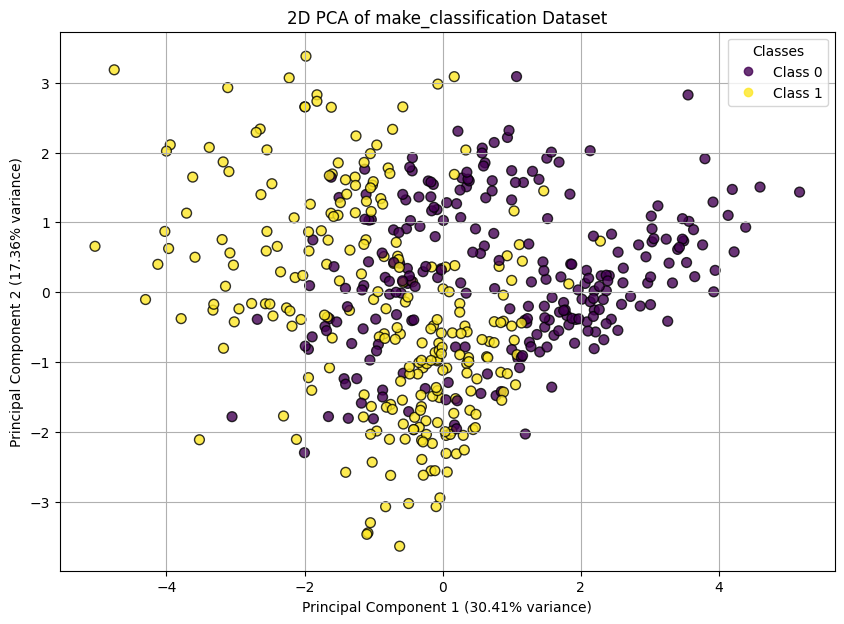


Total explained variance by 3 components: 0.5892


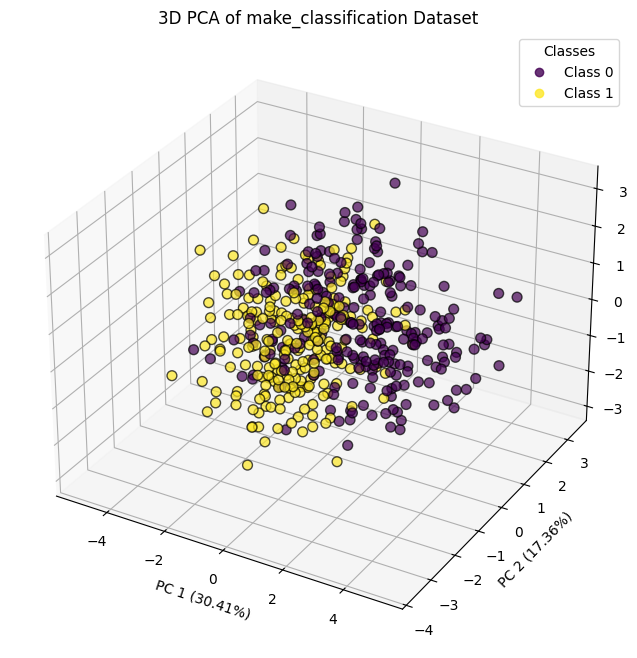

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# PCA is affected by scale, so you need to scale the features before applying PCA.
scaler = StandardScaler()
X_class_scaled = scaler.fit_transform(X_class)

pca = PCA(n_components=2, random_state=42)
X_class_pca = pca.fit_transform(X_class_scaled)

print(f"X_class_pca shape after PCA: {X_class_pca.shape}")
print(f"Explained variance ratio by 2 components: {pca.explained_variance_ratio_}")
print(f"Total explained variance by 2 components: {np.sum(pca.explained_variance_ratio_):.4f}")

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_class_pca[:, 0], X_class_pca[:, 1], c=y_class, cmap='viridis', edgecolor='k', s=50, alpha=0.8)
plt.title('2D PCA of make_classification Dataset')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.grid(True)

handles, labels = scatter.legend_elements()
if len(np.unique(y_class)) == 2:
    class_labels = [f'Class {i}' for i in np.unique(y_class)]
else:
    class_labels = [f'Class {i}' for i in np.unique(y_class)]

plt.legend(handles, class_labels, title="Classes")
plt.show()

# Visualizing with 3 Principal Components (3D plot)

pca_3d = PCA(n_components=3, random_state=42)
X_class_pca_3d = pca_3d.fit_transform(X_class_scaled)

print(f"\nTotal explained variance by 3 components: {np.sum(pca_3d.explained_variance_ratio_):.4f}")

fig_3d = plt.figure(figsize=(10, 8))
ax = fig_3d.add_subplot(111, projection='3d')
scatter_3d = ax.scatter(X_class_pca_3d[:, 0], X_class_pca_3d[:, 1], X_class_pca_3d[:, 2],
                        c=y_class, cmap='viridis', edgecolor='k', s=50, alpha=0.7)

ax.set_title('3D PCA of make_classification Dataset')
ax.set_xlabel(f'PC 1 ({pca_3d.explained_variance_ratio_[0]*100:.2f}%)')
ax.set_ylabel(f'PC 2 ({pca_3d.explained_variance_ratio_[1]*100:.2f}%)')
ax.set_zlabel(f'PC 3 ({pca_3d.explained_variance_ratio_[2]*100:.2f}%)')
ax.legend(handles, class_labels, title="Classes")
plt.show()

But as we can see, using only 2 or 3 components, isn't really enough to completely septate the classes (visually) hence we need ML algorithms!

Now let's look at the distribution of the features:


--- Overall Feature Distributions ---


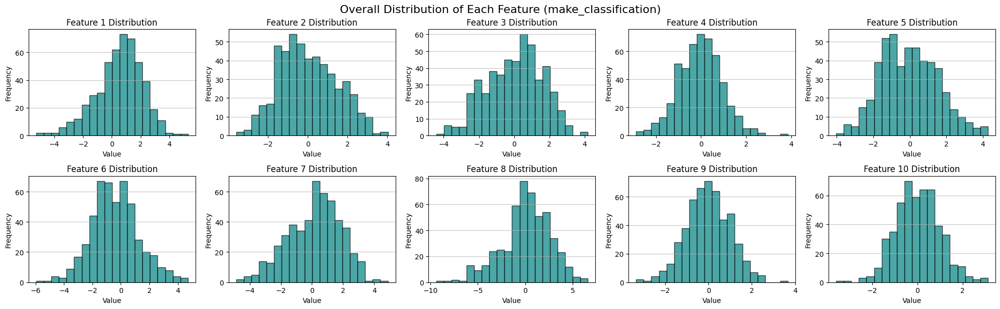


--- Feature Distributions by Class ---


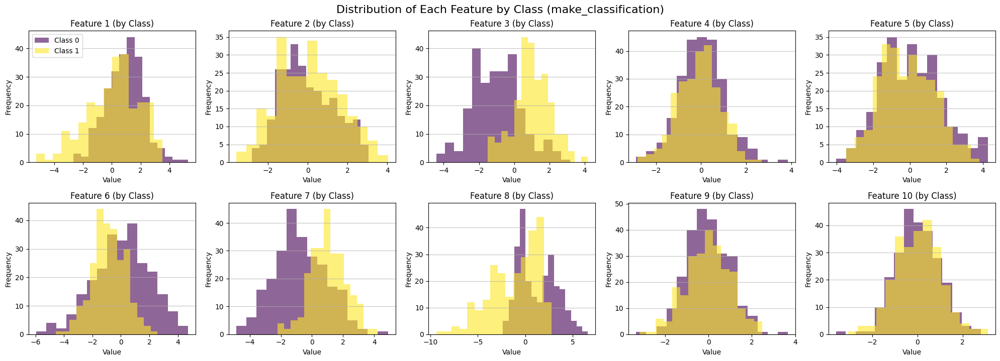

In [33]:
n_features = X_class.shape[1]

# --- Plotting Histograms for Each Feature (Overall Distribution) ---
print("\n--- Overall Feature Distributions ---")
n_cols = 5
n_rows = int(np.ceil(n_features / n_cols))

plt.figure(figsize=(n_cols * 4, n_rows * 3))
for i in range(n_features):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.hist(X_class[:, i], bins=20, color='teal', edgecolor='black', alpha=0.7)
    plt.title(f'Feature {i+1} Distribution')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.suptitle('Overall Distribution of Each Feature (make_classification)', fontsize=16, y=1.02)
plt.show()


# --- Plotting Histograms for Each Feature, Separated by Class ---
print("\n--- Feature Distributions by Class ---")
unique_classes = np.unique(y_class)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_classes)))

plt.figure(figsize=(n_cols * 4, n_rows * 3.5))
for i in range(n_features):
    plt.subplot(n_rows, n_cols, i + 1)
    for cls_idx, cls in enumerate(unique_classes):
        plt.hist(X_class[y_class == cls, i], bins=15, alpha=0.6, label=f'Class {cls}', color=colors[cls_idx])
    plt.title(f'Feature {i+1} (by Class)')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    if i == 0 :
        plt.legend()
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.suptitle('Distribution of Each Feature by Class (make_classification)', fontsize=16, y=1.02)
plt.show()

Unlike last dataset, here the features closely follow a normal distribution, so it's better to use a standard scaler.

Also we can notice that the distribution of features for the two classes closely coincide with each other, which can make it difficult to distinguish between the two.

### 2.1.2. Splitting & Scaling

Now we will split the data and scale it using a standard scaler.

In [34]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.3, random_state=random_state
)

scaler_class = StandardScaler()

scaler_class.fit(X_train_class)

X_train_class_scaled = scaler_class.transform(X_train_class)
X_test_class_scaled = scaler_class.transform(X_test_class)

## 2.2. Model Training and Hyperparamter Tuning

### 2.2.1. Preceptron

#### 2.2.1.1. Training

Here we will train a simple preceptron and tune its parameters, this time due to the high dimensionality of the dataset we don't know much about weather or not it can be lindearly seperated, so we will have to use the reults of the model to evalute this (according to the book it can be proven that if the data is linearly seperable, preceptron will be able to find the solution!)

In [35]:
print("--- Training Perceptron on Classification Dataset ---")

print("\n1. Training a baseline Perceptron model...")
perceptron_class_base = Perceptron(random_state=random_state)
perceptron_class_base.fit(X_train_class_scaled, y_train_class)

y_pred_class_base = perceptron_class_base.predict(X_test_class_scaled)
base_accuracy_class = accuracy_score(y_test_class, y_pred_class_base)
print(f"Baseline Perceptron Accuracy: {base_accuracy_class:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_class, y_pred_class_base))

--- Training Perceptron on Classification Dataset ---

1. Training a baseline Perceptron model...
Baseline Perceptron Accuracy: 0.6867
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.68      0.68        72
           1       0.70      0.69      0.70        78

    accuracy                           0.69       150
   macro avg       0.69      0.69      0.69       150
weighted avg       0.69      0.69      0.69       150



The model achieved a 69% accuracy which suggests the data isn't very well seperated but to be sure we used the model to its full capacity we will tune the hyperparameters the same way as before in the next section.

#### 2.2.1.2. Hyperparameter Tuning

Here to get the best result we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardelss of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters found: {'alpha': 0.01, 'eta0': 0.001, 'max_iter': 1000, 'penalty': 'l1'}

3. Evaluating the tuned Perceptron model...
Tuned Perceptron Accuracy: 0.6667
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.31      0.47        72
           1       0.61      1.00      0.76        78

    accuracy                           0.67       150
   macro avg       0.80      0.65      0.61       150
weighted avg       0.80      0.67      0.62       150

Tuned Model Confusion Matrix:


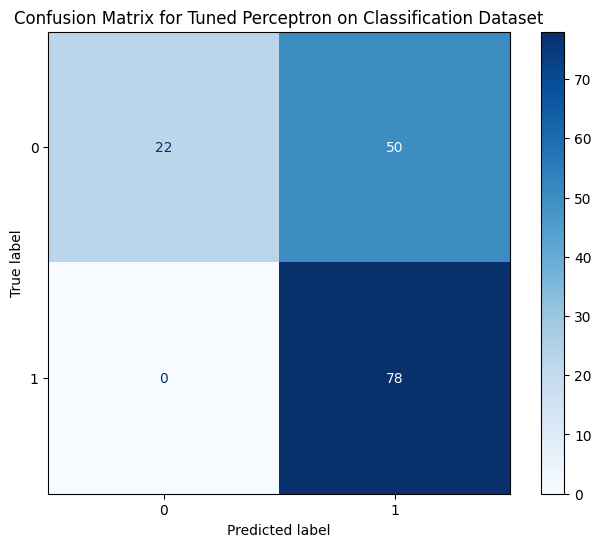

In [36]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_perceptron = {
    'eta0': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'max_iter': [1000, 2000, 3000],
    'penalty': ['l2', 'l1', 'elasticnet', None],
    'alpha': [0.0001, 0.001, 0.01]
}

grid_search_class = GridSearchCV(Perceptron(random_state=random_state), param_grid_perceptron, cv=5, n_jobs=-1, verbose=1)
grid_search_class.fit(X_train_class_scaled, y_train_class)

print("\nBest parameters found:", grid_search_class.best_params_)
best_perceptron_class = grid_search_class.best_estimator_


print("\n3. Evaluating the tuned Perceptron model...")
y_pred_class_tuned = best_perceptron_class.predict(X_test_class_scaled)
tuned_accuracy_class = accuracy_score(y_test_class, y_pred_class_tuned)

print(f"Tuned Perceptron Accuracy: {tuned_accuracy_class:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_class, y_pred_class_tuned))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_perceptron_class, X_test_class_scaled, y_test_class, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Perceptron on Classification Dataset')
plt.show()

The preformance of the model didn't show any improvements and in fact it got worse, suggesting that preceptron lacks the complexety requried to model this data.

From the confustion matrix we can see the model predicted all of the instances of class 1 correctly but had truble distinguishing the instances of class 0 (hence the 1 precision and 0.31 recall!)

#### 2.2.1.3. Visualising the Predictions

Since the dataset had a higher than 3 dimension, the desicion boundries couldn't be visualised (and using dimentionality reduction methods for visualisation wouldn't yield any meaningful results!)

### 2.2.2. Logistic Regression

#### 2.2.2.1. Training

Here we will train a simple logistic regression and tune its parameters, since the data was relatively seperable (judging by the performance of the perceptron _ 70% accuracy and f1-score) we excpect to also get at least 70% accuracy (since logistic regression usually performs better than perceptron)

In [37]:
print("--- Training Logistic Regression on Classification Dataset ---")

print("\n1. Training a baseline Logistic Regression model...")
log_reg_class_base = LogisticRegression(random_state=random_state, max_iter=1000)
log_reg_class_base.fit(X_train_class_scaled, y_train_class)

y_pred_class_base_lr = log_reg_class_base.predict(X_test_class_scaled)
base_accuracy_class_lr = accuracy_score(y_test_class, y_pred_class_base_lr)
print(f"Baseline Logistic Regression Accuracy: {base_accuracy_class_lr:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_class, y_pred_class_base_lr))

--- Training Logistic Regression on Classification Dataset ---

1. Training a baseline Logistic Regression model...
Baseline Logistic Regression Accuracy: 0.8067
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        72
           1       0.81      0.82      0.82        78

    accuracy                           0.81       150
   macro avg       0.81      0.81      0.81       150
weighted avg       0.81      0.81      0.81       150



As excpected the baseline logistic regression outperformed the perceptron by getting a 81% accuracy and f1-score, next we will try to tune the parameters to see if we can improve this even further.

#### 2.2.2.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardell of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}

3. Evaluating the tuned Logistic Regression model...
Tuned Logistic Regression Accuracy: 0.7867
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.75      0.77        72
           1       0.78      0.82      0.80        78

    accuracy                           0.79       150
   macro avg       0.79      0.79      0.79       150
weighted avg       0.79      0.79      0.79       150

Tuned Model Confusion Matrix:


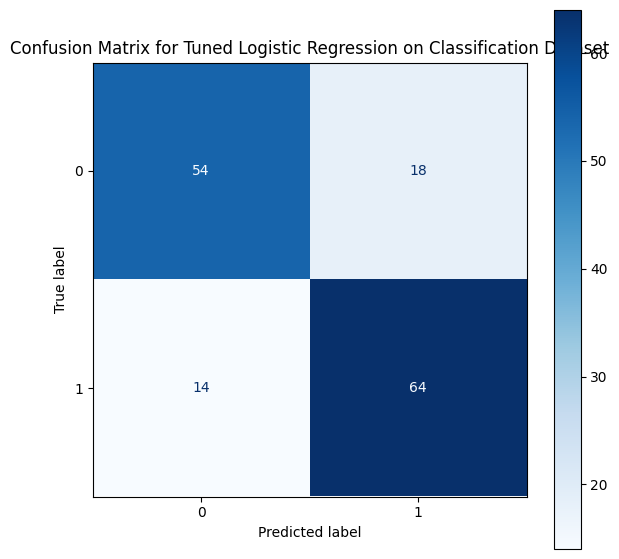

In [38]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_lr = [
    {
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000, 2000]
    },
    {
        'penalty': ['elasticnet'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['saga'],
        'l1_ratio': [0.5],
        'max_iter': [1000, 2000]
    }
]

grid_search_class_lr = GridSearchCV(LogisticRegression(random_state=random_state),
                                    param_grid_lr, cv=5, n_jobs=-1, verbose=1)
grid_search_class_lr.fit(X_train_class_scaled, y_train_class)

print("\nBest parameters found:", grid_search_class_lr.best_params_)
best_log_reg_class = grid_search_class_lr.best_estimator_


print("\n3. Evaluating the tuned Logistic Regression model...")
y_pred_class_tuned_lr = best_log_reg_class.predict(X_test_class_scaled)
tuned_accuracy_class_lr = accuracy_score(y_test_class, y_pred_class_tuned_lr)

print(f"Tuned Logistic Regression Accuracy: {tuned_accuracy_class_lr:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_class, y_pred_class_tuned_lr))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay.from_estimator(best_log_reg_class, X_test_class_scaled, y_test_class, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Logistic Regression on Classification Dataset')
plt.show()

As we can see, the ruslts after testing different hyper parameters are quite simillar to the baseline model, indicating that this is the best result we can get for this dataset and we might need a non linear model for getting better results.

From the confusion matrix we an see that the predictions were relatively balanced (in the snese that not all error were in the same class), this can also be seen in precision and recall having close values

#### 2.2.2.3. Visualising the Predictions

Due to the high dimensionality of the data, it could not be visualised!

### 2.2.3. SVM (Without Kernel!)

#### 2.2.3.1. Training

Here we will train a simple SVM and tune its parameters, since the data was relatively seperable (judging by the performance of the perceptron _ 70% accuracy_ and logistic regression _ 79% accuracy) we excpect to also get round 75% accuracy (since logistic regression and SVM usually have a similar result (when not using kernels!))

In [39]:
print("--- Training Linear SVM on Classification Dataset ---")

print("\n1. Training a baseline Linear SVM model...")
svm_class_base = SVC(kernel='linear', random_state=random_state)
svm_class_base.fit(X_train_class_scaled, y_train_class)

y_pred_base_svm_class = svm_class_base.predict(X_test_class_scaled)
base_accuracy_svm_class = accuracy_score(y_test_class, y_pred_base_svm_class)
print(f"Baseline Linear SVM Accuracy: {base_accuracy_svm_class:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_class, y_pred_base_svm_class))

--- Training Linear SVM on Classification Dataset ---

1. Training a baseline Linear SVM model...
Baseline Linear SVM Accuracy: 0.8000
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.76      0.79        72
           1       0.79      0.83      0.81        78

    accuracy                           0.80       150
   macro avg       0.80      0.80      0.80       150
weighted avg       0.80      0.80      0.80       150



As excpected the baseline SVM outperformed the perceptron by getting a 80% accuracy and f1-score and had a similar outcome to logistic regression, next we will try to tune the parameters to see if we can improve this even further.

#### 2.2.3.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardell of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best parameters found: {'C': 10}

3. Evaluating the tuned Linear SVM model...
Tuned Linear SVM Accuracy: 0.8000
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.76      0.79        72
           1       0.79      0.83      0.81        78

    accuracy                           0.80       150
   macro avg       0.80      0.80      0.80       150
weighted avg       0.80      0.80      0.80       150

Tuned Model Confusion Matrix:


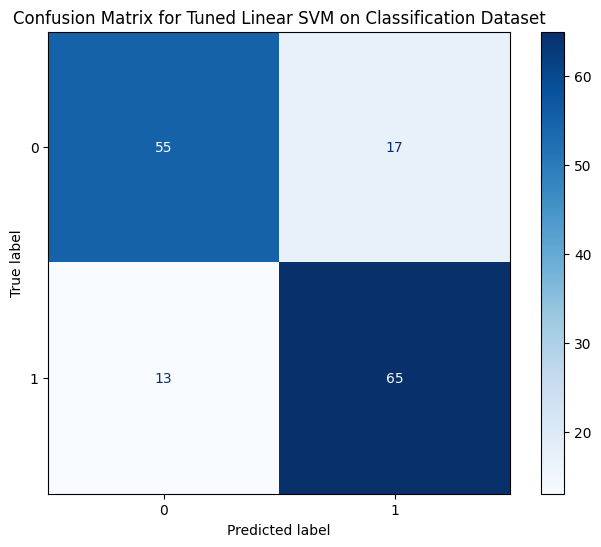

In [40]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_svm = {
    'C': [0.1, 1, 10, 100, 1000]
}

grid_search_svm_class = GridSearchCV(SVC(kernel='linear', random_state=random_state),
                                     param_grid_svm, cv=5, n_jobs=-1, verbose=1)

grid_search_svm_class.fit(X_train_class_scaled, y_train_class)

print("\nBest parameters found:", grid_search_svm_class.best_params_)
best_svm_class = grid_search_svm_class.best_estimator_


print("\n3. Evaluating the tuned Linear SVM model...")
y_pred_tuned_svm_class = best_svm_class.predict(X_test_class_scaled)
tuned_accuracy_svm_class = accuracy_score(y_test_class, y_pred_tuned_svm_class)

print(f"Tuned Linear SVM Accuracy: {tuned_accuracy_svm_class:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_class, y_pred_tuned_svm_class))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_svm_class, X_test_class_scaled, y_test_class, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Linear SVM on Classification Dataset')
plt.show()

As we can see, the ruslts after testing different hyper parameters are quite simillar to the baseline model, indicating that this is probably the best result we can get for this dataset and we might need a non linear model for getting better results.

From the confusion matrix we an see that the predictions were relatively balanced (in the snese that not all error were in the same class), this can also be seen in precision and recall having close values.

#### 2.2.3.3. Visualising the Predictions

Due to the high dimensionality of the data, it could not be visualised!

### 2.2.4. SVM (With Kernel!)

#### 2.2.4.1. Training

Here we will train a simple SVM and tune its parameters, since the data was relatively seperable (judging by the performance of the perceptron _ 70% accuracy_ and logistic regression _ 79% accuracy) we expect to get even better results when we use kernels, as introducing non-linearity may improve performance!

In [41]:
print("--- Training Kernel SVM on Classification Dataset ---")

print("\n1. Training a baseline Kernel SVM model (RBF kernel)...")
ksvm_class_base = SVC(random_state=random_state)
ksvm_class_base.fit(X_train_class_scaled, y_train_class)

y_pred_base_ksvm_class = ksvm_class_base.predict(X_test_class_scaled)
base_accuracy_ksvm_class = accuracy_score(y_test_class, y_pred_base_ksvm_class)
print(f"Baseline Kernel SVM Accuracy: {base_accuracy_ksvm_class:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_class, y_pred_base_ksvm_class))

--- Training Kernel SVM on Classification Dataset ---

1. Training a baseline Kernel SVM model (RBF kernel)...
Baseline Kernel SVM Accuracy: 0.8600
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85        72
           1       0.86      0.87      0.87        78

    accuracy                           0.86       150
   macro avg       0.86      0.86      0.86       150
weighted avg       0.86      0.86      0.86       150



As expected the baseline kernel SVM outperformed the normal one by getting a 86% accuracy and f1-score, next we will try to tune the parameters to see if we can improve this even further.

#### 2.2.4.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameter, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Expanded Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 77 candidates, totalling 385 fits

Best parameters found: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}

3. Evaluating the tuned Kernel SVM model...
Tuned Kernel SVM Accuracy: 0.8533
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        72
           1       0.86      0.86      0.86        78

    accuracy                           0.85       150
   macro avg       0.85      0.85      0.85       150
weighted avg       0.85      0.85      0.85       150

Tuned Model Confusion Matrix:


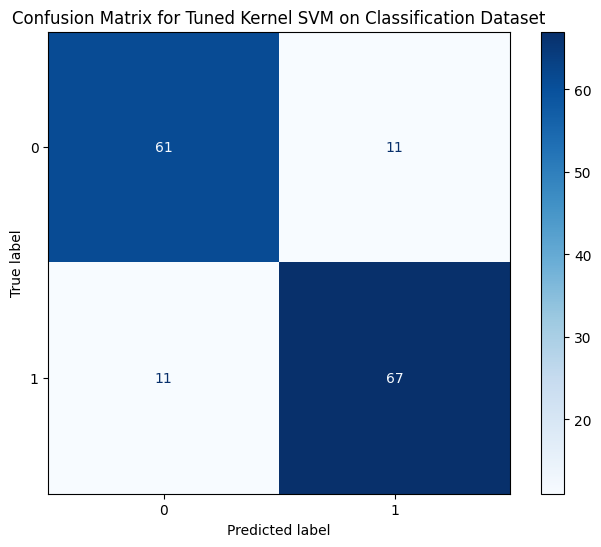

In [42]:
print("\n2. Performing Expanded Hyperparameter Tuning with GridSearchCV...")

param_grid_ksvm_expanded = [
    {'C': [0.001, 0.1, 1, 10, 100, 150, 1000], 'gamma': ['scale', 10, 1, 0.1, 0.01], 'kernel': ['rbf']},
    {'C': [0.001, 0.1, 1, 10, 100, 150, 1000], 'degree': [2, 3, 4, 5], 'kernel': ['poly']},
    {'C': [0.001, 0.1, 1, 10, 100, 150, 1000], 'gamma': ['scale', 'auto'], 'kernel': ['sigmoid']}
]

grid_search_ksvm_class = GridSearchCV(SVC(random_state=random_state),
                                      param_grid_ksvm_expanded, cv=5, n_jobs=-1, verbose=1)

grid_search_ksvm_class.fit(X_train_class_scaled, y_train_class)

print("\nBest parameters found:", grid_search_ksvm_class.best_params_)
best_ksvm_class = grid_search_ksvm_class.best_estimator_


print("\n3. Evaluating the tuned Kernel SVM model...")
y_pred_tuned_ksvm_class = best_ksvm_class.predict(X_test_class_scaled)
tuned_accuracy_ksvm_class = accuracy_score(y_test_class, y_pred_tuned_ksvm_class)

print(f"Tuned Kernel SVM Accuracy: {tuned_accuracy_ksvm_class:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_class, y_pred_tuned_ksvm_class))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_ksvm_class, X_test_class_scaled, y_test_class, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Kernel SVM on Classification Dataset')
plt.show()

As we can see, the rusts after testing different hyper parameters are quite similar to the baseline model, indicating that this is probably the best result we can get for this dataset and even with a non linear model, so in order to get better results we either have to use another type of non linearity (like neural networks) or different kernels!

From the confusion matrix we an see that the predictions were relatively balanced (in the sense that not all errors were in the same class), this can also be seen in precision and recall having close values.

#### 2.2.4.3. Visualising the Predictions

Due to the high dimensionality of the data, it could not be visualised!

### 2.2.5. Decision Tree

#### 2.2.5.1. Training

Here we will train a single decision tree and later tune its parameters, decision trees are quite prone to overfitting so in order to remedy this we need to carefully set the hyperparameters (or use random forests which is the next algorithm we will look at!)

since the data was relatively separable (judging by the performance of the perceptron _ 70% accuracy_ and logistic regression _ 79% accuracy and kernel SVM _ 86% accuracy) we expect to get around 80-90% accuracy, as introducing a different kind of non-linearity may improve performance!

In [43]:
print("--- Training Decision Tree on Classification Dataset ---")

print("\n1. Training a baseline Decision Tree model...")
dt_class_base = DecisionTreeClassifier(random_state=random_state)
dt_class_base.fit(X_train_class_scaled, y_train_class)

y_pred_base_dt_class = dt_class_base.predict(X_test_class_scaled)
base_accuracy_dt_class = accuracy_score(y_test_class, y_pred_base_dt_class)
print(f"Baseline Decision Tree Accuracy: {base_accuracy_dt_class:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_class, y_pred_base_dt_class))

--- Training Decision Tree on Classification Dataset ---

1. Training a baseline Decision Tree model...
Baseline Decision Tree Accuracy: 0.8467
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.84        72
           1       0.86      0.85      0.85        78

    accuracy                           0.85       150
   macro avg       0.85      0.85      0.85       150
weighted avg       0.85      0.85      0.85       150



The base decision tree model without any tuning managed to get an accuracy of 85% which is around the same as kernel SVM, next we will try to tune it and see if we can improve this.

#### 2.2.5.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameter, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 160 candidates, totalling 800 fits

Best parameters found: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}

3. Evaluating the tuned Decision Tree model...
Tuned Decision Tree Accuracy: 0.8133
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.72      0.79        72
           1       0.78      0.90      0.83        78

    accuracy                           0.81       150
   macro avg       0.82      0.81      0.81       150
weighted avg       0.82      0.81      0.81       150

Tuned Model Confusion Matrix:


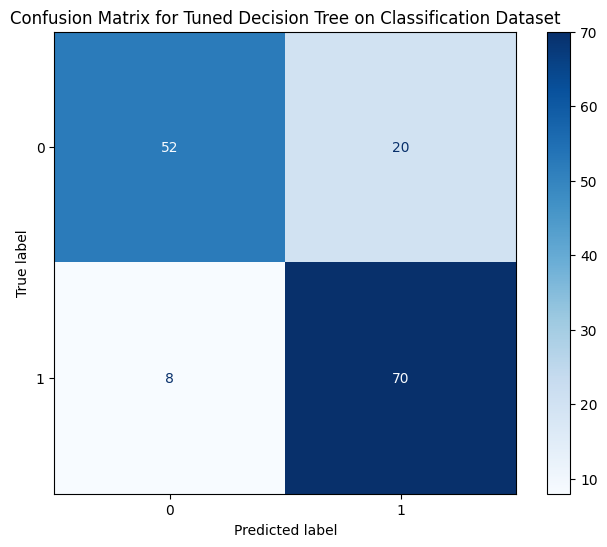

In [44]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8]
}

grid_search_dt_class = GridSearchCV(DecisionTreeClassifier(random_state=random_state),
                                    param_grid_dt, cv=5, n_jobs=-1, verbose=1)

grid_search_dt_class.fit(X_train_class_scaled, y_train_class)

print("\nBest parameters found:", grid_search_dt_class.best_params_)
best_dt_class = grid_search_dt_class.best_estimator_


print("\n3. Evaluating the tuned Decision Tree model...")
y_pred_tuned_dt_class = best_dt_class.predict(X_test_class_scaled)
tuned_accuracy_dt_class = accuracy_score(y_test_class, y_pred_tuned_dt_class)

print(f"Tuned Decision Tree Accuracy: {tuned_accuracy_dt_class:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_class, y_pred_tuned_dt_class))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_dt_class, X_test_class_scaled, y_test_class, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Decision Tree on Classification Dataset')
plt.show()

Unfortunately after tuning the performance of the model didn't really improve showing that even with boundaries like the decision trees we can't get any better results than kernel SVM.

From the confusion matrix we can see that most of the misclassifications were instances of class 0 being labeled as 1 which resulted in a lower precision.

#### 2.2.5.3. Visualising the Predictions

Due to the high dimensionality of the data, it could not be visualised!

### 2.2.6. Random Forest

#### 2.2.6.1. Training

Here we will train a random forest and later tune its parameters, random forest consist of multiple decision trees that have each been train of a portion of the data and then the final decision is made majority voting, the reason we use multiple decision trees is to prevent them from over fitting, another advantage of the random forest is the fact that it usually doesn't need much tuning.

since the data was relatively separable (judging by the performance of the perceptron _ 70% accuracy_ and logistic regression _ 79% accuracy and kernel SVM _ 86% accuracy) we expect to get around 80-90% accuracy, as introducing a different kind of non-linearity may improve performance!

In [45]:
print("--- Training Random Forest on Classification Dataset ---")

print("\n1. Training a baseline Random Forest model...")
rf_class_base = RandomForestClassifier(random_state=random_state, n_jobs=-1)
rf_class_base.fit(X_train_class_scaled, y_train_class)

y_pred_base_rf_class = rf_class_base.predict(X_test_class_scaled)
base_accuracy_rf_class = accuracy_score(y_test_class, y_pred_base_rf_class)
print(f"Baseline Random Forest Accuracy: {base_accuracy_rf_class:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_class, y_pred_base_rf_class))

--- Training Random Forest on Classification Dataset ---

1. Training a baseline Random Forest model...
Baseline Random Forest Accuracy: 0.8600
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.86        72
           1       0.87      0.86      0.86        78

    accuracy                           0.86       150
   macro avg       0.86      0.86      0.86       150
weighted avg       0.86      0.86      0.86       150



The base random forest model without any tuning managed to get an accuracy of 86% which is around the same as kernel SVM and a single decision tree indicating that there wasn't much need for using multiple trees in a random forest, next we will try to tune it and see if we can improve this.

#### 2.2.6.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameter, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters found: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 1000}

3. Evaluating the tuned Random Forest model...
Tuned Random Forest Accuracy: 0.8267
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82        72
           1       0.82      0.85      0.84        78

    accuracy                           0.83       150
   macro avg       0.83      0.83      0.83       150
weighted avg       0.83      0.83      0.83       150

Tuned Model Confusion Matrix:


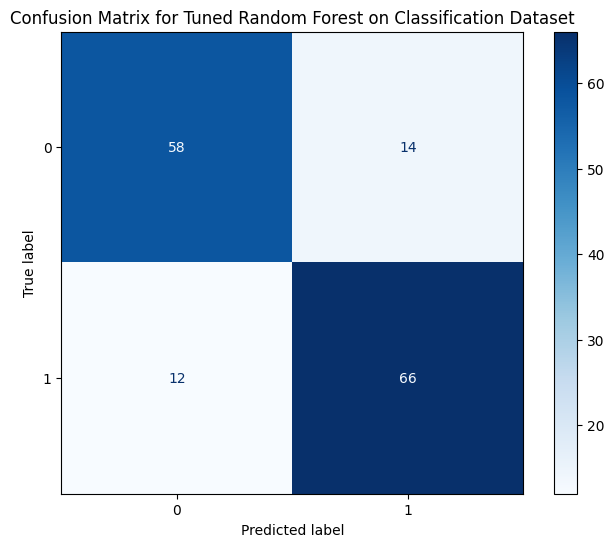

In [46]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")
print("WARNING: This is a very large grid search and will take a significant amount of time to complete.")

param_grid_rf = {
    'n_estimators': [50, 100, 200, 300, 1000],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 7],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf_class = GridSearchCV(RandomForestClassifier(random_state=random_state, n_jobs=-1),
                                    param_grid_rf, cv=5, n_jobs=-1, verbose=1)

grid_search_rf_class.fit(X_train_class_scaled, y_train_class)

print("\nBest parameters found:", grid_search_rf_class.best_params_)
best_rf_class = grid_search_rf_class.best_estimator_


print("\n3. Evaluating the tuned Random Forest model...")
y_pred_tuned_rf_class = best_rf_class.predict(X_test_class_scaled)
tuned_accuracy_rf_class = accuracy_score(y_test_class, y_pred_tuned_rf_class)

print(f"Tuned Random Forest Accuracy: {tuned_accuracy_rf_class:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_class, y_pred_tuned_rf_class))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_rf_class, X_test_class_scaled, y_test_class, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Random Forest on Classification Dataset')
plt.show()

Unfortunately after tuning the performance of the model didn't really improve showing that even with boundaries like the decision trees and using multiple of them we can't get any better results than kernel SVM.

From the confusion matrix we can see that unlike a single decision tree the misclassifications were distributed between the classes equally.

#### 2.2.6.3. Visualising the Predictions

Due to the high dimensionality of the data, it could not be visualised!

### 2.2.7. KNN

#### 2.2.7.1. Training

KNN is fundamentally different from all the previous models. It's a non-parametric algorithm, meaning it doesn't try to learn a model or a function from the training data. Instead, it memorizes the entire training dataset.

Since our dataset has a high dimension, there's a good chance that knn could be affected by the so called "curse of dimensionality" (as stated in the book), so we will have to try and see.

In [47]:
print("--- Training K-Nearest Neighbors (KNN) on Classification Dataset ---")

print("\n1. Training a baseline KNN model (K=5)...")
knn_class_base = KNeighborsClassifier(n_neighbors=5)
knn_class_base.fit(X_train_class_scaled, y_train_class)

y_pred_base_knn_class = knn_class_base.predict(X_test_class_scaled)
base_accuracy_knn_class = accuracy_score(y_test_class, y_pred_base_knn_class)
print(f"Baseline KNN Accuracy: {base_accuracy_knn_class:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_class, y_pred_base_knn_class))

--- Training K-Nearest Neighbors (KNN) on Classification Dataset ---

1. Training a baseline KNN model (K=5)...
Baseline KNN Accuracy: 0.8400
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.82        72
           1       0.81      0.90      0.85        78

    accuracy                           0.84       150
   macro avg       0.84      0.84      0.84       150
weighted avg       0.84      0.84      0.84       150



KNN had an acceptable performance of this dataset, it didn't quite manage to match the 100% accuracy of random forest and kernel SVM but it was better than the rest of the linear models, now we will try to tune the parameters to what works best. 

#### 2.2.7.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameter, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters found: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}

3. Evaluating the tuned KNN model...
Tuned KNN Accuracy: 0.8867
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88        72
           1       0.87      0.92      0.89        78

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150

Tuned Model Confusion Matrix:


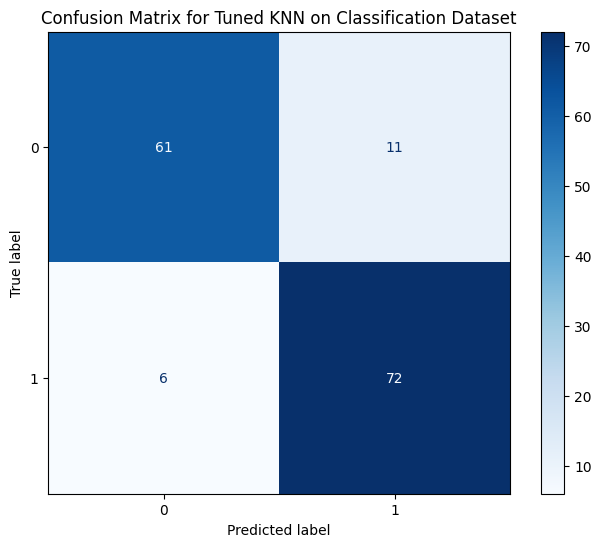

In [48]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_knn = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search_knn_class = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, n_jobs=-1, verbose=1)

grid_search_knn_class.fit(X_train_class_scaled, y_train_class)

print("\nBest parameters found:", grid_search_knn_class.best_params_)
best_knn_class = grid_search_knn_class.best_estimator_


print("\n3. Evaluating the tuned KNN model...")
y_pred_tuned_knn_class = best_knn_class.predict(X_test_class_scaled)
tuned_accuracy_knn_class = accuracy_score(y_test_class, y_pred_tuned_knn_class)

print(f"Tuned KNN Accuracy: {tuned_accuracy_knn_class:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_class, y_pred_tuned_knn_class))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_knn_class, X_test_class_scaled, y_test_class, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned KNN on Classification Dataset')
plt.show()

After tuning the parameters we managed to get a 89% accuracy by changing to the manhattan distance and taking 6 neighbours into consideration and using their distance as the weight.

But still despite the much heavier computation, it falls 10% short of other non linear models in this dataset.

#### 2.2.7.3. Visualising the Predictions

Due to the high dimensionality of the data, it could not be visualised!

# 3. Gaussian Quantiles (Concentric Class Boundaries)

## 3.1. Data Preprocessing

### 3.1.1. Creating the Dataset and Visualising

In [49]:
from sklearn.datasets import make_gaussian_quantiles
X_gaussian, y_gaussian = make_gaussian_quantiles(n_samples=500, n_features=2, n_classes=3, random_state=0)

In [50]:
X_gaussian.shape

(500, 2)

In [51]:
y_gaussian.shape

(500,)

The dataset contains 500 points with 2 features, so it can be easily visualised:

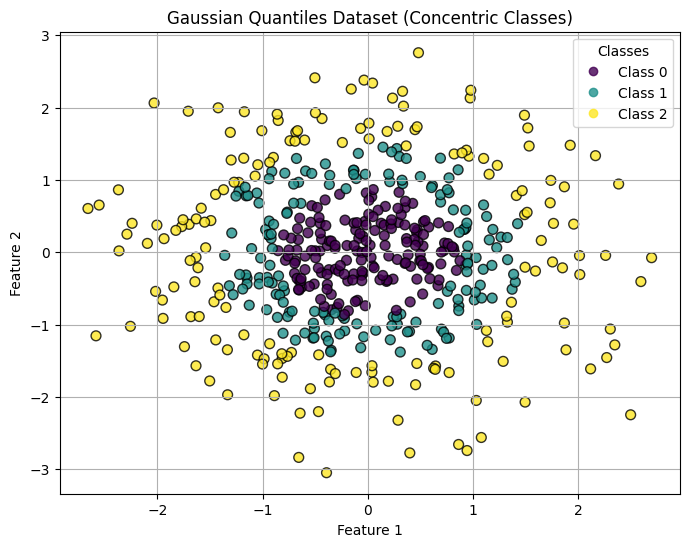

In [52]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_gaussian[:, 0], X_gaussian[:, 1], c=y_gaussian, cmap='viridis', edgecolor='k', s=50, alpha=0.8)

plt.title('Gaussian Quantiles Dataset (Concentric Classes)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)

handles, labels = scatter.legend_elements()
class_labels = [f'Class {i}' for i in np.unique(y_gaussian)]
plt.legend(handles, class_labels, title="Classes")

plt.show()

As expected (From the dataset name) the data consist of three classes concentric circles, this would make the job of linear algorithms (such as logistic regression, preceptron, ...) quite difficult __we will analyse each algorithm in detail in the coming sections_

Now let's take a look at the distribution of each feature:

--- Overall Feature Distributions (Gaussian Quantiles) ---


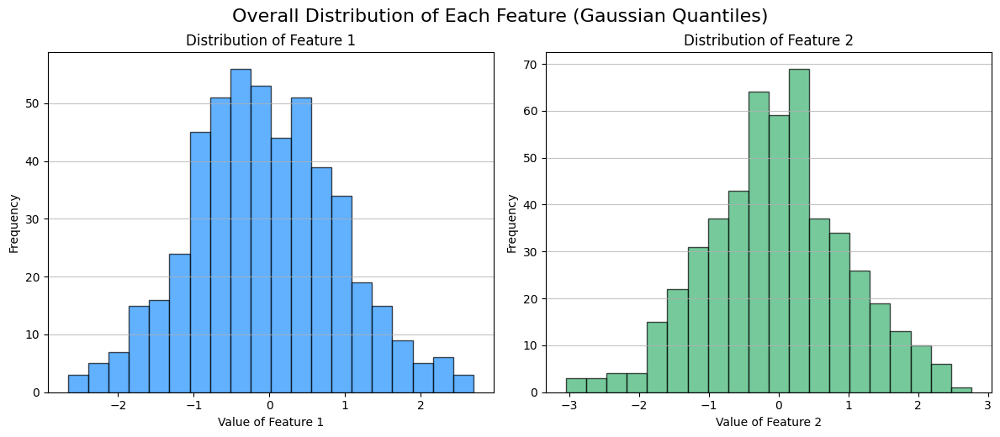


--- Feature Distributions by Class (Gaussian Quantiles) ---


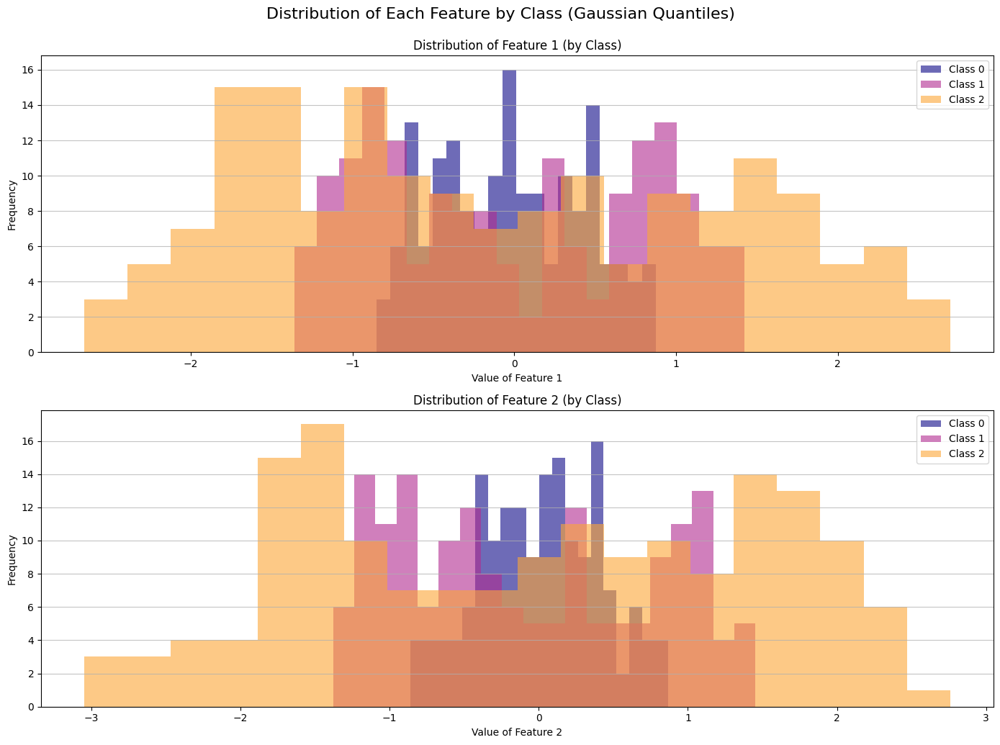

In [53]:
# --- Plotting Histograms for Each Feature (Overall Distribution) ---
print("--- Overall Feature Distributions (Gaussian Quantiles) ---")
plt.figure(figsize=(12, 5))

# Feature 1
plt.subplot(1, 2, 1)
plt.hist(X_gaussian[:, 0], bins=20, color='dodgerblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Feature 1')
plt.xlabel('Value of Feature 1')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Feature 2
plt.subplot(1, 2, 2)
plt.hist(X_gaussian[:, 1], bins=20, color='mediumseagreen', edgecolor='black', alpha=0.7)
plt.title('Distribution of Feature 2')
plt.xlabel('Value of Feature 2')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.suptitle('Overall Distribution of Each Feature (Gaussian Quantiles)', fontsize=16, y=1.03)
plt.show()


# --- Plotting Histograms for Each Feature, Separated by Class ---
print("\n--- Feature Distributions by Class (Gaussian Quantiles) ---")
unique_classes_gaussian = np.unique(y_gaussian)
colors_gaussian = plt.cm.plasma(np.linspace(0, 0.8, len(unique_classes_gaussian)))

plt.figure(figsize=(14, 10))

# Feature 1 with class separation
plt.subplot(2, 1, 1)
for cls_idx, cls in enumerate(unique_classes_gaussian):
    plt.hist(X_gaussian[y_gaussian == cls, 0], bins=20, alpha=0.6, label=f'Class {cls}', color=colors_gaussian[cls_idx])
plt.title('Distribution of Feature 1 (by Class)')
plt.xlabel('Value of Feature 1')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)

# Feature 2 with class separation
plt.subplot(2, 1, 2)
for cls_idx, cls in enumerate(unique_classes_gaussian):
    plt.hist(X_gaussian[y_gaussian == cls, 1], bins=20, alpha=0.6, label=f'Class {cls}', color=colors_gaussian[cls_idx])
plt.title('Distribution of Feature 2 (by Class)')
plt.xlabel('Value of Feature 2')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.suptitle('Distribution of Each Feature by Class (Gaussian Quantiles)', fontsize=16, y=1.03)
plt.show()

Like the last dataset, the features of this dataset also follow a normal distribtuion (this could have been guessed from the name as well!), so we will be using standardisation for scaling in the next section

### 3.1.2. Splitting & Scaling

Here we will split the data and scale it usinga sandardard sacaler

In [54]:
X_train_gaussian, X_test_gaussian, y_train_gaussian, y_test_gaussian = train_test_split(
    X_gaussian, y_gaussian, test_size=0.3, random_state=random_state, stratify=y_gaussian
)
scaler_gaussian = StandardScaler()

scaler_gaussian.fit(X_train_gaussian)

X_train_gaussian_scaled = scaler_gaussian.transform(X_train_gaussian)
X_test_gaussian_scaled = scaler_gaussian.transform(X_test_gaussian)

To verify the process we will plot it once again

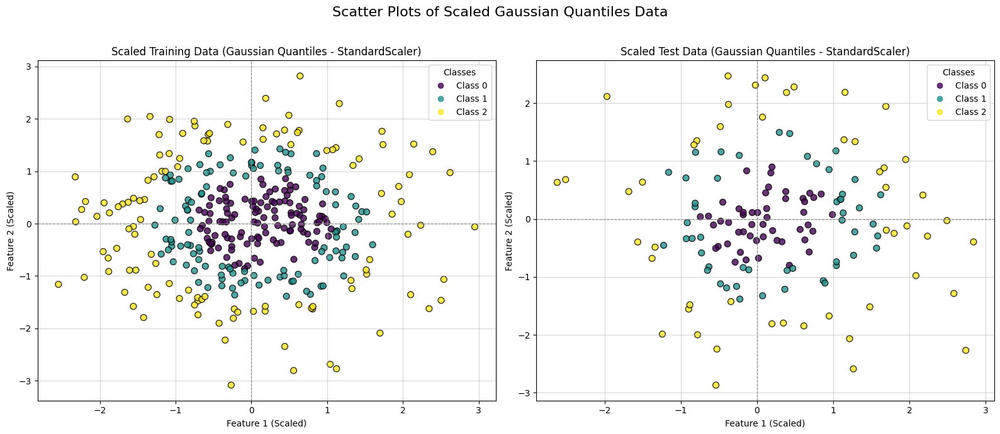

In [55]:
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
scatter_train = plt.scatter(X_train_gaussian_scaled[:, 0], X_train_gaussian_scaled[:, 1],
                            c=y_train_gaussian, cmap='viridis', edgecolor='k', s=50, alpha=0.8)
plt.title('Scaled Training Data (Gaussian Quantiles - StandardScaler)')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.axhline(0, color='grey', lw=0.8, linestyle='--')
plt.axvline(0, color='grey', lw=0.8, linestyle='--')
plt.grid(True, alpha=0.5)

handles_train, _ = scatter_train.legend_elements()
class_labels_train = [f'Class {i}' for i in np.unique(y_train_gaussian)]
plt.legend(handles_train, class_labels_train, title="Classes")

plt.subplot(1, 2, 2)
scatter_test = plt.scatter(X_test_gaussian_scaled[:, 0], X_test_gaussian_scaled[:, 1],
                           c=y_test_gaussian, cmap='viridis', edgecolor='k', s=50, alpha=0.8)
plt.title('Scaled Test Data (Gaussian Quantiles - StandardScaler)')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.axhline(0, color='grey', lw=0.8, linestyle='--')
plt.axvline(0, color='grey', lw=0.8, linestyle='--')
plt.grid(True, alpha=0.5)

handles_test, _ = scatter_test.legend_elements()
class_labels_test = [f'Class {i}' for i in np.unique(y_test_gaussian)]
plt.legend(handles_test, class_labels_test, title="Classes")


plt.suptitle('Scatter Plots of Scaled Gaussian Quantiles Data', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 3.2. Model Training and Hyperparamter Tuning

### 3.2.1. Preceptron

#### 3.2.1.1. Training

Here we will train a simple preceptron and tune its parameters, since the data isn't linearly seperable we don't have high excpections about the model's performance as preceptrons are linear model and work best with linearly seperable data.

In [56]:
print("--- Training Perceptron on Gaussian Quantiles Dataset ---")

print("\n1. Training a baseline Perceptron model...")
perceptron_gaussian_base = Perceptron(random_state=random_state)
perceptron_gaussian_base.fit(X_train_gaussian_scaled, y_train_gaussian)

y_pred_gaussian_base = perceptron_gaussian_base.predict(X_test_gaussian_scaled)
base_accuracy_gaussian = accuracy_score(y_test_gaussian, y_pred_gaussian_base)
print(f"Baseline Perceptron Accuracy: {base_accuracy_gaussian:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_gaussian, y_pred_gaussian_base))

--- Training Perceptron on Gaussian Quantiles Dataset ---

1. Training a baseline Perceptron model...
Baseline Perceptron Accuracy: 0.3333
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        50
           1       0.34      0.64      0.44        50
           2       0.42      0.36      0.39        50

    accuracy                           0.33       150
   macro avg       0.25      0.33      0.28       150
weighted avg       0.25      0.33      0.28       150



As excpected the baseline model had a very poor preformance with only 33% accuracy, next we will try to tune the hyperparameters

#### 3.2.1.2. Hyperparameter Tuning

To improve the preformance we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardell of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters found: {'alpha': 0.001, 'eta0': 1.0, 'max_iter': 1000, 'penalty': 'l2'}

3. Evaluating the tuned Perceptron model...
Tuned Perceptron Accuracy: 0.2600
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.28      0.24        50
           1       0.00      0.00      0.00        50
           2       0.30      0.50      0.38        50

    accuracy                           0.26       150
   macro avg       0.17      0.26      0.21       150
weighted avg       0.17      0.26      0.21       150

Tuned Model Confusion Matrix:


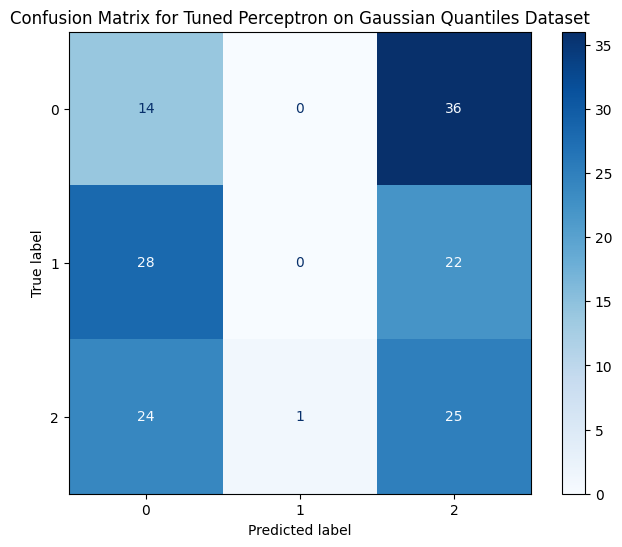

In [57]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_perceptron = {
    'eta0': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'max_iter': [1000, 2000, 3000],
    'penalty': ['l2', 'l1', 'elasticnet', None],
    'alpha': [0.0001, 0.001, 0.01]
}

grid_search_gaussian = GridSearchCV(Perceptron(random_state=random_state), param_grid_perceptron, cv=5, n_jobs=-1, verbose=1)
grid_search_gaussian.fit(X_train_gaussian_scaled, y_train_gaussian)

print("\nBest parameters found:", grid_search_gaussian.best_params_)
best_perceptron_gaussian = grid_search_gaussian.best_estimator_


print("\n3. Evaluating the tuned Perceptron model...")
y_pred_gaussian_tuned = best_perceptron_gaussian.predict(X_test_gaussian_scaled)
tuned_accuracy_gaussian = accuracy_score(y_test_gaussian, y_pred_gaussian_tuned)

print(f"Tuned Perceptron Accuracy: {tuned_accuracy_gaussian:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_gaussian, y_pred_gaussian_tuned, zero_division=0))


print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_perceptron_gaussian, X_test_gaussian_scaled, y_test_gaussian, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Perceptron on Gaussian Quantiles Dataset')
plt.show()

Preforming a grid search and tuning the hyperparameters didn't yield any results either, this is due to the nature of the data and the fact that they are quantiles of a gaussian distribution.

From the confusion matrix we can see the model didn't manage to detect even a single instance of class 1 correctly! and for the other two classed it had more wrong prediction than correct one! this is better ellustrated in the next section.

#### 3.2.1.3. Visualising the Predictions

Since we had only two features, we will use a code simillar to the one in the book to visualise the decision boundraies of the predictions.


4. Visualizing the Decision Boundary...


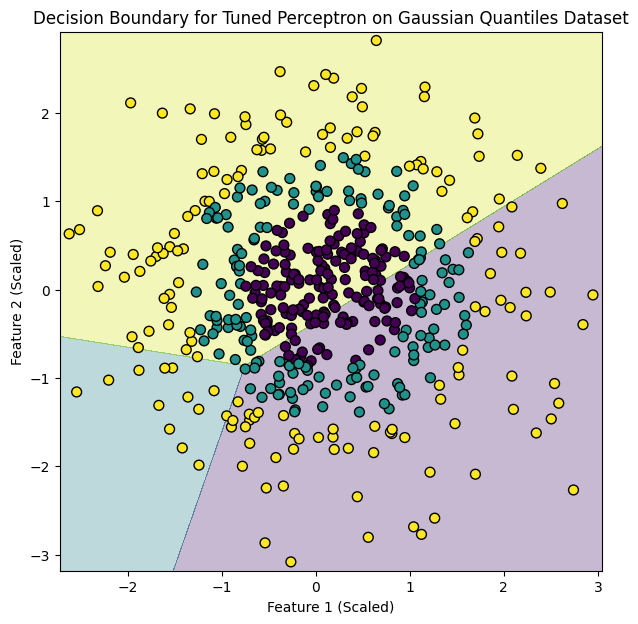

In [58]:
print("\n4. Visualizing the Decision Boundary...")

X_gaussian_scaled = np.vstack((X_train_gaussian_scaled, X_test_gaussian_scaled))
y_gaussian_combined = np.hstack((y_train_gaussian, y_test_gaussian))

plot_decision_boundary(best_perceptron_gaussian, X_gaussian_scaled, y_gaussian_combined,
                       'Decision Boundary for Tuned Perceptron on Gaussian Quantiles Dataset')

As we can see, the model has failed to seperate the data into three calsses using three lines, which was excpected. To get a better result we either need to change the model or use multiple preceptrons (simllar to MLP neural networks)

### 3.2.2. Logistic Regression

#### 3.2.2.1. Training

Just like the Perceptron, the linear nature of Logistic Regression means it will try to separate these classes with lines, thus we should expect it to perform poorly

In [59]:
print("--- Training Logistic Regression on Gaussian Quantiles Dataset ---")
print("NOTE: We expect the linear Logistic Regression model to perform poorly on this non-linear dataset.")

print("\n1. Training a baseline Logistic Regression model...")
log_reg_gaussian_base = LogisticRegression(random_state=random_state, max_iter=1000)
log_reg_gaussian_base.fit(X_train_gaussian_scaled, y_train_gaussian)

y_pred_gaussian_base_lr = log_reg_gaussian_base.predict(X_test_gaussian_scaled)
base_accuracy_gaussian_lr = accuracy_score(y_test_gaussian, y_pred_gaussian_base_lr)
print(f"Baseline Logistic Regression Accuracy: {base_accuracy_gaussian_lr:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_gaussian, y_pred_gaussian_base_lr, zero_division=0))

--- Training Logistic Regression on Gaussian Quantiles Dataset ---
NOTE: We expect the linear Logistic Regression model to perform poorly on this non-linear dataset.

1. Training a baseline Logistic Regression model...
Baseline Logistic Regression Accuracy: 0.3067
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.38      0.33        50
           1       0.32      0.16      0.21        50
           2       0.31      0.38      0.34        50

    accuracy                           0.31       150
   macro avg       0.31      0.31      0.30       150
weighted avg       0.31      0.31      0.30       150



The baseline logistic regression model got an accuracy of 31%, which is in the same ballpark of the preceptron's accuracy (33%), this is due to the nonlinear nature of the dataset showen in the previous sections.

Upnext we will try to improve its performance by tuning the hyperparameters.

#### 3.2.2.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardell of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}

3. Evaluating the tuned Logistic Regression model...
Tuned Logistic Regression Accuracy: 0.3067
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.40      0.35        50
           1       0.30      0.12      0.17        50
           2       0.31      0.40      0.35        50

    accuracy                           0.31       150
   macro avg       0.31      0.31      0.29       150
weighted avg       0.31      0.31      0.29       150

Tuned Model Confusion Matrix:


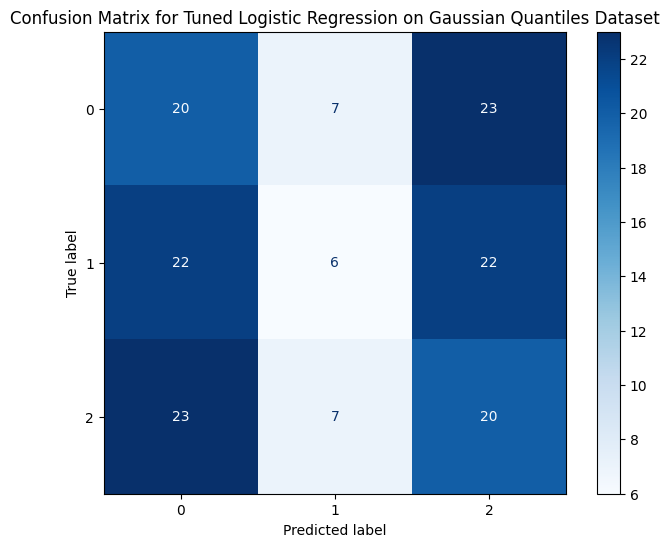

In [60]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_lr = [
    {
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000, 2000]
    },
    {
        'penalty': ['elasticnet'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['saga'],
        'l1_ratio': [0.5],
        'max_iter': [1000, 2000]
    }
]

grid_search_gaussian_lr = GridSearchCV(LogisticRegression(random_state=random_state),
                                       param_grid_lr, cv=5, n_jobs=-1, verbose=1)
grid_search_gaussian_lr.fit(X_train_gaussian_scaled, y_train_gaussian)

print("\nBest parameters found:", grid_search_gaussian_lr.best_params_)
best_log_reg_gaussian = grid_search_gaussian_lr.best_estimator_


print("\n3. Evaluating the tuned Logistic Regression model...")
y_pred_gaussian_tuned_lr = best_log_reg_gaussian.predict(X_test_gaussian_scaled)
tuned_accuracy_gaussian_lr = accuracy_score(y_test_gaussian, y_pred_gaussian_tuned_lr)

print(f"Tuned Logistic Regression Accuracy: {tuned_accuracy_gaussian_lr:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_gaussian, y_pred_gaussian_tuned_lr, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_log_reg_gaussian, X_test_gaussian_scaled, y_test_gaussian, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Logistic Regression on Gaussian Quantiles Dataset')
plt.show()



As we can see, even after trying different parameters the model didn't achieve any better results.

From the confusion matrix we can see that the model almos either predicts each data as class 0 or calss 2, something that is showen better in the next section.

#### 3.2.2.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundraies of the predictions.


4. Visualizing the Decision Boundary...


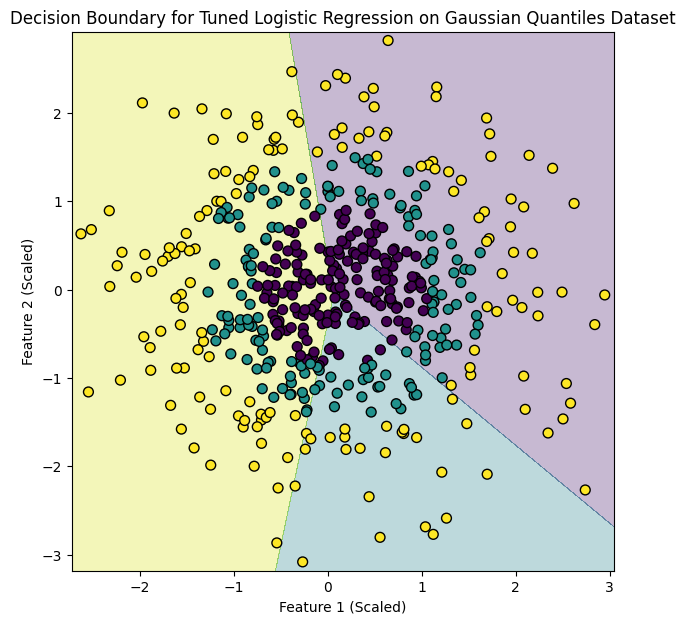

In [61]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_log_reg_gaussian, X_gaussian_scaled, y_gaussian_combined,
                       'Decision Boundary for Tuned Logistic Regression on Gaussian Quantiles Dataset')

The model's best attempt was seperating the data from it's centers into three sctions and since the light blue section was smallest (the labels of class 1 which are represneted as pink dots) the models has misspredicted almost all instances of class 1!

### 3.2.3. SVM (Without Kernel!)

#### 3.2.3.1. Training

Just like the Perceptron and Logistic Regression, the linear nature of SVM means it will try to separate these classes with lines, thus we should expect it to perform poorly

In [62]:
print("--- Training Linear SVM on Gaussian Quantiles Dataset ---")

print("\n1. Training a baseline Linear SVM model...")
svm_gaussian_base = SVC(kernel='linear', random_state=random_state)
svm_gaussian_base.fit(X_train_gaussian_scaled, y_train_gaussian)

y_pred_base_svm_gaussian = svm_gaussian_base.predict(X_test_gaussian_scaled)
base_accuracy_svm_gaussian = accuracy_score(y_test_gaussian, y_pred_base_svm_gaussian)
print(f"Baseline Linear SVM Accuracy: {base_accuracy_svm_gaussian:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_gaussian, y_pred_base_svm_gaussian, zero_division=0))

--- Training Linear SVM on Gaussian Quantiles Dataset ---

1. Training a baseline Linear SVM model...
Baseline Linear SVM Accuracy: 0.3933
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.70      0.51        50
           1       0.38      0.24      0.29        50
           2       0.40      0.24      0.30        50

    accuracy                           0.39       150
   macro avg       0.39      0.39      0.37       150
weighted avg       0.39      0.39      0.37       150



The baseline SVM model got an accuracy of 39%, which is in the same ballpark of the preceptron's accuracy (33%) and logistic regression (31%), this is due to the nonlinear nature of the dataset showen in the previous sections.

Upnext we will try to improve its performance by tuning the hyperparameters.

#### 3.2.3.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardell of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best parameters found: {'C': 0.1}

3. Evaluating the tuned Linear SVM model...
Tuned Linear SVM Accuracy: 0.3867
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.68      0.49        50
           1       0.38      0.24      0.29        50
           2       0.41      0.24      0.30        50

    accuracy                           0.39       150
   macro avg       0.39      0.39      0.36       150
weighted avg       0.39      0.39      0.36       150

Tuned Model Confusion Matrix:


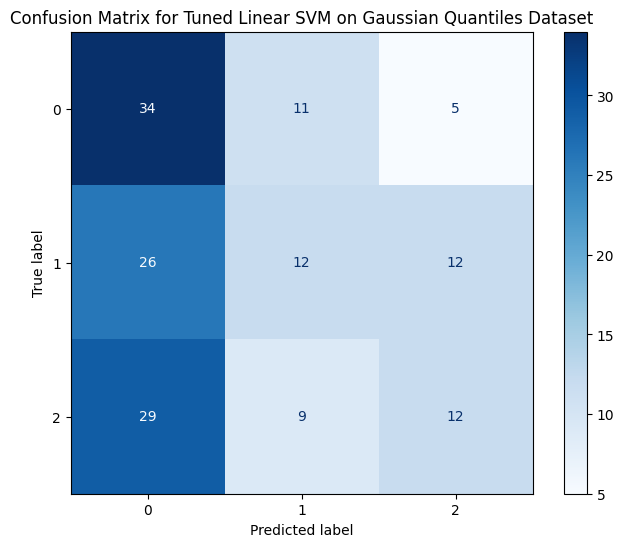

In [63]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_svm = {
    'C': [0.1, 1, 10, 100, 1000]
}

grid_search_svm_gaussian = GridSearchCV(SVC(kernel='linear', random_state=random_state),
                                        param_grid_svm, cv=5, n_jobs=-1, verbose=1)

grid_search_svm_gaussian.fit(X_train_gaussian_scaled, y_train_gaussian)

print("\nBest parameters found:", grid_search_svm_gaussian.best_params_)
best_svm_gaussian = grid_search_svm_gaussian.best_estimator_


print("\n3. Evaluating the tuned Linear SVM model...")
y_pred_tuned_svm_gaussian = best_svm_gaussian.predict(X_test_gaussian_scaled)
tuned_accuracy_svm_gaussian = accuracy_score(y_test_gaussian, y_pred_tuned_svm_gaussian)

print(f"Tuned Linear SVM Accuracy: {tuned_accuracy_svm_gaussian:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_gaussian, y_pred_tuned_svm_gaussian, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_svm_gaussian, X_test_gaussian_scaled, y_test_gaussian, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Linear SVM on Gaussian Quantiles Dataset')
plt.show()

As we can see, even after trying different parameters the model didn't achieve any better results.

From the confusion matrix we can see that the model dosn't quite either predicts each data as class 0 or calss 2 (which was the case with Logistic Regression) but it still has a tendency of chosing 0 as the lable, something that is showen better in the next section.

#### 3.2.3.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundraies of the predictions.

Since the SVM model was heavier than previous models, I had to reduce the resolution of the plot and thus copy and pasted the code for drawing the plot :)


4. Visualizing the Decision Boundary...


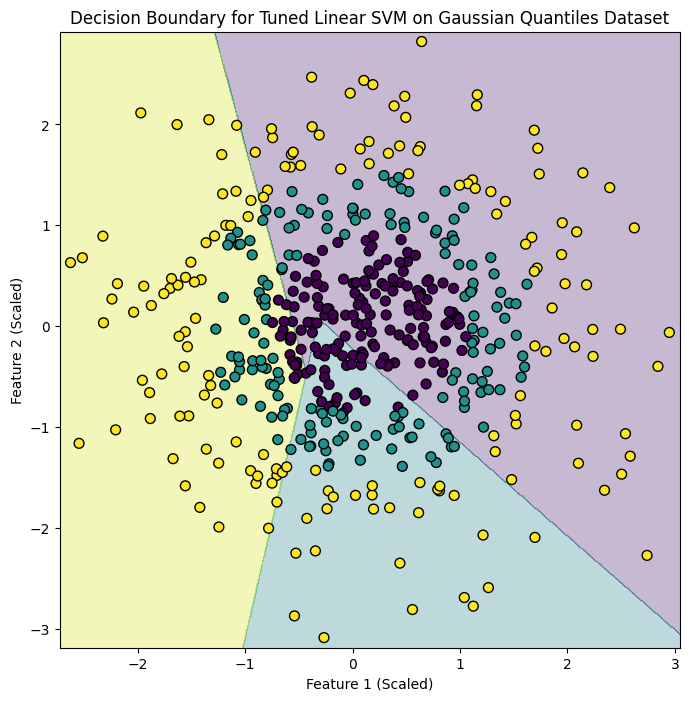

In [64]:
print("\n4. Visualizing the Decision Boundary...")

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolor='k', cmap='viridis')
    plt.title(title)
    plt.xlabel('Feature 1 (Scaled)')
    plt.ylabel('Feature 2 (Scaled)')
    plt.show()

plot_decision_boundary(best_svm_gaussian, X_gaussian_scaled, y_gaussian_combined,
                       'Decision Boundary for Tuned Linear SVM on Gaussian Quantiles Dataset')

The model's best attempt was separating the data from it's centers into three sections which is clearly not a good way of separating the classes!

### 3.2.4. SVM (With Kernel!)

#### 3.2.4.1. Training

All the pervious models have achieved a very poor result on this dataset due to its non linear nature, so when trying kernel SVM we expect to get a noticeable improvement!

In [65]:
print("--- Training Kernel SVM on Gaussian Quantiles Dataset ---")

print("\n1. Training a baseline Kernel SVM model (RBF kernel)...")
ksvm_gaussian_base = SVC(random_state=random_state)
ksvm_gaussian_base.fit(X_train_gaussian_scaled, y_train_gaussian)

y_pred_base_ksvm_gaussian = ksvm_gaussian_base.predict(X_test_gaussian_scaled)
base_accuracy_ksvm_gaussian = accuracy_score(y_test_gaussian, y_pred_base_ksvm_gaussian)
print(f"Baseline Kernel SVM Accuracy: {base_accuracy_ksvm_gaussian:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_gaussian, y_pred_base_ksvm_gaussian, zero_division=0))


--- Training Kernel SVM on Gaussian Quantiles Dataset ---

1. Training a baseline Kernel SVM model (RBF kernel)...
Baseline Kernel SVM Accuracy: 0.9600
Baseline Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.98      0.90      0.94        50
           2       0.91      0.98      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



The baseline kernel SVM model got an accuracy of 96%, which is significantly better than preceptron's accuracy (33%) and logistic regression (31%) and normal SVM (39%), this is due to the nonlinear nature of the dataset shown in the previous sections and the fact that with a kernel we are able to compensate for this by taking the features into a higher dimension where the classes are separable.

Upnext we will try to improve its performance by tuning the hyperparameters.

#### 3.2.4.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Expanded Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 77 candidates, totalling 385 fits

Best parameters found: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

3. Evaluating the tuned Kernel SVM model...
Tuned Kernel SVM Accuracy: 0.9800
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.98      0.96      0.97        50
           2       0.96      0.98      0.97        50

    accuracy                           0.98       150
   macro avg       0.98      0.98      0.98       150
weighted avg       0.98      0.98      0.98       150

Tuned Model Confusion Matrix:


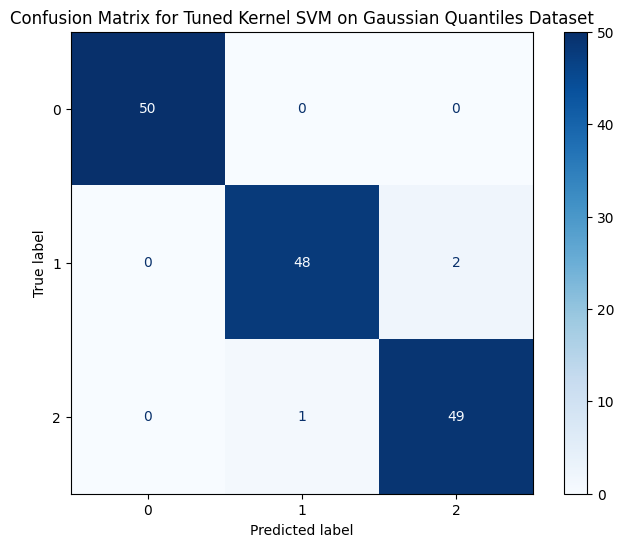

In [66]:
print("\n2. Performing Expanded Hyperparameter Tuning with GridSearchCV...")

param_grid_ksvm_expanded = [
    {'C': [0.001, 0.1, 1, 10, 100, 150, 1000], 'gamma': ['scale', 10, 1, 0.1, 0.01], 'kernel': ['rbf']},
    {'C': [0.001, 0.1, 1, 10, 100, 150, 1000], 'degree': [2, 3, 4, 5], 'kernel': ['poly']},
    {'C': [0.001, 0.1, 1, 10, 100, 150, 1000], 'gamma': ['scale', 'auto'], 'kernel': ['sigmoid']}
]

grid_search_ksvm_gaussian = GridSearchCV(SVC(random_state=random_state),
                                         param_grid_ksvm_expanded, cv=5, n_jobs=-1, verbose=1)

grid_search_ksvm_gaussian.fit(X_train_gaussian_scaled, y_train_gaussian)

print("\nBest parameters found:", grid_search_ksvm_gaussian.best_params_)
best_ksvm_gaussian = grid_search_ksvm_gaussian.best_estimator_

print("\n3. Evaluating the tuned Kernel SVM model...")
y_pred_tuned_ksvm_gaussian = best_ksvm_gaussian.predict(X_test_gaussian_scaled)
tuned_accuracy_ksvm_gaussian = accuracy_score(y_test_gaussian, y_pred_tuned_ksvm_gaussian)

print(f"Tuned Kernel SVM Accuracy: {tuned_accuracy_ksvm_gaussian:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_gaussian, y_pred_tuned_ksvm_gaussian, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_ksvm_gaussian, X_test_gaussian_scaled, y_test_gaussian, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Kernel SVM on Gaussian Quantiles Dataset')
plt.show()

As we can see, fine tuning the parameters improved the model's accuracy to 98% where the model only makes 3 mistakes! 

This as well as the model's ability to distinguish the boundaries properly (and it's ability to generalize) is shown in the decision boundaries of the next section.

#### 3.2.4.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundraies of the predictions.



4. Visualizing the Decision Boundary...


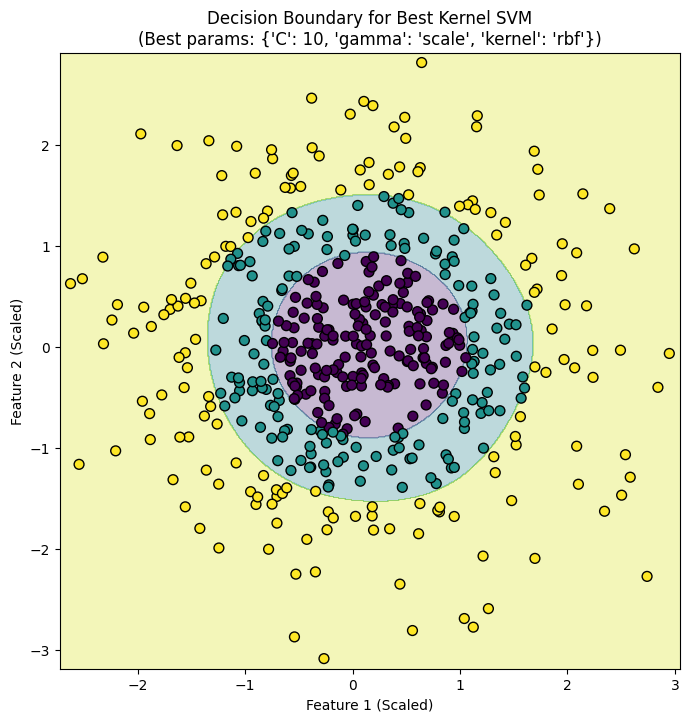

In [67]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_ksvm_gaussian, X_gaussian_scaled, y_gaussian_combined,
                       f'Decision Boundary for Best Kernel SVM\n(Best params: {grid_search_ksvm_gaussian.best_params_})')

Here we can clearly see how well the model was able to find the boundaries between classes and how it achieved its 98% accuracy!

### 3.2.5. Decision Tree

#### 3.2.5.1. Training

Here we will train a single decision tree and later tune its parameters, decision trees are quite prone to overfitting so in order to remedy this we need to carefully set the hyperparameters (or use random forests which is the next algorithm we will look at!)

This dataset is non linear and a non linear model like decision tree should perform better than linear models like logistic regression, however since the tree will try to model the circular patterns using only straight lines, it would most likely perform worse tha VM with kernel. 

In [68]:
print("--- Training Decision Tree on Gaussian Quantiles Dataset ---")

print("\n1. Training a baseline Decision Tree model...")
dt_gaussian_base = DecisionTreeClassifier(random_state=random_state)
dt_gaussian_base.fit(X_train_gaussian_scaled, y_train_gaussian)

y_pred_base_dt_gaussian = dt_gaussian_base.predict(X_test_gaussian_scaled)
base_accuracy_dt_gaussian = accuracy_score(y_test_gaussian, y_pred_base_dt_gaussian)
print(f"Baseline Decision Tree Accuracy: {base_accuracy_dt_gaussian:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_gaussian, y_pred_base_dt_gaussian, zero_division=0))

--- Training Decision Tree on Gaussian Quantiles Dataset ---

1. Training a baseline Decision Tree model...
Baseline Decision Tree Accuracy: 0.9133
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        50
           1       0.88      0.86      0.87        50
           2       0.94      0.92      0.93        50

    accuracy                           0.91       150
   macro avg       0.91      0.91      0.91       150
weighted avg       0.91      0.91      0.91       150



As expected the baseline model got quite a good result but slightly worse than SVM with kernel (96%), we will try to tune the parameters and see if we can get an even better result or not

#### 3.2.5.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 192 candidates, totalling 960 fits

Best parameters found: {'criterion': 'entropy', 'max_depth': 1000, 'min_samples_leaf': 1, 'min_samples_split': 2}

3. Evaluating the tuned Decision Tree model...
Tuned Decision Tree Accuracy: 0.9000
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        50
           1       0.91      0.78      0.84        50
           2       0.86      0.98      0.92        50

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150

Tuned Model Confusion Matrix:


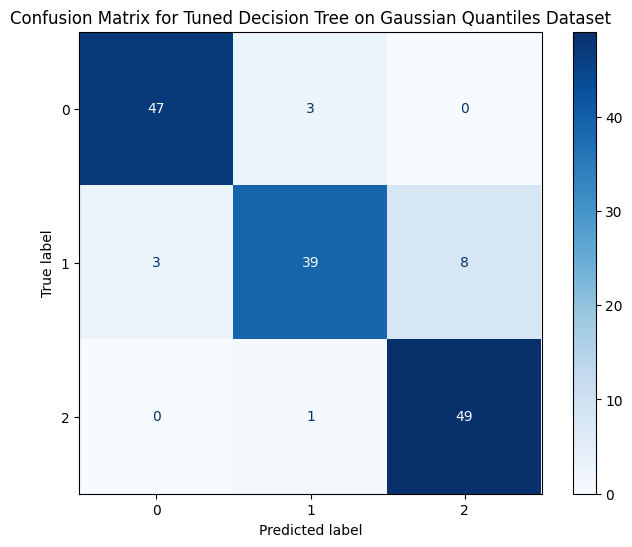

In [69]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, 1000, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8]
}

grid_search_dt_gaussian = GridSearchCV(DecisionTreeClassifier(random_state=random_state),
                                       param_grid_dt, cv=5, n_jobs=-1, verbose=1)

grid_search_dt_gaussian.fit(X_train_gaussian_scaled, y_train_gaussian)

print("\nBest parameters found:", grid_search_dt_gaussian.best_params_)
best_dt_gaussian = grid_search_dt_gaussian.best_estimator_

print("\n3. Evaluating the tuned Decision Tree model...")
y_pred_tuned_dt_gaussian = best_dt_gaussian.predict(X_test_gaussian_scaled)
tuned_accuracy_dt_gaussian = accuracy_score(y_test_gaussian, y_pred_tuned_dt_gaussian)

print(f"Tuned Decision Tree Accuracy: {tuned_accuracy_dt_gaussian:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_gaussian, y_pred_tuned_dt_gaussian, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_dt_gaussian, X_test_gaussian_scaled, y_test_gaussian, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Decision Tree on Gaussian Quantiles Dataset')
plt.show()

Fine tuning didn't really improve the model indicating that maybe we have reached its maximum potential.

#### 3.2.5.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundaries of the predictions.


4. Visualizing the Decision Boundary...


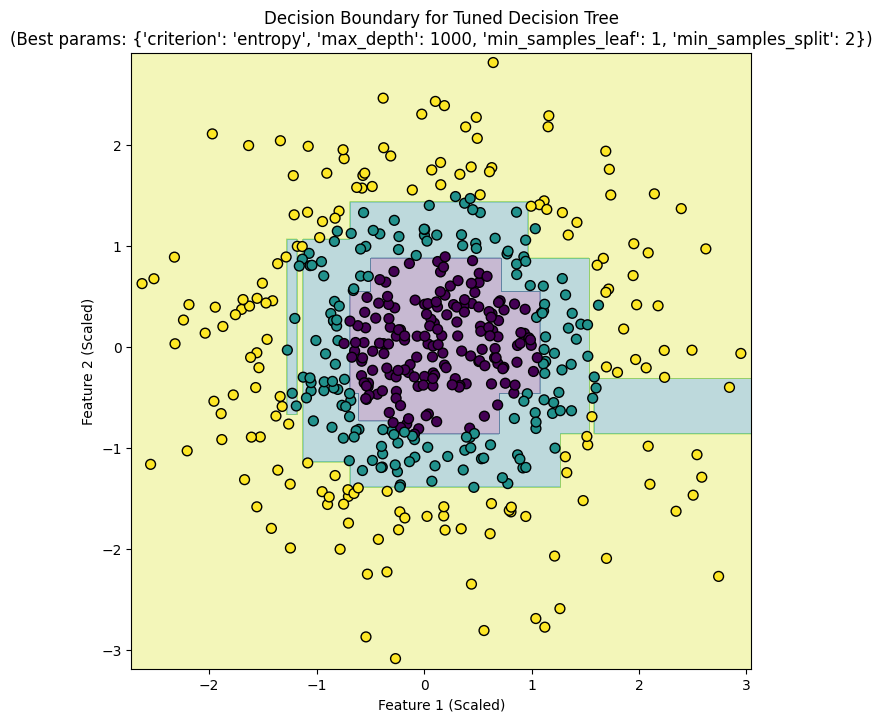

In [70]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_dt_gaussian, X_gaussian_scaled, y_gaussian_combined,
                       f'Decision Boundary for Tuned Decision Tree\n(Best params: {grid_search_dt_gaussian.best_params_})')

From the decision boundaries we can see that the model has attempted to box in the circles using horizontal and vertical lines, which given the circular nature of the data didn't result in a very good generalization (but still with 90+ accuracy it outperformed all pervious linear models).

### 3.2.6. Random Forest

#### 3.2.6.1. Training

Here we will train a random forest and later tune its parameters, random forest consist of multiple decision trees that have each been train of a portion of the data and then the final decision is made majority voting, the reason we use multiple decision trees is to prevent them from over fitting, another advantage of the random forest is the fact that it usually doesn't need much tuning.

This dataset is non linear and a non linear model like random forest should perform better than linear models like logistic regression, and since the random forest consists of multiple trees it might be able to create circular patterns (something that a single decision tree was incapable of ). 

In [71]:
print("--- Training Random Forest on Gaussian Quantiles Dataset ---")

print("\n1. Training a baseline Random Forest model...")
rf_gaussian_base = RandomForestClassifier(random_state=random_state, n_jobs=-1)
rf_gaussian_base.fit(X_train_gaussian_scaled, y_train_gaussian)

y_pred_base_rf_gaussian = rf_gaussian_base.predict(X_test_gaussian_scaled)
base_accuracy_rf_gaussian = accuracy_score(y_test_gaussian, y_pred_base_rf_gaussian)
print(f"Baseline Random Forest Accuracy: {base_accuracy_rf_gaussian:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_gaussian, y_pred_base_rf_gaussian, zero_division=0))

--- Training Random Forest on Gaussian Quantiles Dataset ---

1. Training a baseline Random Forest model...
Baseline Random Forest Accuracy: 0.9467
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        50
           1       0.96      0.88      0.92        50
           2       0.93      1.00      0.96        50

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



As expected the baseline model got quite a good result and on par with the base SVM with kernel (96%), we will try to tune the parameters and see if we can get an even better result or not

#### 3.2.6.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters found: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

3. Evaluating the tuned Random Forest model...
Tuned Random Forest Accuracy: 0.9467
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        50
           1       0.94      0.90      0.92        50
           2       0.94      0.98      0.96        50

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150

Tuned Model Confusion Matrix:


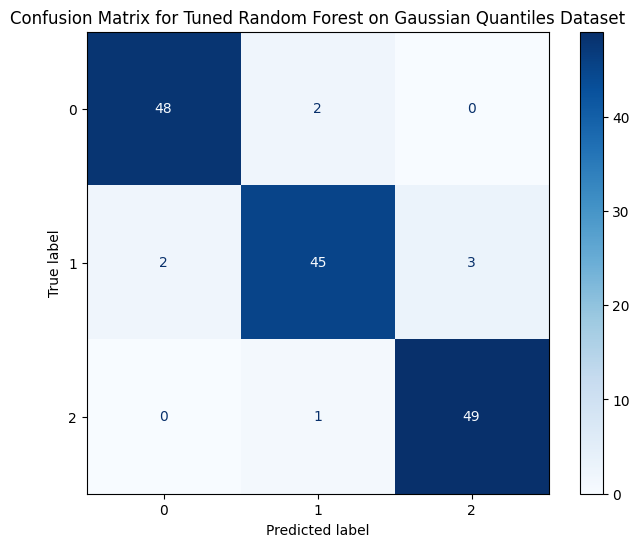

In [72]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_rf = {
    'n_estimators': [50, 100, 200, 300, 1000],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 7],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf_gaussian = GridSearchCV(RandomForestClassifier(random_state=random_state, n_jobs=-1),
                                       param_grid_rf, cv=5, n_jobs=-1, verbose=1)

grid_search_rf_gaussian.fit(X_train_gaussian_scaled, y_train_gaussian)

print("\nBest parameters found:", grid_search_rf_gaussian.best_params_)
best_rf_gaussian = grid_search_rf_gaussian.best_estimator_


print("\n3. Evaluating the tuned Random Forest model...")
y_pred_tuned_rf_gaussian = best_rf_gaussian.predict(X_test_gaussian_scaled)
tuned_accuracy_rf_gaussian = accuracy_score(y_test_gaussian, y_pred_tuned_rf_gaussian)

print(f"Tuned Random Forest Accuracy: {tuned_accuracy_rf_gaussian:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_gaussian, y_pred_tuned_rf_gaussian, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_rf_gaussian, X_test_gaussian_scaled, y_test_gaussian, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Random Forest on Gaussian Quantiles Dataset')
plt.show()

Tuning the hyperparameters didn't result in much of an improvement and it fell short of the tuned kernel SVM that got a near perfect 98% score.

From the confusion matrix we can see the model has stuggled most with instances of class 1 and mislabeled them as class 2, this is more evident in the decision boundaries below.

#### 3.2.6.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundaries of the predictions.


4. Visualizing the Decision Boundary...


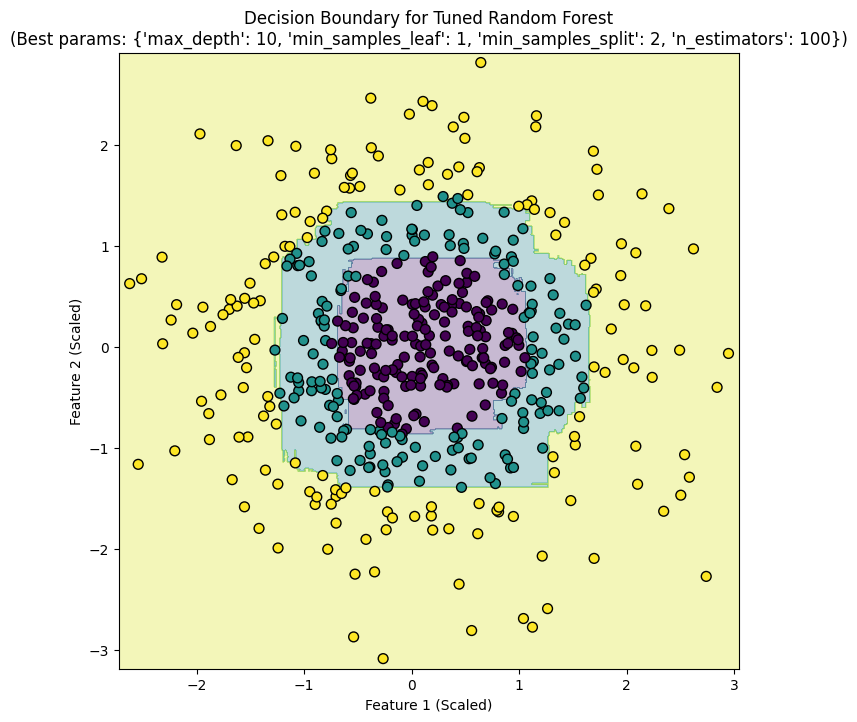

In [73]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_rf_gaussian, X_gaussian_scaled, y_gaussian_combined,
                       f'Decision Boundary for Tuned Random Forest\n(Best params: {grid_search_rf_gaussian.best_params_})')

From the boundaries we can see that the model has improved considerably compared to a single decision tree and the boundaries now resemble circles more, but it still fell short of kernel SVM's ability to draw smooth circles and divide the sections nearly perfect.

### 3.2.7. KNN

#### 3.2.7.1. Training

KNN is fundamentally different from all the previous models. It's a non-parametric algorithm, meaning it doesn't try to learn a model or a function from the training data. Instead, it memorizes the entire training dataset.

This dataset is non linear previous linear models like like logistic regression and perceptron has performed poorly on it, but the non linear models like kernel SVM and random forest managed to get 90+% accuracy, and since the random forest consists of multiple trees it might be able to create circular patterns (something that a single decision tree was incapable of ). 

In [142]:
print("--- Training K-Nearest Neighbors (KNN) on Gaussian Quantiles Dataset ---")

print("\n1. Training a baseline KNN model (K=5)...")
knn_gaussian_base = KNeighborsClassifier(n_neighbors=5)
knn_gaussian_base.fit(X_train_gaussian_scaled, y_train_gaussian)

y_pred_base_knn_gaussian = knn_gaussian_base.predict(X_test_gaussian_scaled)
base_accuracy_knn_gaussian = accuracy_score(y_test_gaussian, y_pred_base_knn_gaussian)
print(f"Baseline KNN Accuracy: {base_accuracy_knn_gaussian:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_gaussian, y_pred_base_knn_gaussian, zero_division=0))

--- Training K-Nearest Neighbors (KNN) on Gaussian Quantiles Dataset ---

1. Training a baseline KNN model (K=5)...
Baseline KNN Accuracy: 0.9000
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90        50
           1       0.86      0.84      0.85        50
           2       0.96      0.94      0.95        50

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150



Using KNN without any tuning we managed to get a 90% accuracy on the dataset which is only 5% short of the results of the kernel SVM and random forest. We will try to improve this performance even further by tuning the hyperparameters next.

#### 3.2.7.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters found: {'metric': 'euclidean', 'n_neighbors': 4, 'weights': 'distance'}

3. Evaluating the tuned KNN model...
Tuned KNN Accuracy: 0.9400
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        50
           1       0.90      0.92      0.91        50
           2       1.00      0.94      0.97        50

    accuracy                           0.94       150
   macro avg       0.94      0.94      0.94       150
weighted avg       0.94      0.94      0.94       150

Tuned Model Confusion Matrix:


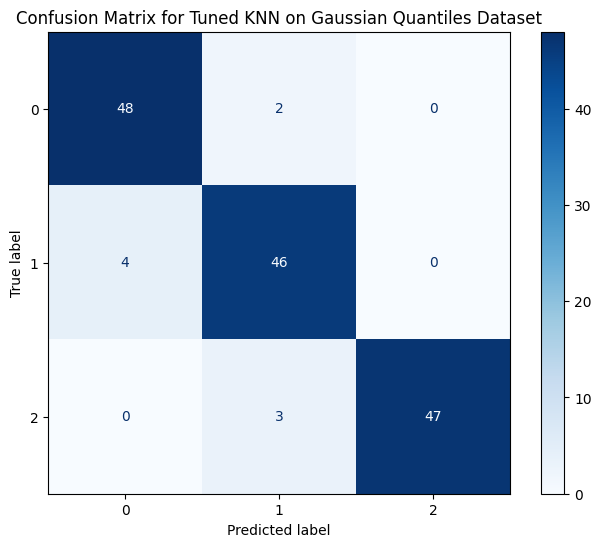

In [143]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_knn = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search_knn_gaussian = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, n_jobs=-1, verbose=1)

grid_search_knn_gaussian.fit(X_train_gaussian_scaled, y_train_gaussian)

print("\nBest parameters found:", grid_search_knn_gaussian.best_params_)
best_knn_gaussian = grid_search_knn_gaussian.best_estimator_


print("\n3. Evaluating the tuned KNN model...")
y_pred_tuned_knn_gaussian = best_knn_gaussian.predict(X_test_gaussian_scaled)
tuned_accuracy_knn_gaussian = accuracy_score(y_test_gaussian, y_pred_tuned_knn_gaussian)

print(f"Tuned KNN Accuracy: {tuned_accuracy_knn_gaussian:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_gaussian, y_pred_tuned_knn_gaussian, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_knn_gaussian, X_test_gaussian_scaled, y_test_gaussian, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned KNN on Gaussian Quantiles Dataset')
plt.show()

After tuning the parameters and only using the 4 nearest neighbours for deciding, we improved the accuracy to 94% making it on par with the random forest and only 4% shy of the tuned SVM.

From the high f1-score and the confusion matrix we can see that the miscalssifications of the model were distributed equally between the classes.

#### 3.2.7.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundaries of the predictions.


4. Visualizing the Decision Boundary...


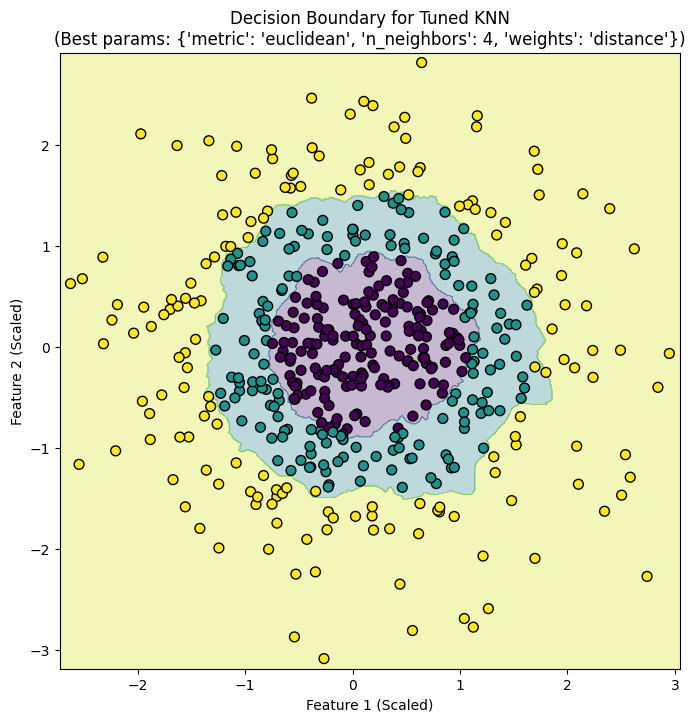

In [144]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_knn_gaussian, X_gaussian_scaled, y_gaussian_combined,
                       f'Decision Boundary for Tuned KNN\n(Best params: {grid_search_knn_gaussian.best_params_})')

From the boundaries we can see that despite the boundaries not being as clean as kernel SVM, they are much better than the boxed shape boundaries of the random forest and should be much better at generalizing to a noisier data.

# 4. Circles (Nonlinear, Concentric Patterns)

## 4.1. Data Preprocessing

### 4.1.1. Creating the Dataset and Visualising

In [74]:
from sklearn.datasets import make_circles
X_circles, y_circles = make_circles(n_samples=400, noise=0.1, factor=0.5, random_state=7)

In [75]:
X_circles.shape

(400, 2)

In [76]:
y_circles.shape

(400,)

This dataset is also 400 points in a 2D plane so it can be easily visualised the same way as the preivious ones.

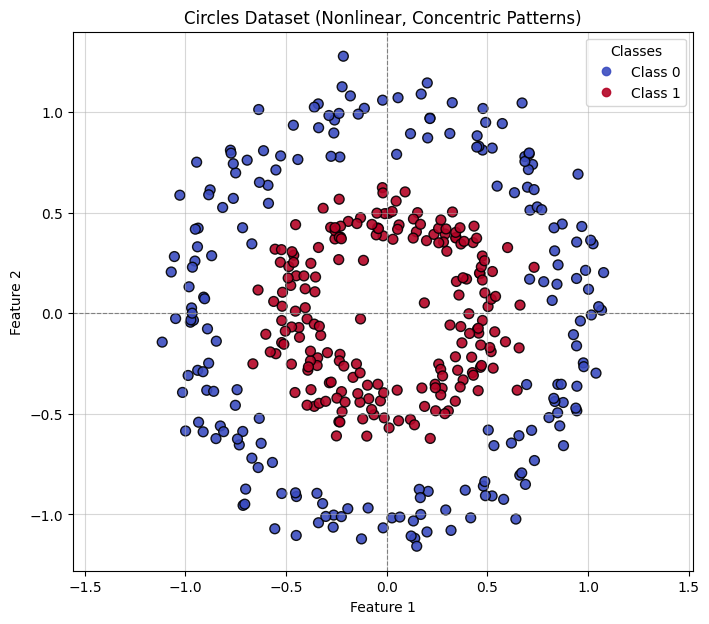

In [77]:
plt.figure(figsize=(8, 7))
scatter = plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='coolwarm', edgecolor='k', s=50, alpha=0.9)

plt.title('Circles Dataset (Nonlinear, Concentric Patterns)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.5)
plt.axhline(0, color='grey', lw=0.8, linestyle='--')
plt.axvline(0, color='grey', lw=0.8, linestyle='--')
plt.axis('equal')

handles, _ = scatter.legend_elements()
class_labels = [f'Class {i}' for i in np.unique(y_circles)]
plt.legend(handles, class_labels, title="Classes")

plt.show()

As the name of the dataset suggests, it consists of two circles, which would prove to be challenging for simple linear models like preceptron, logistic regression, etc.

Let's take a look at the feature distribution next:

--- Overall Feature Distributions (Circles Dataset) ---


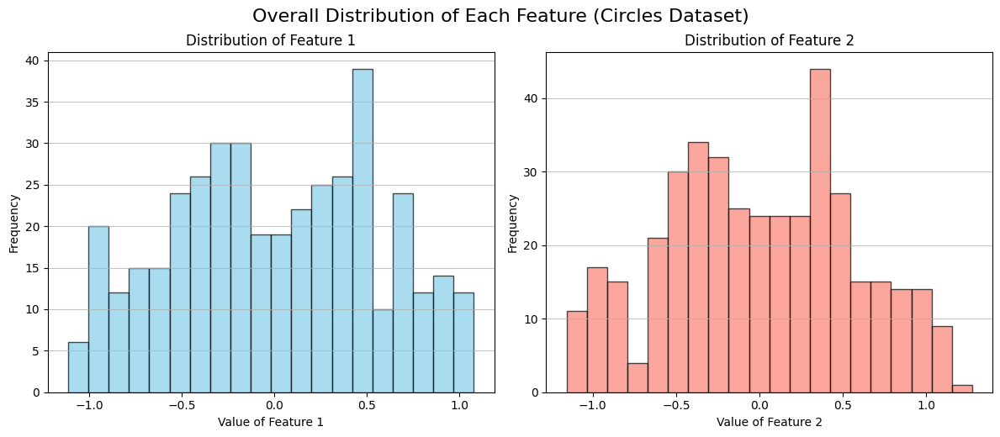


--- Feature Distributions by Class (Circles Dataset) ---


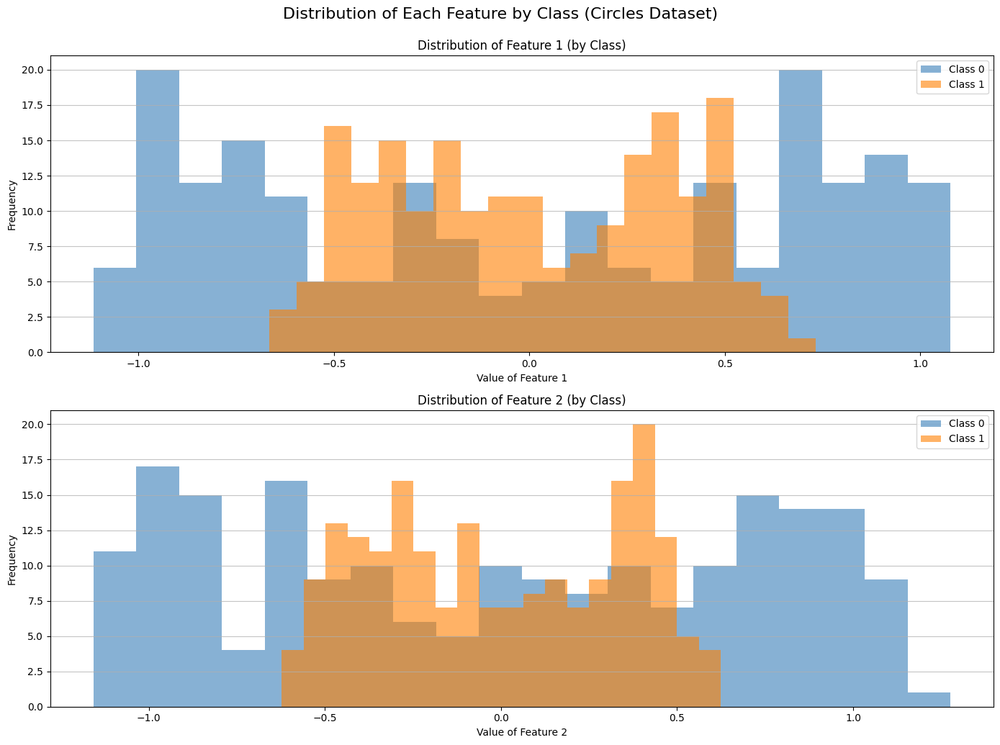

In [78]:
import matplotlib.pyplot as plt
import numpy as np

# --- Plotting Histograms for Each Feature (Overall Distribution) ---
print("--- Overall Feature Distributions (Circles Dataset) ---")
plt.figure(figsize=(12, 5))

# Feature 1
plt.subplot(1, 2, 1)
plt.hist(X_circles[:, 0], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Feature 1')
plt.xlabel('Value of Feature 1')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Feature 2
plt.subplot(1, 2, 2)
plt.hist(X_circles[:, 1], bins=20, color='salmon', edgecolor='black', alpha=0.7)
plt.title('Distribution of Feature 2')
plt.xlabel('Value of Feature 2')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.suptitle('Overall Distribution of Each Feature (Circles Dataset)', fontsize=16, y=1.03)
plt.show()


# --- Plotting Histograms for Each Feature, Separated by Class ---
print("\n--- Feature Distributions by Class (Circles Dataset) ---")
unique_classes_circles = np.unique(y_circles)
colors_circles = ['#377eb8', '#ff7f00']

plt.figure(figsize=(14, 10))

# Feature 1 with class separation
plt.subplot(2, 1, 1)
for cls_idx, cls in enumerate(unique_classes_circles):
    plt.hist(X_circles[y_circles == cls, 0], bins=20, alpha=0.6, label=f'Class {cls}', color=colors_circles[cls_idx])
plt.title('Distribution of Feature 1 (by Class)')
plt.xlabel('Value of Feature 1')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)

# Feature 2 with class separation
plt.subplot(2, 1, 2)
for cls_idx, cls in enumerate(unique_classes_circles):
    plt.hist(X_circles[y_circles == cls, 1], bins=20, alpha=0.6, label=f'Class {cls}', color=colors_circles[cls_idx])
plt.title('Distribution of Feature 2 (by Class)')
plt.xlabel('Value of Feature 2')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.suptitle('Distribution of Each Feature by Class (Circles Dataset)', fontsize=16, y=1.03)
plt.show()

Unlike some of the previous datasets, the features of this dataset don't follow a normal distribution. So we will be using a min-max scaler to scale them in the next section.

### 4.1.2. Splitting & Scaling

Here we will split the data and scale it using a min-max scaler.

In [79]:
X_train_circles, X_test_circles, y_train_circles, y_test_circles = train_test_split(
    X_circles, y_circles, test_size=0.3, random_state=random_state, stratify=y_circles
)
scaler_circles = MinMaxScaler()

scaler_circles.fit(X_train_circles)

X_train_circles_scaled = scaler_circles.transform(X_train_circles)
X_test_circles_scaled = scaler_circles.transform(X_test_circles)

To check that everything has worked properly, we will visualise the data again:

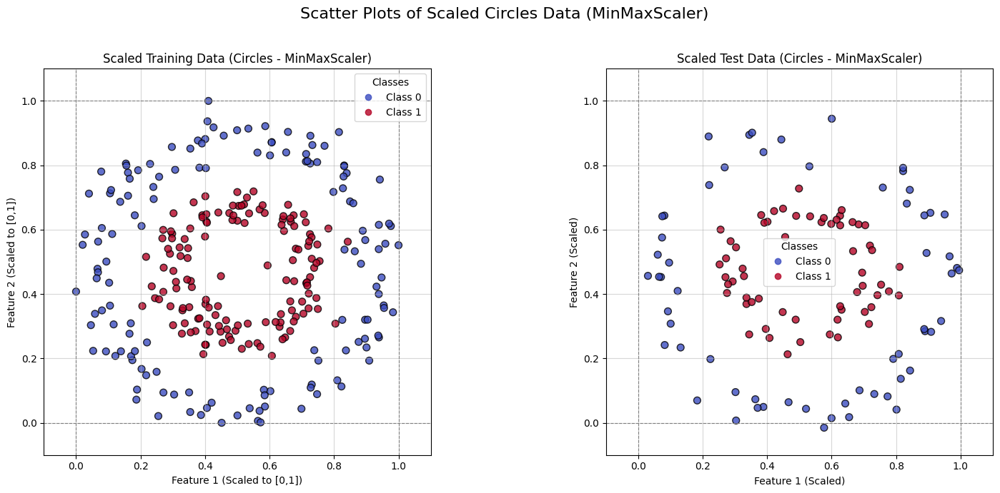

In [80]:
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
scatter_train = plt.scatter(X_train_circles_scaled[:, 0], X_train_circles_scaled[:, 1],
                            c=y_train_circles, cmap='coolwarm', edgecolor='k', s=50, alpha=0.8)
plt.title('Scaled Training Data (Circles - MinMaxScaler)')
plt.xlabel('Feature 1 (Scaled to [0,1])')
plt.ylabel('Feature 2 (Scaled to [0,1])')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.5)
plt.axhline(0, color='grey', lw=0.8, linestyle='--')
plt.axvline(0, color='grey', lw=0.8, linestyle='--')
plt.axhline(1, color='grey', lw=0.8, linestyle='--')
plt.axvline(1, color='grey', lw=0.8, linestyle='--')
plt.gca().set_aspect('equal', adjustable='box')

handles_train, _ = scatter_train.legend_elements()
class_labels_train = [f'Class {i}' for i in np.unique(y_train_circles)]
plt.legend(handles_train, class_labels_train, title="Classes")

plt.subplot(1, 2, 2)
scatter_test = plt.scatter(X_test_circles_scaled[:, 0], X_test_circles_scaled[:, 1],
                           c=y_test_circles, cmap='coolwarm', edgecolor='k', s=50, alpha=0.8)
plt.title('Scaled Test Data (Circles - MinMaxScaler)')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.5)
plt.axhline(0, color='grey', lw=0.8, linestyle='--')
plt.axvline(0, color='grey', lw=0.8, linestyle='--')
plt.axhline(1, color='grey', lw=0.8, linestyle='--')
plt.axvline(1, color='grey', lw=0.8, linestyle='--')
plt.gca().set_aspect('equal', adjustable='box')

handles_test, _ = scatter_test.legend_elements()
class_labels_test = [f'Class {i}' for i in np.unique(y_test_circles)]
plt.legend(handles_test, class_labels_test, title="Classes")


plt.suptitle('Scatter Plots of Scaled Circles Data (MinMaxScaler)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 4.2. Model Training and Hyperparamter Tuning

### 4.2.1. Preceptron

#### 4.2.1.1. Training

Here we will train a simple preceptron and tune its parameters, since the data isn't linearly seperable we don't have high excpections about the model's performance as preceptrons are linear model and work best with linearly seperable data.

In [81]:
print("--- Training Perceptron on Circles Dataset ---")

print("\n1. Training a baseline Perceptron model...")
perceptron_circles_base = Perceptron(random_state=random_state)
perceptron_circles_base.fit(X_train_circles_scaled, y_train_circles)

y_pred_circles_base = perceptron_circles_base.predict(X_test_circles_scaled)
base_accuracy_circles = accuracy_score(y_test_circles, y_pred_circles_base)
print(f"Baseline Perceptron Accuracy: {base_accuracy_circles:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_circles, y_pred_circles_base, zero_division=0))

--- Training Perceptron on Circles Dataset ---

1. Training a baseline Perceptron model...
Baseline Perceptron Accuracy: 0.5000
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.50      1.00      0.67        60

    accuracy                           0.50       120
   macro avg       0.25      0.50      0.33       120
weighted avg       0.25      0.50      0.33       120



As excpected the preceptron achieved an average accuracy of 50% on data, due to the fact that the data cannot be seperated with a line!

#### 4.2.1.2. Hyperparameter Tuning

To see if we can improve the preformance further we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardell of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters found: {'alpha': 0.0001, 'eta0': 0.1, 'max_iter': 1000, 'penalty': 'elasticnet'}

3. Evaluating the tuned Perceptron model...
Tuned Perceptron Accuracy: 0.5000
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.50      1.00      0.67        60

    accuracy                           0.50       120
   macro avg       0.25      0.50      0.33       120
weighted avg       0.25      0.50      0.33       120

Tuned Model Confusion Matrix:


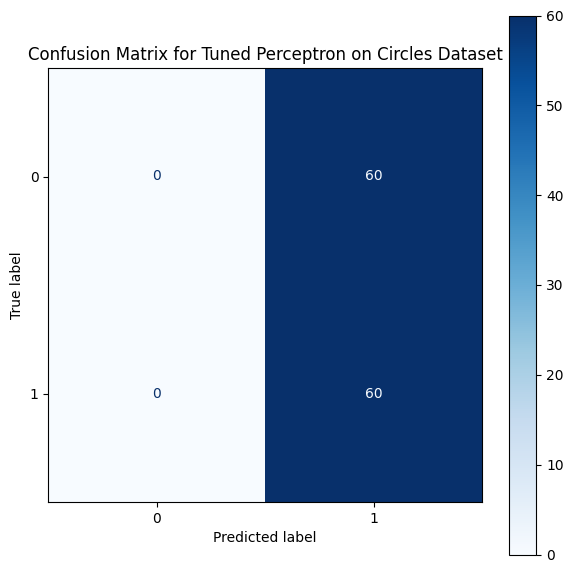

In [82]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_perceptron = {
    'eta0': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'max_iter': [1000, 2000, 3000],
    'penalty': ['l2', 'l1', 'elasticnet', None],
    'alpha': [0.0001, 0.001, 0.01]
}

grid_search_circles = GridSearchCV(Perceptron(random_state=random_state), param_grid_perceptron, cv=5, n_jobs=-1, verbose=1)
grid_search_circles.fit(X_train_circles_scaled, y_train_circles)

print("\nBest parameters found:", grid_search_circles.best_params_)
best_perceptron_circles = grid_search_circles.best_estimator_


print("\n3. Evaluating the tuned Perceptron model...")
y_pred_circles_tuned = best_perceptron_circles.predict(X_test_circles_scaled)
tuned_accuracy_circles = accuracy_score(y_test_circles, y_pred_circles_tuned)

print(f"Tuned Perceptron Accuracy: {tuned_accuracy_circles:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_circles, y_pred_circles_tuned, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay.from_estimator(best_perceptron_circles, X_test_circles_scaled, y_test_circles, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Perceptron on Circles Dataset')
plt.show()

Trying different hyperparameters had little to no effect, this is due to the nonlinear nature of the data, which is shown better in the plot of the next section.

Also from the confusion matrix we can see that the best model was a model that predicted 1 for all the calsses! which basically doesn't give us any information!

#### 3.2.1.3. Visualising the Predictions

Since we had only two features, we will use a code simillar to the one in the book to visualise the decision boundraies of the predictions.


4. Visualizing the Decision Boundary...


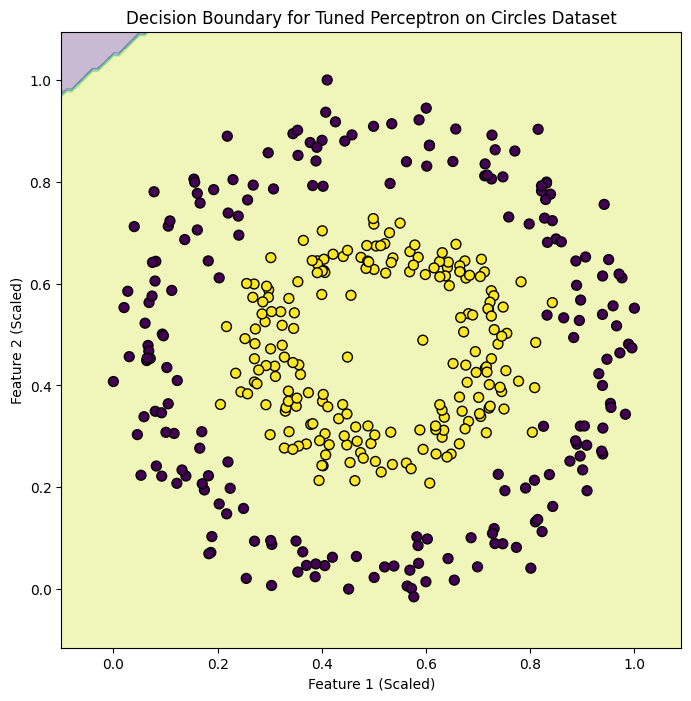

In [83]:
print("\n4. Visualizing the Decision Boundary...")

X_circles_scaled = np.vstack((X_train_circles_scaled, X_test_circles_scaled))
y_circles_combined = np.hstack((y_train_circles, y_test_circles))

plot_decision_boundary(best_perceptron_circles, X_circles_scaled, y_circles_combined,
                       'Decision Boundary for Tuned Perceptron on Circles Dataset')

The fact that the model returns 1 for all the examples is showen in the desicion boundry as well. If we want a better performance on this non linear dataset, we either have to use non linear models or use multiple linear neurons like in a neural network.

### 4.2.2. Logistic Regression

#### 4.2.2.1. Training

This is another nonlinear problem where we expect a linear model like Logistic Regression to fail. It will try to find a straight line to separate the two cocentric circles, which is an impossible task. And at best it might get an accuracy of 50% (much like the preceptron)

In [84]:
print("--- Training Logistic Regression on Circles Dataset ---")

print("\n1. Training a baseline Logistic Regression model...")
log_reg_circles_base = LogisticRegression(random_state=random_state, max_iter=1000)
log_reg_circles_base.fit(X_train_circles_scaled, y_train_circles)

y_pred_circles_base_lr = log_reg_circles_base.predict(X_test_circles_scaled)
base_accuracy_circles_lr = accuracy_score(y_test_circles, y_pred_circles_base_lr)
print(f"Baseline Logistic Regression Accuracy: {base_accuracy_circles_lr:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_circles, y_pred_circles_base_lr, zero_division=0))

--- Training Logistic Regression on Circles Dataset ---

1. Training a baseline Logistic Regression model...
Baseline Logistic Regression Accuracy: 0.4750
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.45      0.46        60
           1       0.48      0.50      0.49        60

    accuracy                           0.47       120
   macro avg       0.47      0.47      0.47       120
weighted avg       0.47      0.47      0.47       120



As excpected we got an accuracy of 47% which mostlile corresponds to a line passing through the center of the circles.

Up next we will try to tune the hyperparameters (but it will most likely not yield any good results)

#### 4.2.2.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardell of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}

3. Evaluating the tuned Logistic Regression model...
Tuned Logistic Regression Accuracy: 0.5000
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67        60
           1       0.00      0.00      0.00        60

    accuracy                           0.50       120
   macro avg       0.25      0.50      0.33       120
weighted avg       0.25      0.50      0.33       120

Tuned Model Confusion Matrix:


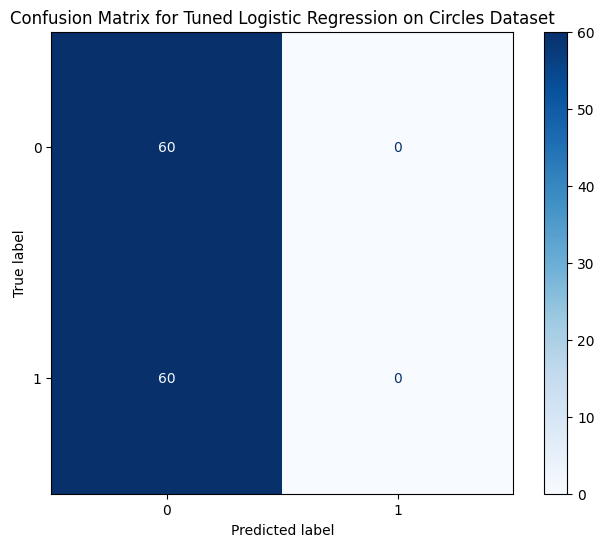

In [85]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_lr = [
    {
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000, 2000]
    },
    {
        'penalty': ['elasticnet'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['saga'],
        'l1_ratio': [0.5],
        'max_iter': [1000, 2000]
    }
]

grid_search_circles_lr = GridSearchCV(LogisticRegression(random_state=random_state),
                                      param_grid_lr, cv=5, n_jobs=-1, verbose=1)
grid_search_circles_lr.fit(X_train_circles_scaled, y_train_circles)

print("\nBest parameters found:", grid_search_circles_lr.best_params_)
best_log_reg_circles = grid_search_circles_lr.best_estimator_


print("\n3. Evaluating the tuned Logistic Regression model...")
y_pred_circles_tuned_lr = best_log_reg_circles.predict(X_test_circles_scaled)
tuned_accuracy_circles_lr = accuracy_score(y_test_circles, y_pred_circles_tuned_lr)

print(f"Tuned Logistic Regression Accuracy: {tuned_accuracy_circles_lr:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_circles, y_pred_circles_tuned_lr, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_log_reg_circles, X_test_circles_scaled, y_test_circles, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Logistic Regression on Circles Dataset')
plt.show()

in order for the model to increase the 47% accuracy to 50%, it resulted in predicting the lable 0 for every point!

This is mostlikely because of the low C value which strenghtens the regularization.

Since this model doesn't give any usefull information in the next section we will be plotting the decision boundries of the base model which had a f1-score of 0.49

#### 4.2.2.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundraies of the predictions.


4. Visualizing the Decision Boundary...


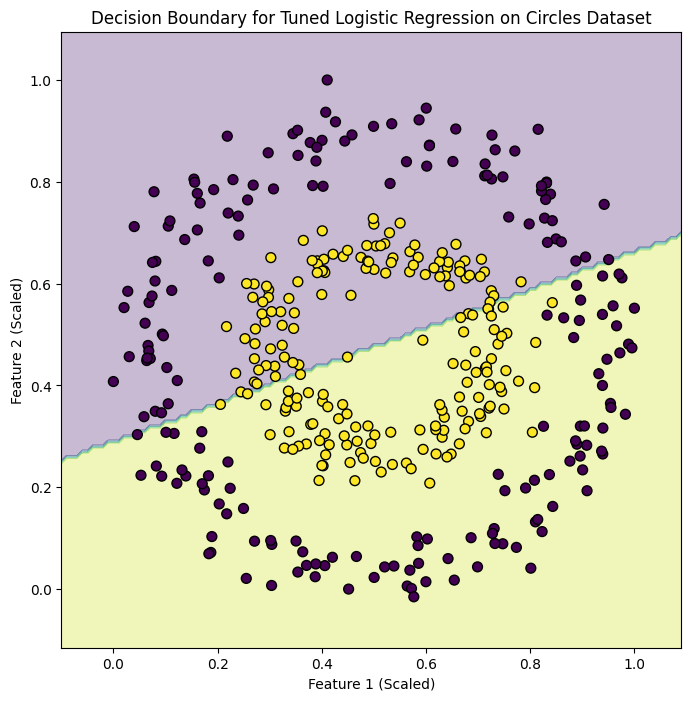

In [86]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(log_reg_circles_base, X_circles_scaled, y_circles_combined,
                       'Decision Boundary for Tuned Logistic Regression on Circles Dataset')

As predicted earlier, the base model achived it's 47% accuracy by passing a line through the center of the circles, which doen's provide any meaningfull seperation and is as good as randomly guessing a class.

### 4.2.3. SVM (Without Kernel!)

#### 4.2.3.1. Training

This is another nonlinear problem where we expect a linear model like SVM to fail. It will try to find a straight line to separate the two cocentric circles, which is an impossible task. And at best it might get an accuracy of 50% (much like the preceptron and logistic regression)

In [87]:
print("--- Training Linear SVM on Circles Dataset ---")

print("\n1. Training a baseline Linear SVM model...")
svm_circles_base = SVC(kernel='linear', random_state=random_state)
svm_circles_base.fit(X_train_circles_scaled, y_train_circles)

y_pred_base_svm_circles = svm_circles_base.predict(X_test_circles_scaled)
base_accuracy_svm_circles = accuracy_score(y_test_circles, y_pred_base_svm_circles)
print(f"Baseline Linear SVM Accuracy: {base_accuracy_svm_circles:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_circles, y_pred_base_svm_circles, zero_division=0))

--- Training Linear SVM on Circles Dataset ---

1. Training a baseline Linear SVM model...
Baseline Linear SVM Accuracy: 0.5167
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.35      0.42        60
           1       0.51      0.68      0.59        60

    accuracy                           0.52       120
   macro avg       0.52      0.52      0.50       120
weighted avg       0.52      0.52      0.50       120



As expected we got an accuracy of 52% which most likely corresponds to a line passing through the center of the circles.

Up next we will try to tune the hyperparameters (but it will most likely not yield any good results)

#### 4.2.3.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best parameters found: {'C': 0.1}

3. Evaluating the tuned Linear SVM model...
Tuned Linear SVM Accuracy: 0.5583
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.33      0.43        60
           1       0.54      0.78      0.64        60

    accuracy                           0.56       120
   macro avg       0.57      0.56      0.53       120
weighted avg       0.57      0.56      0.53       120

Tuned Model Confusion Matrix:


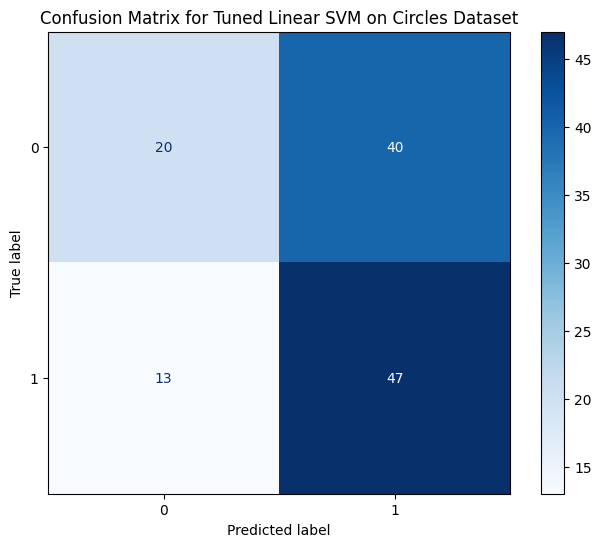

In [88]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_svm = {
    'C': [0.1, 1, 10, 100, 1000]
}

grid_search_svm_circles = GridSearchCV(SVC(kernel='linear', random_state=random_state),
                                       param_grid_svm, cv=5, n_jobs=-1, verbose=1)

grid_search_svm_circles.fit(X_train_circles_scaled, y_train_circles)

print("\nBest parameters found:", grid_search_svm_circles.best_params_)
best_svm_circles = grid_search_svm_circles.best_estimator_


print("\n3. Evaluating the tuned Linear SVM model...")
y_pred_tuned_svm_circles = best_svm_circles.predict(X_test_circles_scaled)
tuned_accuracy_svm_circles = accuracy_score(y_test_circles, y_pred_tuned_svm_circles)

print(f"Tuned Linear SVM Accuracy: {tuned_accuracy_svm_circles:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_circles, y_pred_tuned_svm_circles, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_svm_circles, X_test_circles_scaled, y_test_circles, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Linear SVM on Circles Dataset')
plt.show()

in order for the model to increase the 52% accuracy to 56%, it resorted in predicting the lable 1 for most points!

Next we will check how the decision boundaries are to see how well the model has performed visually.

#### 4.2.3.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundraies of the predictions.


4. Visualizing the Decision Boundary...


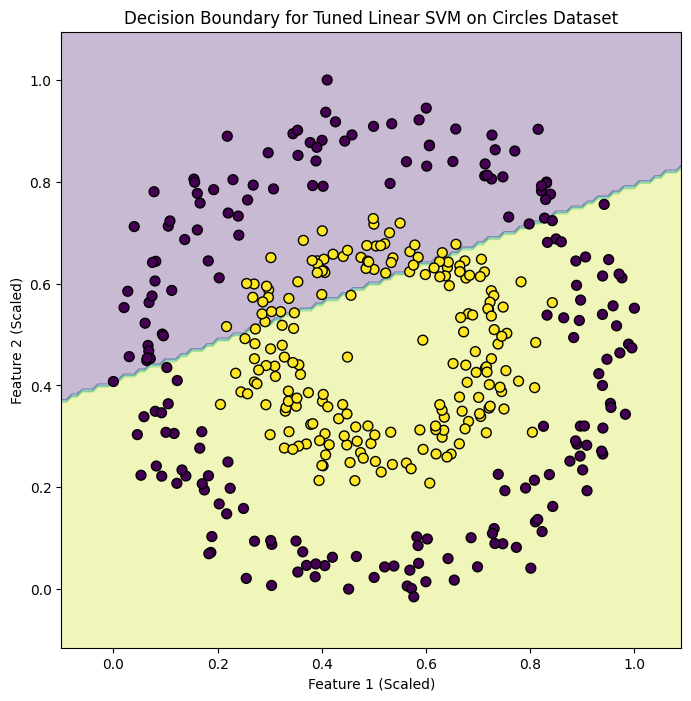

In [89]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_svm_circles, X_circles_scaled, y_circles_combined,
                       'Decision Boundary for Tuned Linear SVM on Circles Dataset')

As expected the model passed a line though the circles to separate them but unlike logistic regression (which passed the line through the center of the circles) SVM moved the line a little upwards to get most of the red class correctly while sacrificing some of the blue class, which resulted in a slightly higher accuracy, but still if we want a meaningful separation, we need to use a non linear model.

### 4.2.4. SVM (With Kernel!)

#### 4.2.4.1. Training

This is another nonlinear problem where we expect the kernel SVM to excel at. Using a kernel, it would try to find a higher dimensions where the circles are separable using a hyperplane.

We expect the model to outperform previous models and get a very high accuracy.

In [90]:
print("--- Training Kernel SVM on Circles Dataset ---")

print("\n1. Training a baseline Kernel SVM model (RBF kernel)...")
ksvm_circles_base = SVC(random_state=random_state)
ksvm_circles_base.fit(X_train_circles_scaled, y_train_circles)

y_pred_base_ksvm_circles = ksvm_circles_base.predict(X_test_circles_scaled)
base_accuracy_ksvm_circles = accuracy_score(y_test_circles, y_pred_base_ksvm_circles)
print(f"Baseline Kernel SVM Accuracy: {base_accuracy_ksvm_circles:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_circles, y_pred_base_ksvm_circles, zero_division=0))

--- Training Kernel SVM on Circles Dataset ---

1. Training a baseline Kernel SVM model (RBF kernel)...
Baseline Kernel SVM Accuracy: 1.0000
Baseline Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



The simple kernel SVM with rbf as the kernel managed to get a perfect score, so there is no need for tuning the hyper parameters but we will still run the hyper parameter tuning code from the previous datasets to see what happens.

#### 4.2.4.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Expanded Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best parameters found: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

3. Evaluating the tuned Kernel SVM model...
Tuned Kernel SVM Accuracy: 1.0000
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

Tuned Model Confusion Matrix:


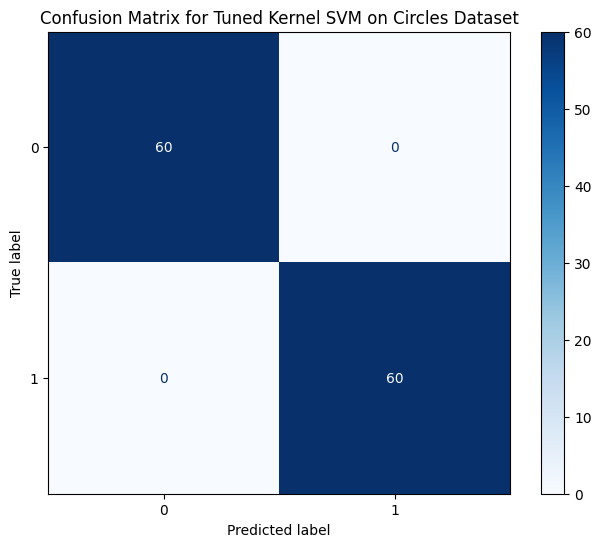

In [91]:
print("\n2. Performing Expanded Hyperparameter Tuning with GridSearchCV...")

param_grid_ksvm_expanded = [
    {'C': [0.001, 0.1, 1, 10, 100, 150], 'gamma': ['scale', 10, 1, 0.1, 0.01], 'kernel': ['rbf']},
    {'C': [0.001, 0.1, 1, 10, 100, 150], 'degree': [2, 3, 4], 'kernel': ['poly']},
    {'C': [0.001, 0.1, 1, 10, 100, 150], 'gamma': ['scale', 'auto'], 'kernel': ['sigmoid']}
]

grid_search_ksvm_circles = GridSearchCV(SVC(random_state=random_state),
                                        param_grid_ksvm_expanded, cv=5, n_jobs=-1, verbose=1)

grid_search_ksvm_circles.fit(X_train_circles_scaled, y_train_circles)

print("\nBest parameters found:", grid_search_ksvm_circles.best_params_)
best_ksvm_circles = grid_search_ksvm_circles.best_estimator_


print("\n3. Evaluating the tuned Kernel SVM model...")
y_pred_tuned_ksvm_circles = best_ksvm_circles.predict(X_test_circles_scaled)
tuned_accuracy_ksvm_circles = accuracy_score(y_test_circles, y_pred_tuned_ksvm_circles)

print(f"Tuned Kernel SVM Accuracy: {tuned_accuracy_ksvm_circles:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_circles, y_pred_tuned_ksvm_circles, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_ksvm_circles, X_test_circles_scaled, y_test_circles, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Kernel SVM on Circles Dataset')
plt.show()

As expected from the last section, the model got a perfect accuracy, next we will plot its decision boundaries.

#### 4.2.4.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundraies of the predictions.


4. Visualizing the Decision Boundary...


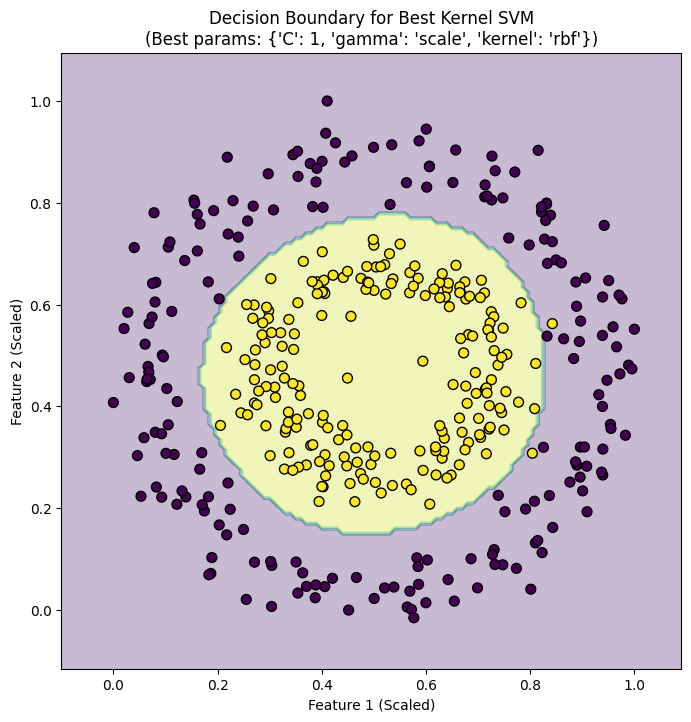

In [92]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_ksvm_circles, X_circles_scaled, y_circles_combined,
                       f'Decision Boundary for Best Kernel SVM\n(Best params: {grid_search_ksvm_circles.best_params_})')

From the decision boundaries we can see that with the use of kernel, the model was able to separate the circles quite well with only two misclassification of the red class, but since they were in the training dataset, the accuracy on the test dataset was 100%!

### 4.2.5. Decision Tree

#### 4.2.5.1. Training

Here we will train a single decision tree and later tune its parameters, decision trees are quite prone to overfitting so in order to remedy this we need to carefully set the hyperparameters (or use random forests which is the next algorithm we will look at!)

This is another nonlinear problem where we expect the decision tree to outperform linear models at. But only using vertical and horizontal lines, it might not be able to match the 100% accuracy of kernel SVM.

In [93]:
print("--- Training Decision Tree on Circles Dataset ---")

print("\n1. Training a baseline Decision Tree model...")
dt_circles_base = DecisionTreeClassifier(random_state=random_state)
dt_circles_base.fit(X_train_circles_scaled, y_train_circles)

y_pred_base_dt_circles = dt_circles_base.predict(X_test_circles_scaled)
base_accuracy_dt_circles = accuracy_score(y_test_circles, y_pred_base_dt_circles)
print(f"Baseline Decision Tree Accuracy: {base_accuracy_dt_circles:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_circles, y_pred_base_dt_circles, zero_division=0))

--- Training Decision Tree on Circles Dataset ---

1. Training a baseline Decision Tree model...
Baseline Decision Tree Accuracy: 0.9750
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97        60
           1       0.97      0.98      0.98        60

    accuracy                           0.97       120
   macro avg       0.98      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120



The simple decision tree managed to get a near perfect score, so there isn't much need for tuning the hyper parameters but we will still run the hyper parameter tuning code from the previous datasets to see what happens.

#### 4.2.5.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 160 candidates, totalling 800 fits

Best parameters found: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10}

3. Evaluating the tuned Decision Tree model...
Tuned Decision Tree Accuracy: 0.9833
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        60
           1       1.00      0.97      0.98        60

    accuracy                           0.98       120
   macro avg       0.98      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120

Tuned Model Confusion Matrix:


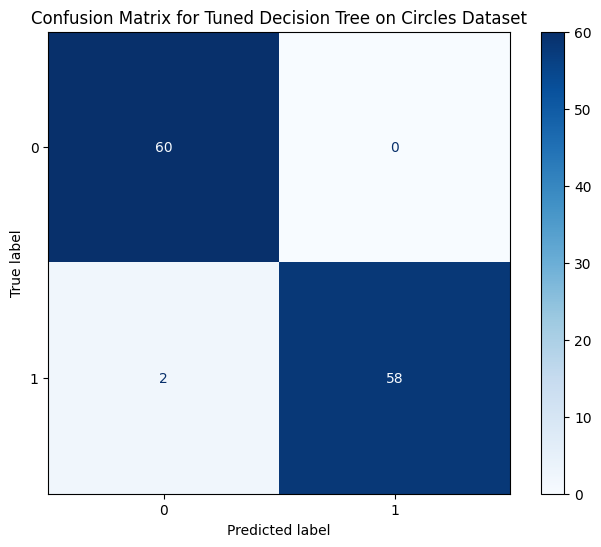

In [94]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8]
}

grid_search_dt_circles = GridSearchCV(DecisionTreeClassifier(random_state=random_state),
                                      param_grid_dt, cv=5, n_jobs=-1, verbose=1)

grid_search_dt_circles.fit(X_train_circles_scaled, y_train_circles)

print("\nBest parameters found:", grid_search_dt_circles.best_params_)
best_dt_circles = grid_search_dt_circles.best_estimator_

print("\n3. Evaluating the tuned Decision Tree model...")
y_pred_tuned_dt_circles = best_dt_circles.predict(X_test_circles_scaled)
tuned_accuracy_dt_circles = accuracy_score(y_test_circles, y_pred_tuned_dt_circles)

print(f"Tuned Decision Tree Accuracy: {tuned_accuracy_dt_circles:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_circles, y_pred_tuned_dt_circles, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_dt_circles, X_test_circles_scaled, y_test_circles, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Decision Tree on Circles Dataset')
plt.show()

After tuning the parameters, we managed to improve the accuracy of the model by 1%.

From the confusion matrix we can see there were only two instanced in the test data that were predicted incorrectly and both of them belonged to class 1, below we can see the decision boundaries of this model.

#### 4.2.5.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundaries of the predictions.


4. Visualizing the Decision Boundary...


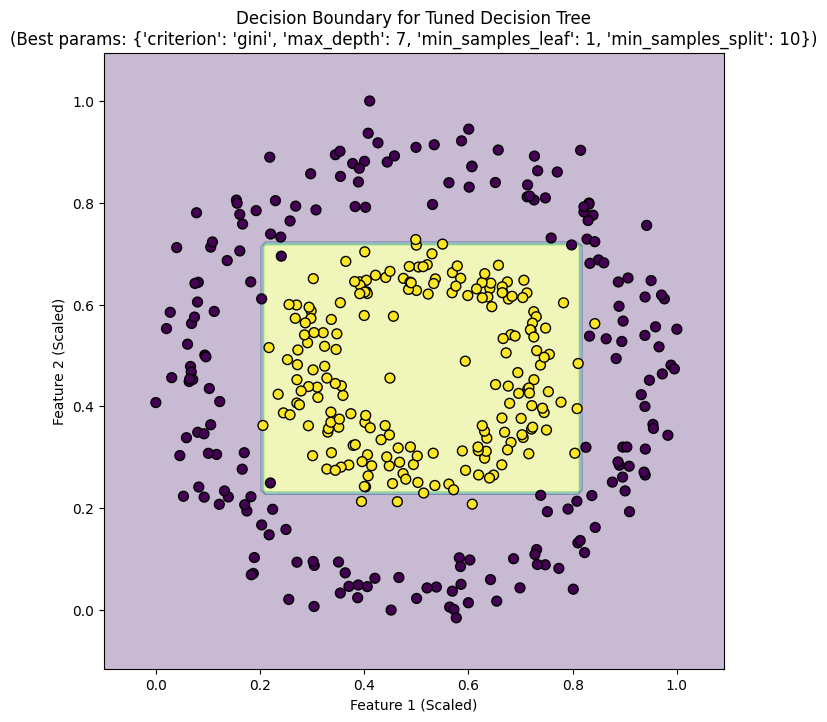

In [95]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_dt_circles, X_circles_scaled, y_circles_combined,
                       f'Decision Boundary for Tuned Decision Tree\n(Best params: {grid_search_dt_circles.best_params_})')

From the decision boundaries we can clearly see despite the circular nature of the data, the decision tree has boxed the yellow class in a rectangle, which has worked well but it lacks the ability to generalize to a noisier data (unlike the kernel SVM where the model had detected the circle almost perfectly)

### 4.2.6. Random Forest

#### 4.2.6.1. Training

Here we will train a random forest and later tune its parameters, random forest consist of multiple decision trees that have each been train of a portion of the data and then the final decision is made majority voting, the reason we use multiple decision trees is to prevent them from over fitting, another advantage of the random forest is the fact that it usually doesn't need much tuning.

This is another nonlinear problem where we expect the decision tree to outperform linear models at. And even show some improvement over a single decision tree (with its attempt at fitting the circles in a rectangle) but it might not be able to match the 100% accuracy of kernel SVM.

In [96]:
print("--- Training Random Forest on Circles Dataset ---")

print("\n1. Training a baseline Random Forest model...")
rf_circles_base = RandomForestClassifier(random_state=random_state, n_jobs=-1)
rf_circles_base.fit(X_train_circles_scaled, y_train_circles)

y_pred_base_rf_circles = rf_circles_base.predict(X_test_circles_scaled)
base_accuracy_rf_circles = accuracy_score(y_test_circles, y_pred_base_rf_circles)
print(f"Baseline Random Forest Accuracy: {base_accuracy_rf_circles:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_circles, y_pred_base_rf_circles, zero_division=0))

--- Training Random Forest on Circles Dataset ---

1. Training a baseline Random Forest model...
Baseline Random Forest Accuracy: 0.9750
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        60
           1       1.00      0.95      0.97        60

    accuracy                           0.97       120
   macro avg       0.98      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120



The simple random forest managed to get a near perfect score, so there isn't much need for tuning the hyper parameters but we will still run the hyper parameter tuning code from the previous datasets to see what happens.

#### 4.2.6.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
This may take a while as Random Forest has many parameters.
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters found: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

3. Evaluating the tuned Random Forest model...
Tuned Random Forest Accuracy: 0.9750
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        60
           1       1.00      0.95      0.97        60

    accuracy                           0.97       120
   macro avg       0.98      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120

Tuned Model Confusion Matrix:


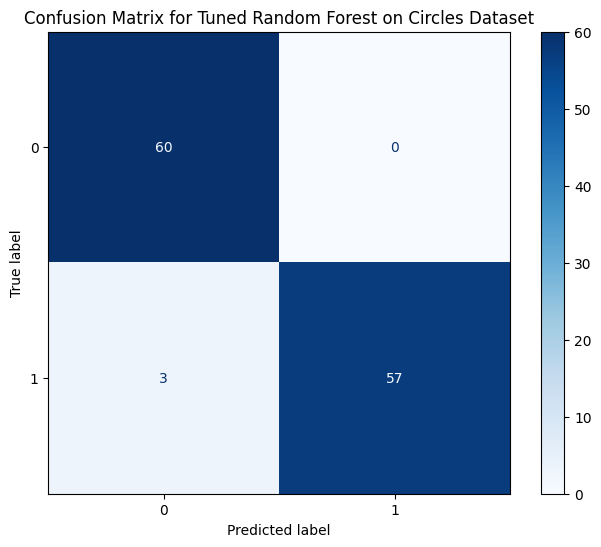

In [97]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")
print("This may take a while as Random Forest has many parameters.")

param_grid_rf = {
    'n_estimators': [50, 100, 200, 300, 1000],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 7],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf_circles = GridSearchCV(RandomForestClassifier(random_state=random_state, n_jobs=-1),
                                      param_grid_rf, cv=5, n_jobs=-1, verbose=1)

grid_search_rf_circles.fit(X_train_circles_scaled, y_train_circles)

print("\nBest parameters found:", grid_search_rf_circles.best_params_)
best_rf_circles = grid_search_rf_circles.best_estimator_


print("\n3. Evaluating the tuned Random Forest model...")
y_pred_tuned_rf_circles = best_rf_circles.predict(X_test_circles_scaled)
tuned_accuracy_rf_circles = accuracy_score(y_test_circles, y_pred_tuned_rf_circles)

print(f"Tuned Random Forest Accuracy: {tuned_accuracy_rf_circles:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_circles, y_pred_tuned_rf_circles, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_rf_circles, X_test_circles_scaled, y_test_circles, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Random Forest on Circles Dataset')
plt.show()

We didn't manage to improve the hyperparameters after fine tuning and got a result very similar to a single decision tree.

From the confusion matrix we can see there were only three instanced in the test data that were predicted incorrectly and all of them belonged to class 1, below we can see the decision boundaries of this model.

#### 4.2.6.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundaries of the predictions.


4. Visualizing the Decision Boundary...


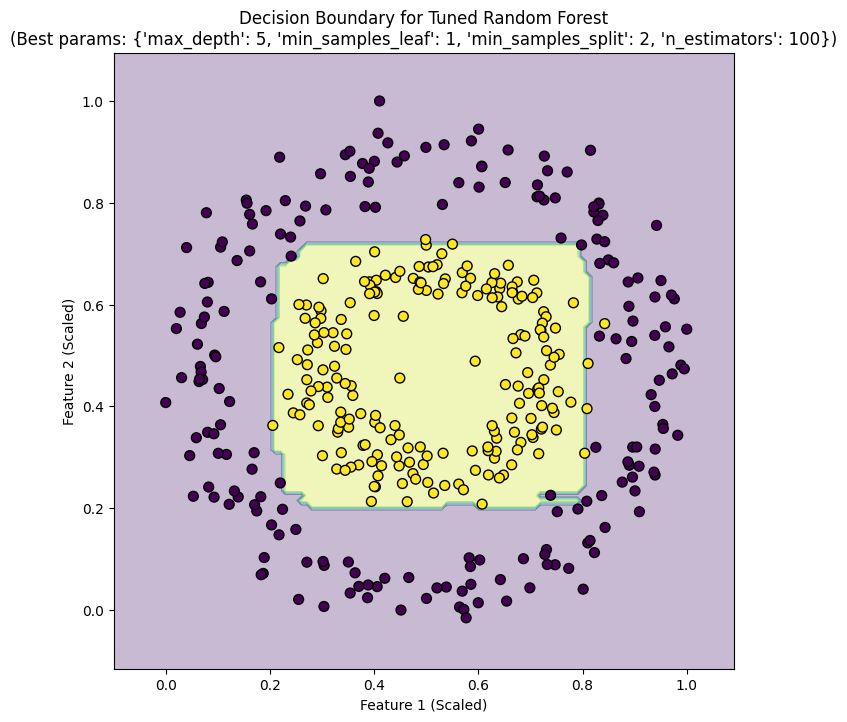

In [98]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_rf_circles, X_circles_scaled, y_circles_combined,
                       f'Decision Boundary for Tuned Random Forest\n(Best params: {grid_search_rf_circles.best_params_})')

From the decision boundaries we can clearly see despite the circular nature of the data, the decision tree has boxed the yellow class in a rectangle, which has worked well but it lacks the ability to generalize to a noisier data (unlike the kernel SVM where the model had detected the circle almost perfectly).

### 4.2.7. KNN

#### 4.2.7.1. Training

KNN is fundamentally different from all the previous models. It's a non-parametric algorithm, meaning it doesn't try to learn a model or a function from the training data. Instead, it memorizes the entire training dataset.

This is another nonlinear problem where we expect the KNN to outperform linear models at. But it might not be able to match the 100% accuracy of kernel SVM.

In [145]:
print("--- Training K-Nearest Neighbors (KNN) on Circles Dataset ---")

print("\n1. Training a baseline KNN model (K=5)...")
knn_circles_base = KNeighborsClassifier(n_neighbors=5)
knn_circles_base.fit(X_train_circles_scaled, y_train_circles)

y_pred_base_knn_circles = knn_circles_base.predict(X_test_circles_scaled)
base_accuracy_knn_circles = accuracy_score(y_test_circles, y_pred_base_knn_circles)
print(f"Baseline KNN Accuracy: {base_accuracy_knn_circles:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_circles, y_pred_base_knn_circles, zero_division=0))

--- Training K-Nearest Neighbors (KNN) on Circles Dataset ---

1. Training a baseline KNN model (K=5)...
Baseline KNN Accuracy: 0.9917
Baseline Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        60
           1       0.98      1.00      0.99        60

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



Even without any tuning, the KNN managed to ge a 99% accuracy, becoming the second most accurate algorithm after the kernel SVM.

#### 4.2.7.2. Hyperparameter Tuning


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters found: {'metric': 'euclidean', 'n_neighbors': 2, 'weights': 'uniform'}

3. Evaluating the tuned KNN model...
Tuned KNN Accuracy: 0.9917
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        60
           1       1.00      0.98      0.99        60

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120

Tuned Model Confusion Matrix:


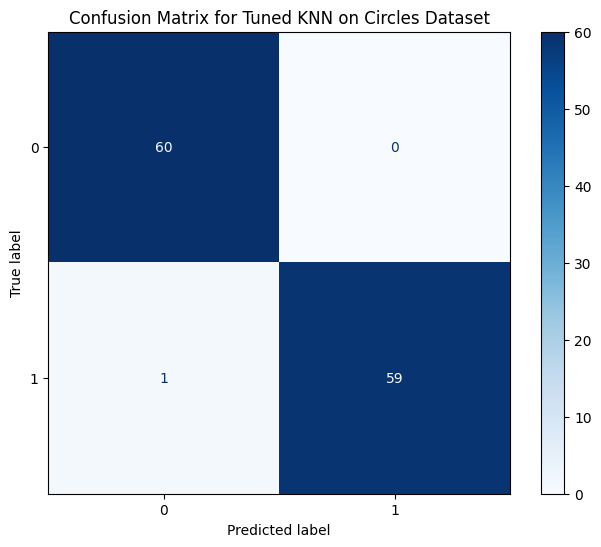

In [146]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_knn = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search_knn_circles = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, n_jobs=-1, verbose=1)

grid_search_knn_circles.fit(X_train_circles_scaled, y_train_circles)

print("\nBest parameters found:", grid_search_knn_circles.best_params_)
best_knn_circles = grid_search_knn_circles.best_estimator_


print("\n3. Evaluating the tuned KNN model...")
y_pred_tuned_knn_circles = best_knn_circles.predict(X_test_circles_scaled)
tuned_accuracy_knn_circles = accuracy_score(y_test_circles, y_pred_tuned_knn_circles)

print(f"Tuned KNN Accuracy: {tuned_accuracy_knn_circles:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_circles, y_pred_tuned_knn_circles, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_knn_circles, X_test_circles_scaled, y_test_circles, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned KNN on Circles Dataset')
plt.show()

Tuning the hyperparameters didn't really improve the performance of the model. An interesting observation here is that the best performing model only used the 2 closest neighbours, which makes sense as the closest neighbour is most likely from the same circle!

From the confusion matrix we can see that only a single one of the test data was mislabeled.

#### 4.2.7.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundaries of the predictions.


4. Visualizing the Decision Boundary...


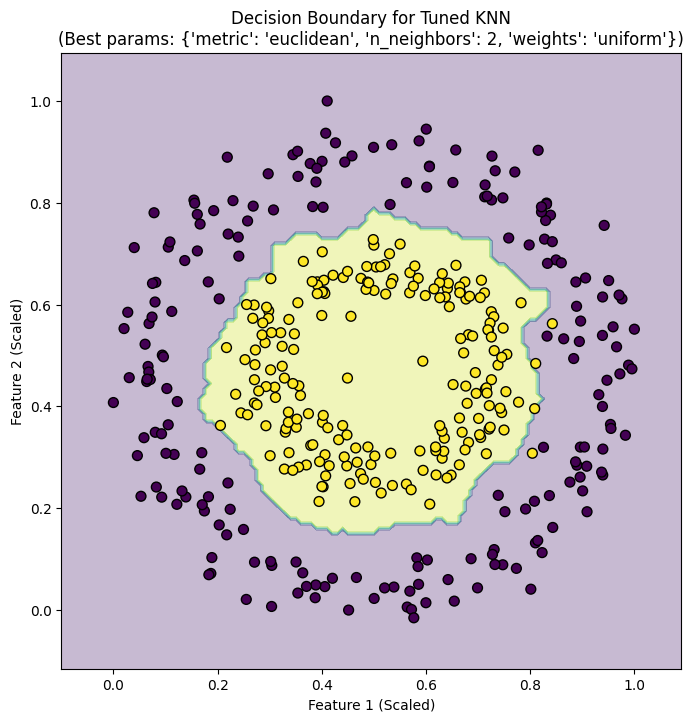

In [147]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_knn_circles, X_circles_scaled, y_circles_combined,
                       f'Decision Boundary for Tuned KNN\n(Best params: {grid_search_knn_circles.best_params_})')

While the boundaries of the KNN aren't perfect circles like kernel SVM, they are still much better than the boxed shape boundaries of the random forest, despite the minor difference in their accuracy.

# 5. Moons (Interleaving Half-Circles)

## 5.1. Data Preprocessing

### 5.1.1. Creating the Dataset and Visualising

In [99]:
from sklearn.datasets import make_moons
X_moons, y_moons = make_moons(n_samples=400, noise=0.2, random_state=7)

In [100]:
X_moons.shape

(400, 2)

In [101]:
y_moons.shape

(400,)

This dataset is also 400 points with two features, so we will visualise it the same way:

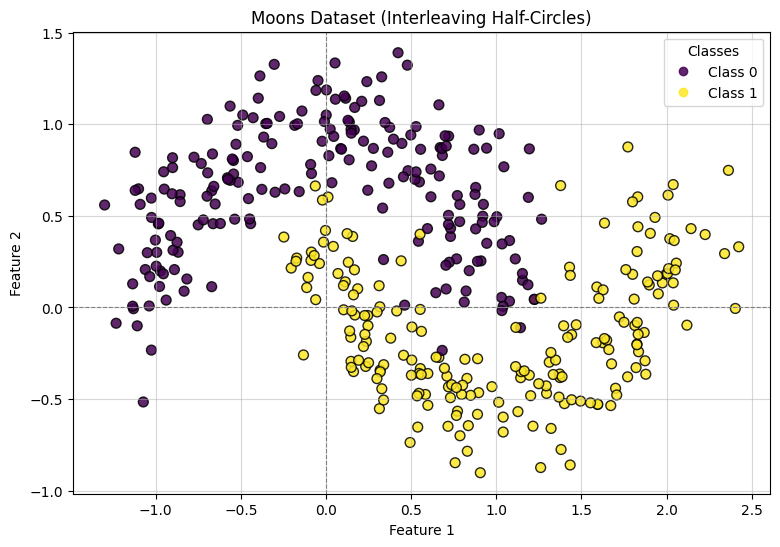

In [102]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', edgecolor='k', s=50, alpha=0.85)

plt.title('Moons Dataset (Interleaving Half-Circles)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.5)
plt.axhline(0, color='grey', lw=0.8, linestyle='--')
plt.axvline(0, color='grey', lw=0.8, linestyle='--')

handles, _ = scatter.legend_elements()
class_labels = [f'Class {i}' for i in np.unique(y_moons)]
plt.legend(handles, class_labels, title="Classes")

plt.show()

As we can see this dataset is also nonlinearly sperable so we would probably run to the same issues with the linear algorithms.

Next let's look at the feature distribution to see which scalar is best to use

--- Overall Feature Distributions (Moons Dataset) ---


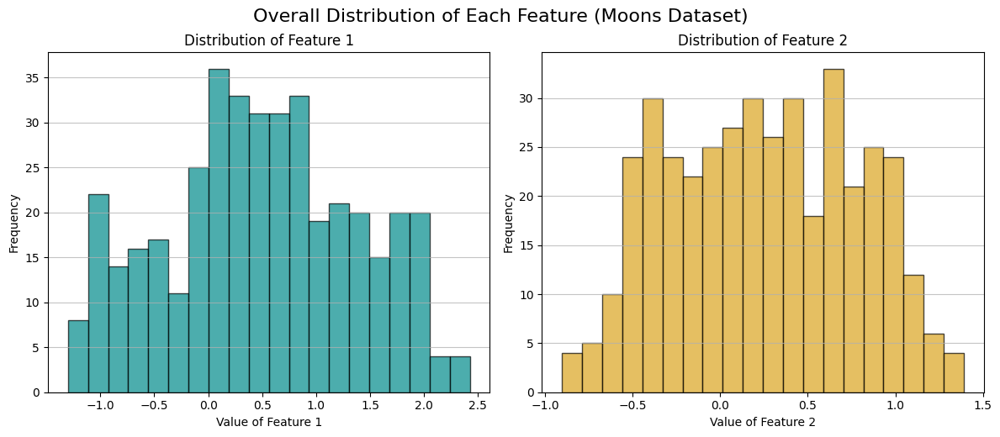


--- Feature Distributions by Class (Moons Dataset) ---


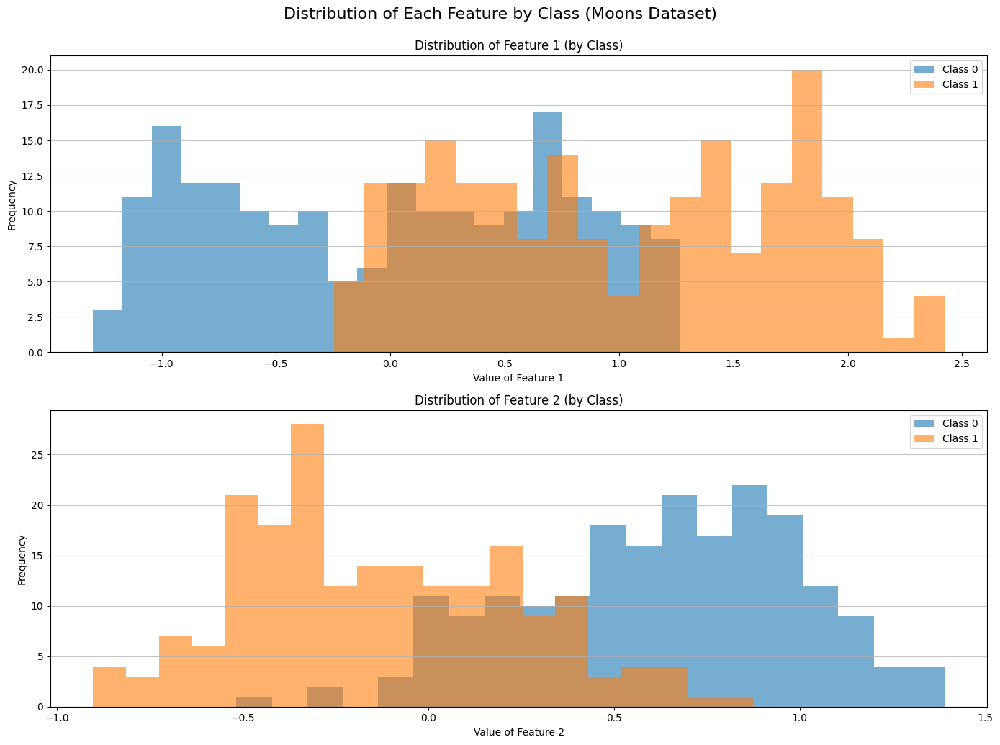

In [103]:
# --- Plotting Histograms for Each Feature (Overall Distribution) ---
print("--- Overall Feature Distributions (Moons Dataset) ---")
plt.figure(figsize=(12, 5))

# Feature 1
plt.subplot(1, 2, 1)
plt.hist(X_moons[:, 0], bins=20, color='darkcyan', edgecolor='black', alpha=0.7)
plt.title('Distribution of Feature 1')
plt.xlabel('Value of Feature 1')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Feature 2
plt.subplot(1, 2, 2)
plt.hist(X_moons[:, 1], bins=20, color='goldenrod', edgecolor='black', alpha=0.7)
plt.title('Distribution of Feature 2')
plt.xlabel('Value of Feature 2')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.suptitle('Overall Distribution of Each Feature (Moons Dataset)', fontsize=16, y=1.03)
plt.show()


# --- Plotting Histograms for Each Feature, Separated by Class ---
print("\n--- Feature Distributions by Class (Moons Dataset) ---")
unique_classes_moons = np.unique(y_moons)
colors_moons = ['#1f77b4', '#ff7f0e']

plt.figure(figsize=(14, 10))

# Feature 1 with class separation
plt.subplot(2, 1, 1)
for cls_idx, cls in enumerate(unique_classes_moons):
    plt.hist(X_moons[y_moons == cls, 0], bins=20, alpha=0.6, label=f'Class {cls}', color=colors_moons[cls_idx])
plt.title('Distribution of Feature 1 (by Class)')
plt.xlabel('Value of Feature 1')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)

# Feature 2 with class separation
plt.subplot(2, 1, 2)
for cls_idx, cls in enumerate(unique_classes_moons):
    plt.hist(X_moons[y_moons == cls, 1], bins=20, alpha=0.6, label=f'Class {cls}', color=colors_moons[cls_idx])
plt.title('Distribution of Feature 2 (by Class)')
plt.xlabel('Value of Feature 2')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.suptitle('Distribution of Each Feature by Class (Moons Dataset)', fontsize=16, y=1.03)
plt.show()

Since the features aren't normally distributed we will be using a min-max scalar in the next section to scale them

### 5.1.2. Splitting & Scaling

Here we will split the data and scale it for the models using a min-max scalaer

In [104]:
X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=random_state, stratify=y_moons
)
scaler_moons = MinMaxScaler()

scaler_moons.fit(X_train_moons)

X_train_moons_scaled = scaler_moons.transform(X_train_moons)
X_test_moons_scaled = scaler_moons.transform(X_test_moons)

Now we will visualise the splitted data again to chack for any potential issues.

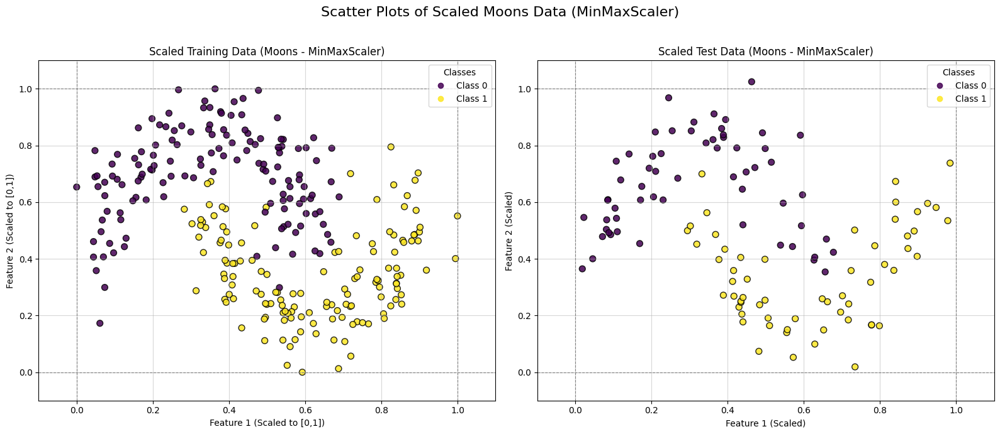

In [105]:
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
scatter_train = plt.scatter(X_train_moons_scaled[:, 0], X_train_moons_scaled[:, 1],
                            c=y_train_moons, cmap='viridis', edgecolor='k', s=50, alpha=0.85)
plt.title('Scaled Training Data (Moons - MinMaxScaler)')
plt.xlabel('Feature 1 (Scaled to [0,1])')
plt.ylabel('Feature 2 (Scaled to [0,1])')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.5)
plt.axhline(0, color='grey', lw=0.8, linestyle='--')
plt.axvline(0, color='grey', lw=0.8, linestyle='--')
plt.axhline(1, color='grey', lw=0.8, linestyle='--')
plt.axvline(1, color='grey', lw=0.8, linestyle='--')

handles_train, _ = scatter_train.legend_elements()
class_labels_train = [f'Class {i}' for i in np.unique(y_train_moons)]
plt.legend(handles_train, class_labels_train, title="Classes")

plt.subplot(1, 2, 2)
scatter_test = plt.scatter(X_test_moons_scaled[:, 0], X_test_moons_scaled[:, 1],
                           c=y_test_moons, cmap='viridis', edgecolor='k', s=50, alpha=0.85)
plt.title('Scaled Test Data (Moons - MinMaxScaler)')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.5)
plt.axhline(0, color='grey', lw=0.8, linestyle='--')
plt.axvline(0, color='grey', lw=0.8, linestyle='--')
plt.axhline(1, color='grey', lw=0.8, linestyle='--')
plt.axvline(1, color='grey', lw=0.8, linestyle='--')

handles_test, _ = scatter_test.legend_elements()
class_labels_test = [f'Class {i}' for i in np.unique(y_test_moons)]
plt.legend(handles_test, class_labels_test, title="Classes")


plt.suptitle('Scatter Plots of Scaled Moons Data (MinMaxScaler)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 5.2. Model Training and Hyperparamter Tuning

### 5.2.1. Preceptron

#### 5.2.1.1. Training

Here we will train a simple preceptron and tune its parameters, since the data isn't very well seperated (by using a single line) we don't excpect a very high accuracy.

In [106]:
print("\n1. Training a baseline Perceptron model...")
perceptron_moons_base = Perceptron(random_state=random_state)
perceptron_moons_base.fit(X_train_moons_scaled, y_train_moons)

y_pred_moons_base = perceptron_moons_base.predict(X_test_moons_scaled)
base_accuracy_moons = accuracy_score(y_test_moons, y_pred_moons_base)
print(f"Baseline Perceptron Accuracy: {base_accuracy_moons:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_moons, y_pred_moons_base, zero_division=0))


1. Training a baseline Perceptron model...
Baseline Perceptron Accuracy: 0.8500
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.92      0.86        60
           1       0.90      0.78      0.84        60

    accuracy                           0.85       120
   macro avg       0.86      0.85      0.85       120
weighted avg       0.86      0.85      0.85       120



To my surprise the mdoel was able to achieve a 85% accuracy with a high f1 score, showing that there might be some performance gain with tuning the hyperparameters!

#### 5.2.1.2. Hyperparameter Tuning

So to improve the preformance even further we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardell of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters found: {'alpha': 0.0001, 'eta0': 0.1, 'max_iter': 1000, 'penalty': 'elasticnet'}

3. Evaluating the tuned Perceptron model...
Tuned Perceptron Accuracy: 0.8417
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.85        60
           1       0.90      0.77      0.83        60

    accuracy                           0.84       120
   macro avg       0.85      0.84      0.84       120
weighted avg       0.85      0.84      0.84       120

Tuned Model Confusion Matrix:


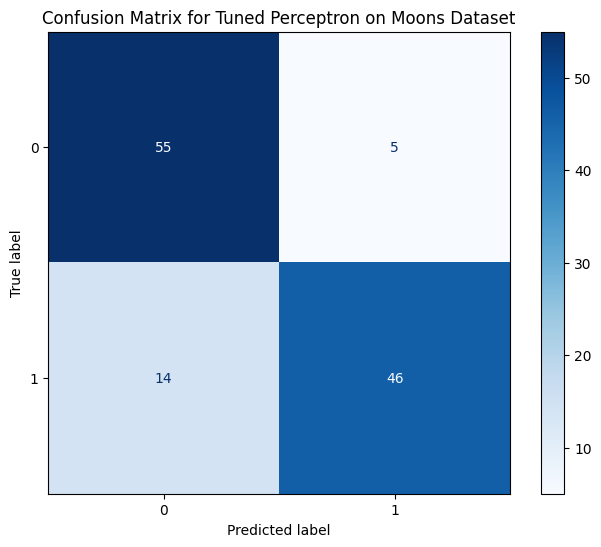

In [107]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_perceptron = {
    'eta0': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'max_iter': [1000, 2000, 3000],
    'penalty': ['l2', 'l1', 'elasticnet', None],
    'alpha': [0.0001, 0.001, 0.01]
}

grid_search_moons = GridSearchCV(Perceptron(random_state=random_state), param_grid_perceptron, cv=5, n_jobs=-1, verbose=1)
grid_search_moons.fit(X_train_moons_scaled, y_train_moons)

print("\nBest parameters found:", grid_search_moons.best_params_)
best_perceptron_moons = grid_search_moons.best_estimator_


print("\n3. Evaluating the tuned Perceptron model...")
y_pred_moons_tuned = best_perceptron_moons.predict(X_test_moons_scaled)
tuned_accuracy_moons = accuracy_score(y_test_moons, y_pred_moons_tuned)

print(f"Tuned Perceptron Accuracy: {tuned_accuracy_moons:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_moons, y_pred_moons_tuned, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_perceptron_moons, X_test_moons_scaled, y_test_moons, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Perceptron on Moons Dataset')
plt.show()

The performance of the model didn't improve much with different parameters, indicating that maybe the model has reached its full capabality for this relatively non linear dataset.

From the confusion matrix we can see the model struggled most with detecting instances of class lable 1.

Next we draw its desicion boundry to get a better undrestanding of how the model splits the two classes.

#### 5.2.1.3. Visualising the Predictions

Since we had only two features, we will use a code simillar to the one in the book to visualise the decision boundraies of the predictions.


4. Visualizing the Decision Boundary...


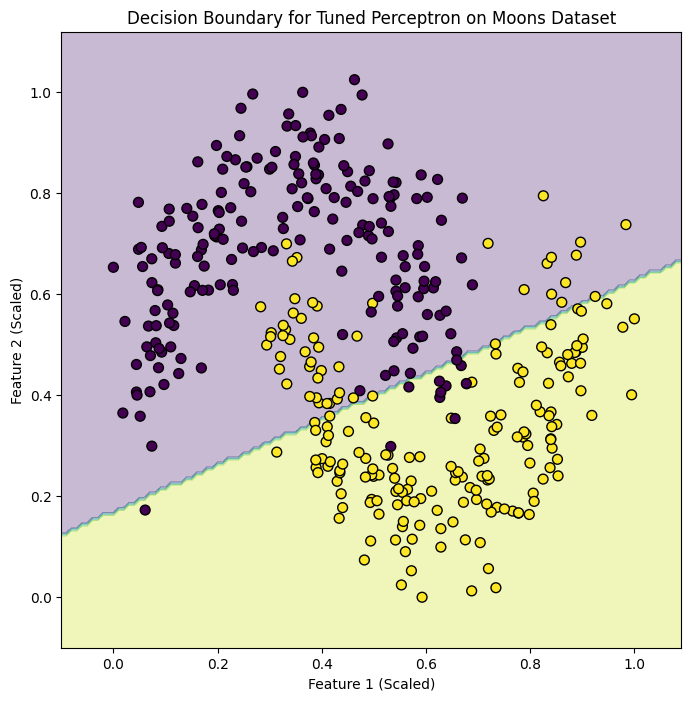

In [108]:
print("\n4. Visualizing the Decision Boundary...")

X_moons_scaled = np.vstack((X_train_moons_scaled, X_test_moons_scaled))
y_moons_combined = np.hstack((y_train_moons, y_test_moons))

plot_decision_boundary(best_perceptron_moons, X_moons_scaled, y_moons_combined,
                       'Decision Boundary for Tuned Perceptron on Moons Dataset')

As excpected the model tried to cross a line between the two group and splitting them 50, 50 the best it could, but since the classes are shaped like moon, they can't be fully seperated using a single line.

Here an algorithm for clustering like DBSCAN might work better (even though it's an unsupervised algorithm and doesn't uses the lables, it is quite good at clustering these kind of datasets!)

### 5.2.2. Logistic Regression

#### 5.2.2.1. Training

Here we will train a simple logistic regression and tune its parameters. The data can't be quite seperated by a single line but judging based on the perfomrance of the perceptron, we can assume that the logistic regression would also be able to get around 80% of accuracy

In [109]:
print("--- Training Logistic Regression on Moons Dataset ---")
print("NOTE: We expect the linear Logistic Regression model to struggle with this non-linear dataset.")

print("\n1. Training a baseline Logistic Regression model...")
log_reg_moons_base = LogisticRegression(random_state=random_state, max_iter=1000)
log_reg_moons_base.fit(X_train_moons_scaled, y_train_moons)

y_pred_moons_base_lr = log_reg_moons_base.predict(X_test_moons_scaled)
base_accuracy_moons_lr = accuracy_score(y_test_moons, y_pred_moons_base_lr)
print(f"Baseline Logistic Regression Accuracy: {base_accuracy_moons_lr:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_moons, y_pred_moons_base_lr, zero_division=0))

--- Training Logistic Regression on Moons Dataset ---
NOTE: We expect the linear Logistic Regression model to struggle with this non-linear dataset.

1. Training a baseline Logistic Regression model...
Baseline Logistic Regression Accuracy: 0.8833
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88        60
           1       0.87      0.90      0.89        60

    accuracy                           0.88       120
   macro avg       0.88      0.88      0.88       120
weighted avg       0.88      0.88      0.88       120



As excpected, the logistic regression modle got an accurayc of 80%+ (88%)

Next we will try to tune the hyperparameters to se if we can improve it even further.

#### 5.2.2.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardell of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found: {'C': 1, 'l1_ratio': 0.5, 'max_iter': 1000, 'penalty': 'elasticnet', 'solver': 'saga'}

3. Evaluating the tuned Logistic Regression model...
Tuned Logistic Regression Accuracy: 0.8833
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88        60
           1       0.87      0.90      0.89        60

    accuracy                           0.88       120
   macro avg       0.88      0.88      0.88       120
weighted avg       0.88      0.88      0.88       120

Tuned Model Confusion Matrix:


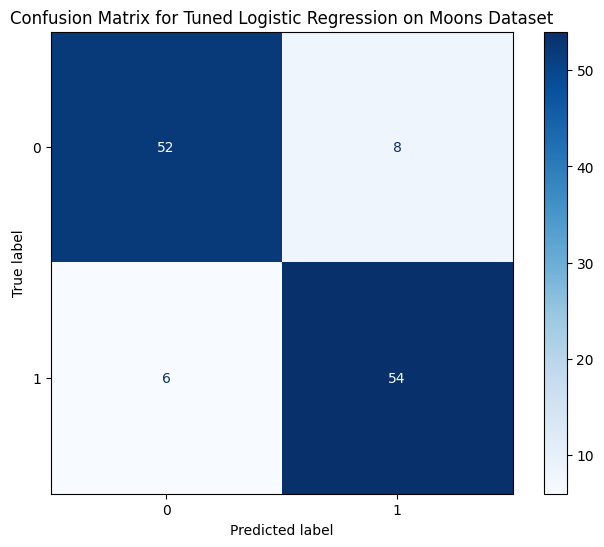

In [110]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_lr = [
    {
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000, 2000]
    },
    {
        'penalty': ['elasticnet'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['saga'],
        'l1_ratio': [0.5],
        'max_iter': [1000, 2000]
    }
]

grid_search_moons_lr = GridSearchCV(LogisticRegression(random_state=random_state),
                                    param_grid_lr, cv=5, n_jobs=-1, verbose=1)
grid_search_moons_lr.fit(X_train_moons_scaled, y_train_moons)

print("\nBest parameters found:", grid_search_moons_lr.best_params_)
best_log_reg_moons = grid_search_moons_lr.best_estimator_


print("\n3. Evaluating the tuned Logistic Regression model...")
y_pred_moons_tuned_lr = best_log_reg_moons.predict(X_test_moons_scaled)
tuned_accuracy_moons_lr = accuracy_score(y_test_moons, y_pred_moons_tuned_lr)

print(f"Tuned Logistic Regression Accuracy: {tuned_accuracy_moons_lr:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_moons, y_pred_moons_tuned_lr, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_log_reg_moons, X_test_moons_scaled, y_test_moons, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Logistic Regression on Moons Dataset')
plt.show()

Fine tuning the model didn't result in any significant change in the result, indicating that the model has reached its limit and only using a single line to seperate the classes won't be enough. This can be clearly seen the in decision bsoundries in the next section

#### 5.2.2.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundraies of the predictions.


4. Visualizing the Decision Boundary...


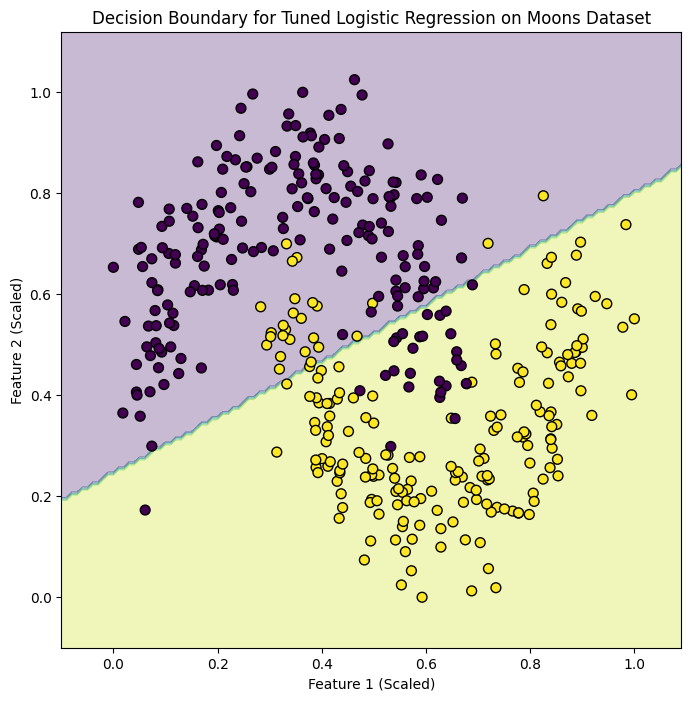

In [111]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_log_reg_moons, X_moons_scaled, y_moons_combined,
                       'Decision Boundary for Tuned Logistic Regression on Moons Dataset')

As we can see, despite achieving a 88% accuracy, we can clearly see that a single line is unable to properly distinguish the classes, to get a better result we need to resort to non linear methods

### 5.2.3. SVM (with no kernel)

#### 5.2.3.1. Training

Here we will train a simple SVM and tune its parameters. The data can't be quite seperated by a single line but judging based on the perfomrance of the perceptron and logistic regression, we can assume that the SVM would also be able to get around 80% of accuracy

In [112]:
print("--- Training Linear SVM on Moons Dataset ---")

print("\n1. Training a baseline Linear SVM model...")
svm_moons_base = SVC(kernel='linear', random_state=random_state)
svm_moons_base.fit(X_train_moons_scaled, y_train_moons)

y_pred_base_svm_moons = svm_moons_base.predict(X_test_moons_scaled)
base_accuracy_svm_moons = accuracy_score(y_test_moons, y_pred_base_svm_moons)
print(f"Baseline Linear SVM Accuracy: {base_accuracy_svm_moons:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_moons, y_pred_base_svm_moons, zero_division=0))

--- Training Linear SVM on Moons Dataset ---

1. Training a baseline Linear SVM model...
Baseline Linear SVM Accuracy: 0.8833
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88        60
           1       0.87      0.90      0.89        60

    accuracy                           0.88       120
   macro avg       0.88      0.88      0.88       120
weighted avg       0.88      0.88      0.88       120



As expected, the SVM model got an accuracy of 80%+ (88%)

Next we will try to tune the hyperparameters to se if we can improve it even further.

#### 5.2.3.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best parameters found: {'C': 1}

3. Evaluating the tuned Linear SVM model...
Tuned Linear SVM Accuracy: 0.8833
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88        60
           1       0.87      0.90      0.89        60

    accuracy                           0.88       120
   macro avg       0.88      0.88      0.88       120
weighted avg       0.88      0.88      0.88       120

Tuned Model Confusion Matrix:


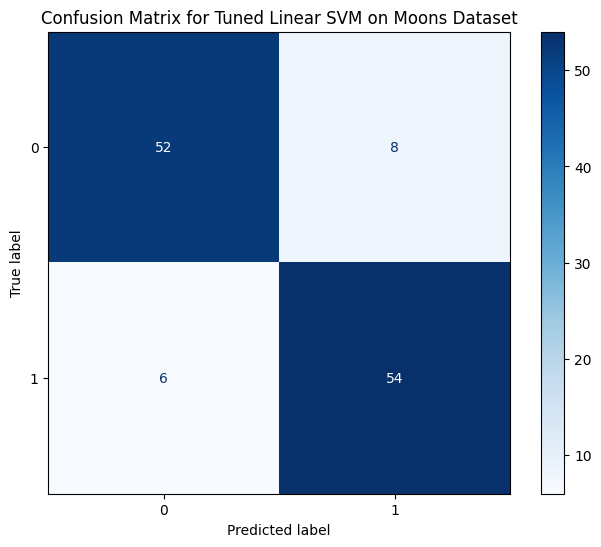

In [113]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_svm = {
    'C': [0.1, 1, 10, 100, 1000]
}

grid_search_svm_moons = GridSearchCV(SVC(kernel='linear', random_state=random_state),
                                     param_grid_svm, cv=5, n_jobs=-1, verbose=1)

grid_search_svm_moons.fit(X_train_moons_scaled, y_train_moons)

print("\nBest parameters found:", grid_search_svm_moons.best_params_)
best_svm_moons = grid_search_svm_moons.best_estimator_

print("\n3. Evaluating the tuned Linear SVM model...")
y_pred_tuned_svm_moons = best_svm_moons.predict(X_test_moons_scaled)
tuned_accuracy_svm_moons = accuracy_score(y_test_moons, y_pred_tuned_svm_moons)

print(f"Tuned Linear SVM Accuracy: {tuned_accuracy_svm_moons:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_moons, y_pred_tuned_svm_moons, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_svm_moons, X_test_moons_scaled, y_test_moons, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Linear SVM on Moons Dataset')
plt.show()

Fine tuning the model didn't result in any significant change in the result, indicating that the model has reached its limit and only using a single line to separate the classes won't be enough. This can be clearly seen the in decision boundaries in the next section

#### 5.2.3.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundraies of the predictions.


4. Visualizing the Decision Boundary...


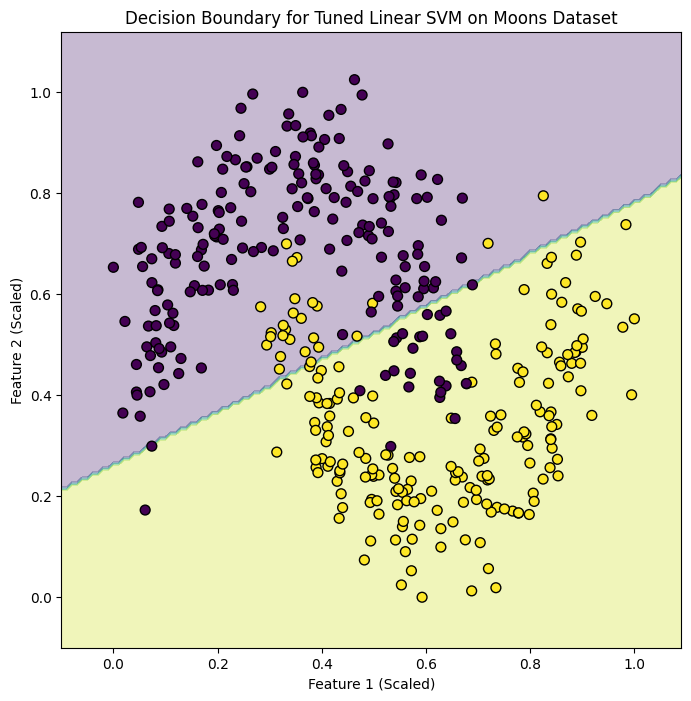

In [114]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_svm_moons, X_moons_scaled, y_moons_combined,
                       'Decision Boundary for Tuned Linear SVM on Moons Dataset')

As we can see, despite achieving a 88% accuracy, we can clearly see that a single line is unable to properly distinguish the classes, to get a better result we need to resort to non linear methods.

### 5.2.4. SVM (with kernel)

#### 5.2.4.1. Training

Here we will train a simple SVM and tune its parameters. The data can't be quite seperated by a single line so we expect with the use of a kernel we will get a higher accuracy than pervious models (more than 80%)

In [115]:
print("--- Training Kernel SVM on Moons Dataset ---")

print("\n1. Training a baseline Kernel SVM model (RBF kernel)...")
ksvm_moons_base = SVC(random_state=random_state)
ksvm_moons_base.fit(X_train_moons_scaled, y_train_moons)

y_pred_base_ksvm_moons = ksvm_moons_base.predict(X_test_moons_scaled)
base_accuracy_ksvm_moons = accuracy_score(y_test_moons, y_pred_base_ksvm_moons)
print(f"Baseline Kernel SVM Accuracy: {base_accuracy_ksvm_moons:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_moons, y_pred_base_ksvm_moons, zero_division=0))

--- Training Kernel SVM on Moons Dataset ---

1. Training a baseline Kernel SVM model (RBF kernel)...
Baseline Kernel SVM Accuracy: 0.9417
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94        60
           1       0.91      0.98      0.94        60

    accuracy                           0.94       120
   macro avg       0.94      0.94      0.94       120
weighted avg       0.94      0.94      0.94       120



As expected, even without any parameter tuning we got an accuracy of 94% from the default settings, next we will try to improve this even further by tuning the parameters!

#### 5.2.4.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Expanded Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best parameters found: {'C': 1, 'gamma': 10, 'kernel': 'rbf'}

3. Evaluating the tuned Kernel SVM model...
Tuned Kernel SVM Accuracy: 0.9500
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        60
           1       0.92      0.98      0.95        60

    accuracy                           0.95       120
   macro avg       0.95      0.95      0.95       120
weighted avg       0.95      0.95      0.95       120

Tuned Model Confusion Matrix:


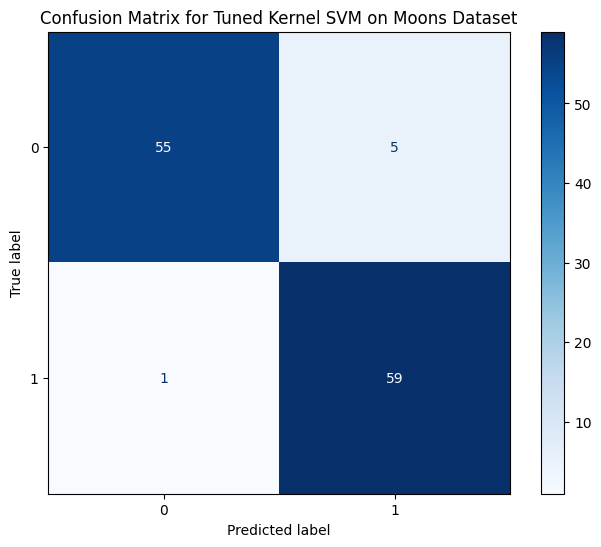

In [116]:
print("\n2. Performing Expanded Hyperparameter Tuning with GridSearchCV...")

param_grid_ksvm_expanded = [
    {'C': [0.001, 0.1, 1, 10, 100, 150], 'gamma': ['scale', 10, 1, 0.1, 0.01], 'kernel': ['rbf']},
    {'C': [0.001, 0.1, 1, 10, 100, 150], 'degree': [2, 3, 4], 'kernel': ['poly']},
    {'C': [0.001, 0.1, 1, 10, 100, 150], 'gamma': ['scale', 'auto'], 'kernel': ['sigmoid']}
]

grid_search_ksvm_moons = GridSearchCV(SVC(random_state=random_state),
                                      param_grid_ksvm_expanded, cv=5, n_jobs=-1, verbose=1)

grid_search_ksvm_moons.fit(X_train_moons_scaled, y_train_moons)

print("\nBest parameters found:", grid_search_ksvm_moons.best_params_)
best_ksvm_moons = grid_search_ksvm_moons.best_estimator_


print("\n3. Evaluating the tuned Kernel SVM model...")
y_pred_tuned_ksvm_moons = best_ksvm_moons.predict(X_test_moons_scaled)
tuned_accuracy_ksvm_moons = accuracy_score(y_test_moons, y_pred_tuned_ksvm_moons)

print(f"Tuned Kernel SVM Accuracy: {tuned_accuracy_ksvm_moons:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_moons, y_pred_tuned_ksvm_moons, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_ksvm_moons, X_test_moons_scaled, y_test_moons, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Kernel SVM on Moons Dataset')
plt.show()

Fine tuning the model only increased the accuracy slightly. From the confusion matrix we can see only 6 instances were misclassified and most of them belonged to class 0.

#### 5.2.4.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundraies of the predictions.


4. Visualizing the Decision Boundary...


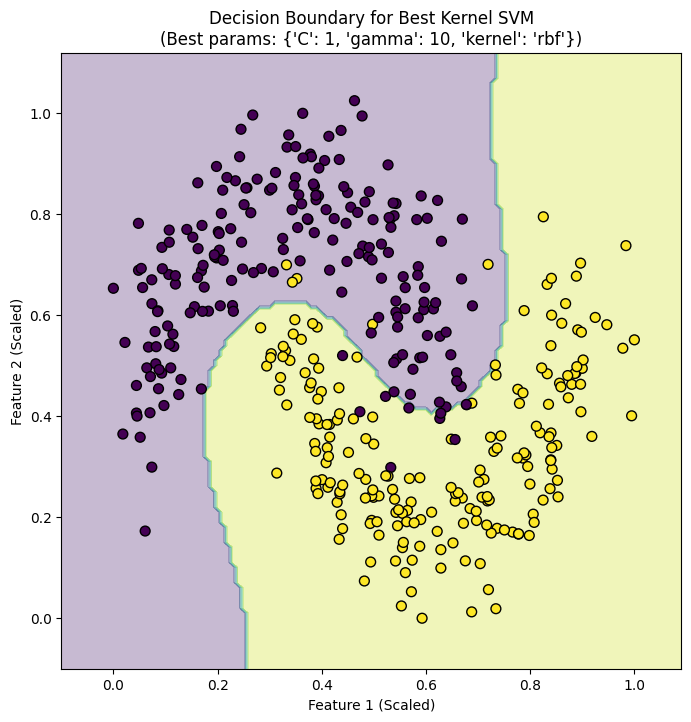

In [117]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_ksvm_moons, X_moons_scaled, y_moons_combined,
                       f'Decision Boundary for Best Kernel SVM\n(Best params: {grid_search_ksvm_moons.best_params_})')

From the decision boundaries we can see that the model has distinguished the two classes quite well and most of the misclassifications were outliers of their class so overall using a kernel resulted a good separation between the classed in the higher dimension space.

### 5.2.5. Decision Tree

#### 5.2.5.1. Training

Here we will train a single decision tree and later tune its parameters, decision trees are quite prone to overfitting so in order to remedy this we need to carefully set the hyperparameters (or use random forests which is the next algorithm we will look at!)

Since the data isn't quite linear and the kernel SVM got an accuracy of 94%, we expect the decision tree to also get a good 90+% accuracy on it.

In [118]:
print("--- Training Decision Tree on Moons Dataset ---")

print("\n1. Training a baseline Decision Tree model...")
dt_moons_base = DecisionTreeClassifier(random_state=random_state)
dt_moons_base.fit(X_train_moons_scaled, y_train_moons)

y_pred_base_dt_moons = dt_moons_base.predict(X_test_moons_scaled)
base_accuracy_dt_moons = accuracy_score(y_test_moons, y_pred_base_dt_moons)
print(f"Baseline Decision Tree Accuracy: {base_accuracy_dt_moons:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_moons, y_pred_base_dt_moons, zero_division=0))

--- Training Decision Tree on Moons Dataset ---

1. Training a baseline Decision Tree model...
Baseline Decision Tree Accuracy: 0.9583
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96        60
           1       0.94      0.98      0.96        60

    accuracy                           0.96       120
   macro avg       0.96      0.96      0.96       120
weighted avg       0.96      0.96      0.96       120



Surprisingly the base decision model tree without any hyperparameter tuning managed to outperform the best kernel SVM by getting a 96% accuracy, next we will try to tune the parameters to see if we can improve this accuracy ro not.

#### 5.2.5.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 160 candidates, totalling 800 fits

Best parameters found: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2}

3. Evaluating the tuned Decision Tree model...
Tuned Decision Tree Accuracy: 0.9583
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96        60
           1       0.94      0.98      0.96        60

    accuracy                           0.96       120
   macro avg       0.96      0.96      0.96       120
weighted avg       0.96      0.96      0.96       120

Tuned Model Confusion Matrix:


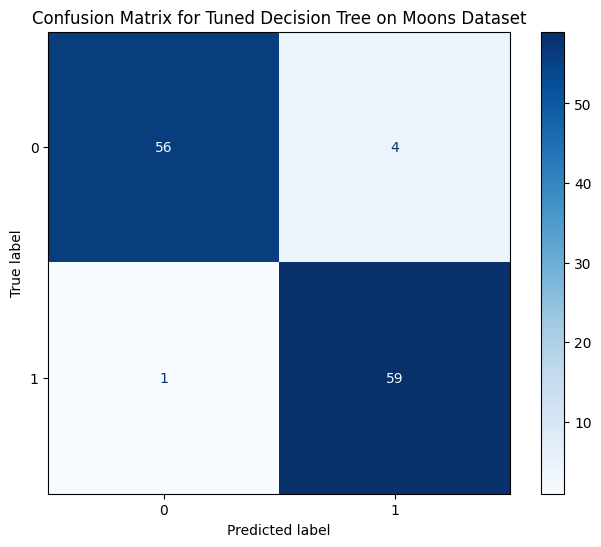

In [119]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8]
}

grid_search_dt_moons = GridSearchCV(DecisionTreeClassifier(random_state=random_state),
                                    param_grid_dt, cv=5, n_jobs=-1, verbose=1)

grid_search_dt_moons.fit(X_train_moons_scaled, y_train_moons)

print("\nBest parameters found:", grid_search_dt_moons.best_params_)
best_dt_moons = grid_search_dt_moons.best_estimator_


print("\n3. Evaluating the tuned Decision Tree model...")
y_pred_tuned_dt_moons = best_dt_moons.predict(X_test_moons_scaled)
tuned_accuracy_dt_moons = accuracy_score(y_test_moons, y_pred_tuned_dt_moons)

print(f"Tuned Decision Tree Accuracy: {tuned_accuracy_dt_moons:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_moons, y_pred_tuned_dt_moons, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_dt_moons, X_test_moons_scaled, y_test_moons, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Decision Tree on Moons Dataset')
plt.show()

Fine tuning the model din't really increased the accuracy. From the confusion matrix and comparing it to the best kernel SVM model we can see only 1 less instances was misclassified and most and it belonged to class 0.

#### 5.2.5.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundaries of the predictions.


4. Visualizing the Decision Boundary...


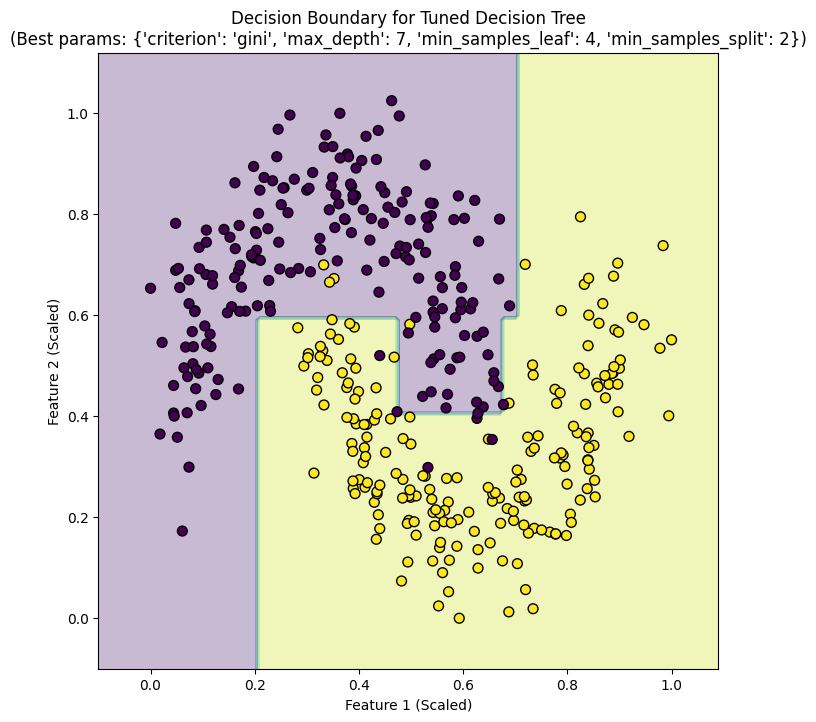

In [120]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_dt_moons, X_moons_scaled, y_moons_combined,
                       f'Decision Boundary for Tuned Decision Tree\n(Best params: {grid_search_dt_moons.best_params_})')

Even though the data was shaped like a moon and the kernel SVM managed to learn this pattern rather well, the decision tree tried to separate them with a few vertical and horizontal lines and despite getting slightly better result on the test data, I believe if we had a noisier data the SVM would be able to generalize better.

### 5.2.6. Random Forest

#### 5.2.6.1. Training

Here we will train a random forest and later tune its parameters, random forest consist of multiple decision trees that have each been train of a portion of the data and then the final decision is made majority voting, the reason we use multiple decision trees is to prevent them from over fitting, another advantage of the random forest is the fact that it usually doesn't need much tuning.

Since the data isn't quite linear and the kernel SVM got an accuracy of 94%, we expect the decision tree to also get a good 90+% accuracy on it.

In [121]:
print("--- Training Random Forest on Moons Dataset ---")

print("\n1. Training a baseline Random Forest model...")
rf_moons_base = RandomForestClassifier(random_state=random_state, n_jobs=-1)
rf_moons_base.fit(X_train_moons_scaled, y_train_moons)

y_pred_base_rf_moons = rf_moons_base.predict(X_test_moons_scaled)
base_accuracy_rf_moons = accuracy_score(y_test_moons, y_pred_base_rf_moons)
print(f"Baseline Random Forest Accuracy: {base_accuracy_rf_moons:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_moons, y_pred_base_rf_moons, zero_division=0))

--- Training Random Forest on Moons Dataset ---

1. Training a baseline Random Forest model...
Baseline Random Forest Accuracy: 0.9500
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        60
           1       0.94      0.97      0.95        60

    accuracy                           0.95       120
   macro avg       0.95      0.95      0.95       120
weighted avg       0.95      0.95      0.95       120



Just like the decision tree random forest without tuning managed to outperform the best kernel SVM by getting a 95% accuracy, next we will try to tune the parameters to see if we can improve this accuracy ro not.

#### 5.2.6.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters found: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

3. Evaluating the tuned Random Forest model...
Tuned Random Forest Accuracy: 0.9583
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96        60
           1       0.94      0.98      0.96        60

    accuracy                           0.96       120
   macro avg       0.96      0.96      0.96       120
weighted avg       0.96      0.96      0.96       120

Tuned Model Confusion Matrix:


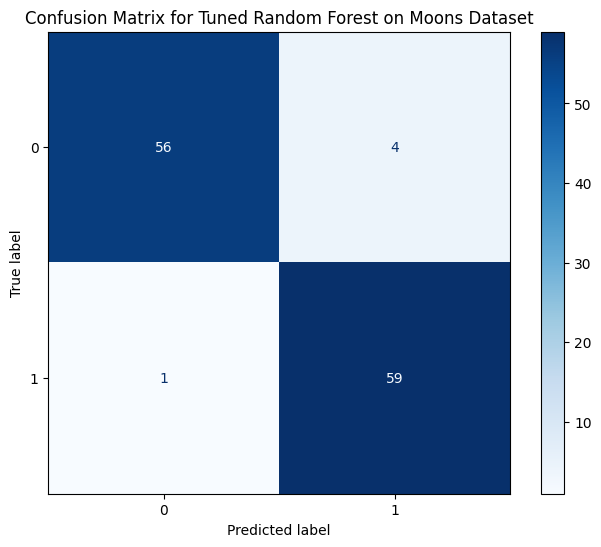

In [122]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_rf = {
    'n_estimators': [50, 100, 200, 300, 1000],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 7],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf_moons = GridSearchCV(RandomForestClassifier(random_state=random_state, n_jobs=-1),
                                    param_grid_rf, cv=5, n_jobs=-1, verbose=1)

grid_search_rf_moons.fit(X_train_moons_scaled, y_train_moons)

print("\nBest parameters found:", grid_search_rf_moons.best_params_)
best_rf_moons = grid_search_rf_moons.best_estimator_


print("\n3. Evaluating the tuned Random Forest model...")
y_pred_tuned_rf_moons = best_rf_moons.predict(X_test_moons_scaled)
tuned_accuracy_rf_moons = accuracy_score(y_test_moons, y_pred_tuned_rf_moons)

print(f"Tuned Random Forest Accuracy: {tuned_accuracy_rf_moons:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_moons, y_pred_tuned_rf_moons, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_rf_moons, X_test_moons_scaled, y_test_moons, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Random Forest on Moons Dataset')
plt.show()

Fine tuning the model only increased the accuracy by 1%. From the confusion matrix and comparing it to the best kernel SVM model we can see only 1 less instances was misclassified and most of them belonged to class 0.

#### 5.2.6.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundaries of the predictions.


4. Visualizing the Decision Boundary...


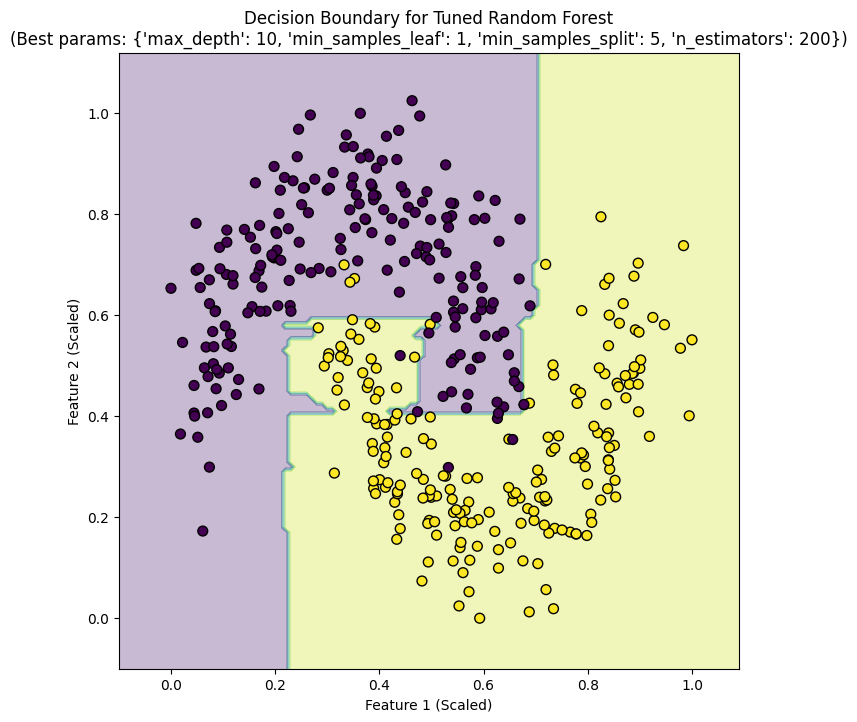

In [123]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_rf_moons, X_moons_scaled, y_moons_combined,
                       f'Decision Boundary for Tuned Random Forest\n(Best params: {grid_search_rf_moons.best_params_})')

Even though the data was shaped like a moon and the kernel SVM managed to learn this pattern rather well, the random forest tried to separate them with a square like shape and despite getting slightly better result on the test data, I believe if we had a noisier data the SVM would be able to generalize better.

### 5.2.7. KNN

#### 5.2.7.1. Training

KNN is fundamentally different from all the previous models. It's a non-parametric algorithm, meaning it doesn't try to learn a model or a function from the training data. Instead, it memorizes the entire training dataset.

Since the data isn't quite linear and the kernel SVM and random forest got an accuracy of 94% and 96% respectively, KNN might be able to perform well here.

In [148]:
print("--- Training K-Nearest Neighbors (KNN) on Moons Dataset ---")

print("\n1. Training a baseline KNN model (K=5)...")
knn_moons_base = KNeighborsClassifier(n_neighbors=5)
knn_moons_base.fit(X_train_moons_scaled, y_train_moons)

y_pred_base_knn_moons = knn_moons_base.predict(X_test_moons_scaled)
base_accuracy_knn_moons = accuracy_score(y_test_moons, y_pred_base_knn_moons)
print(f"Baseline KNN Accuracy: {base_accuracy_knn_moons:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_moons, y_pred_base_knn_moons, zero_division=0))

--- Training K-Nearest Neighbors (KNN) on Moons Dataset ---

1. Training a baseline KNN model (K=5)...
Baseline KNN Accuracy: 0.9667
Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        60
           1       0.97      0.97      0.97        60

    accuracy                           0.97       120
   macro avg       0.97      0.97      0.97       120
weighted avg       0.97      0.97      0.97       120



As we can see the baseline KNN without any tuning managed to get a 97% accuracy on this dataset which is the best result among all the models. We will try to improve this accuracy with hyperparameter tuning in the next section.

#### 5.2.7.2. Hyperparameter Tuning

Here we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardless of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters found: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}

3. Evaluating the tuned KNN model...
Tuned KNN Accuracy: 0.9667
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97        60
           1       0.95      0.98      0.97        60

    accuracy                           0.97       120
   macro avg       0.97      0.97      0.97       120
weighted avg       0.97      0.97      0.97       120

Tuned Model Confusion Matrix:


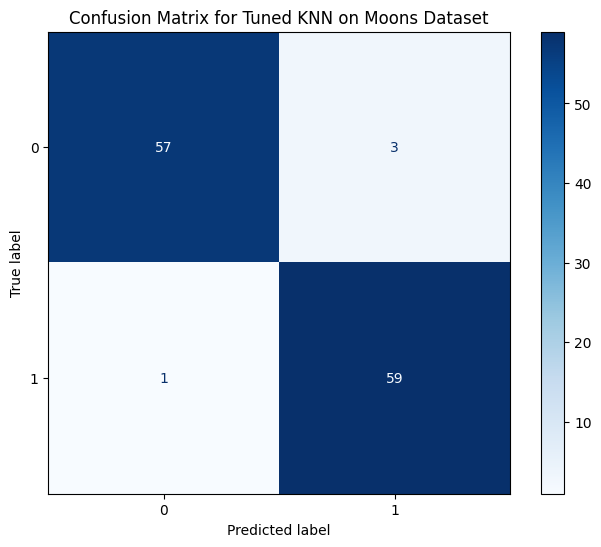

In [149]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_knn = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search_knn_moons = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, n_jobs=-1, verbose=1)

grid_search_knn_moons.fit(X_train_moons_scaled, y_train_moons)

print("\nBest parameters found:", grid_search_knn_moons.best_params_)
best_knn_moons = grid_search_knn_moons.best_estimator_

print("\n3. Evaluating the tuned KNN model...")
y_pred_tuned_knn_moons = best_knn_moons.predict(X_test_moons_scaled)
tuned_accuracy_knn_moons = accuracy_score(y_test_moons, y_pred_tuned_knn_moons)

print(f"Tuned KNN Accuracy: {tuned_accuracy_knn_moons:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_moons, y_pred_tuned_knn_moons, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_knn_moons, X_test_moons_scaled, y_test_moons, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned KNN on Moons Dataset')
plt.show()

Fine tuning the model didn't improve the accuracy and as we can see the best parameters found are the ones in the base model.

#### 5.2.7.3. Visualising the Predictions

Since we had only two features, we will use the previously defined function to visualise the decision boundaries of the predictions.


4. Visualizing the Decision Boundary...


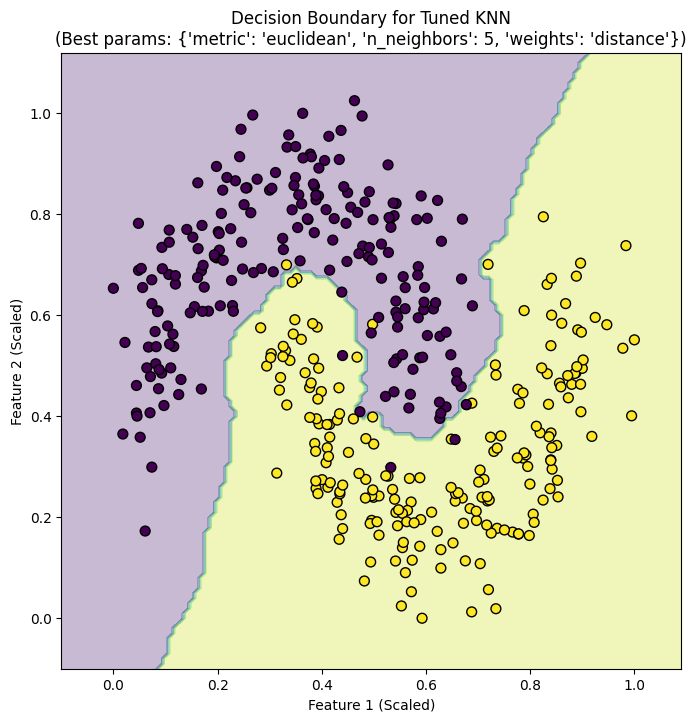

In [150]:
print("\n4. Visualizing the Decision Boundary...")

plot_decision_boundary(best_knn_moons, X_moons_scaled, y_moons_combined,
                       f'Decision Boundary for Tuned KNN\n(Best params: {grid_search_knn_moons.best_params_})')

Comparing to the other models, the KNN (and after that kernel SVM) was the best model with respect to modelling the boundaries, which is shown in its accuracy.

# 6. Hastie 10-2 (Higher-Dimensional Ambiguity)

## 6.1. Data Preprocessing

### 6.1.1. Creating the Dataset and Visualising

In [124]:
from sklearn.datasets import make_hastie_10_2
X_hastie, y_hastie = make_hastie_10_2(n_samples=500, random_state=21)

In [125]:
X_hastie.shape

(500, 10)

In [126]:
y_hastie.shape

(500,)

This datasets consitst of 500 data with 10 feature each, since it can't be directly plotted, we will have to use PCA to show its most important components (similar to one of the previous datasets)

X_hastie_pca shape after PCA: (500, 2)
Explained variance ratio by 2 components: [0.12108263 0.11729726]
Total explained variance by 2 components: 0.2384
['$\\mathdefault{−1}$', '$\\mathdefault{1}$']


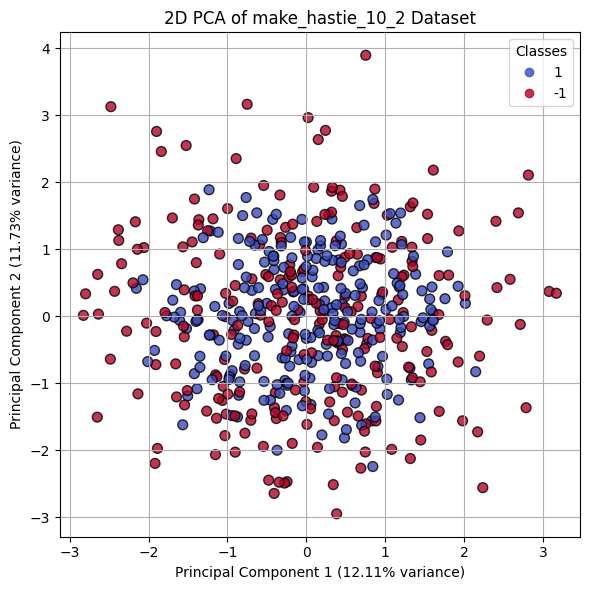

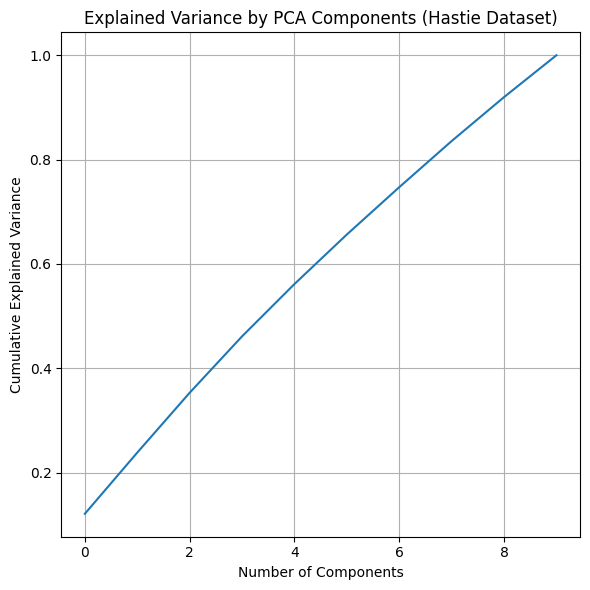

In [127]:
# Standardize the data (important for PCA)
scaler_hastie = StandardScaler()
X_hastie_scaled = scaler_hastie.fit_transform(X_hastie)

pca_hastie = PCA(n_components=2, random_state=random_state)
X_hastie_pca = pca_hastie.fit_transform(X_hastie_scaled)

print(f"X_hastie_pca shape after PCA: {X_hastie_pca.shape}") # (500, 2)
print(f"Explained variance ratio by 2 components: {pca_hastie.explained_variance_ratio_}")
print(f"Total explained variance by 2 components: {np.sum(pca_hastie.explained_variance_ratio_):.4f}")

plt.figure(figsize=(6, 6))
scatter = plt.scatter(X_hastie_pca[:, 0], X_hastie_pca[:, 1], c=y_hastie,
                      cmap='coolwarm', edgecolor='k', s=50, alpha=0.8)

plt.title('2D PCA of make_hastie_10_2 Dataset')
plt.xlabel(f'Principal Component 1 ({pca_hastie.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca_hastie.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.grid(True)

handles, labels = scatter.legend_elements()
print(labels)
class_labels_descriptive = [1, -1] # Converting string labels like "-1.0" to "Class -1"
plt.legend(handles, class_labels_descriptive, title="Classes")
plt.tight_layout()
plt.show()

pca_hastie_full = PCA(random_state=42)
pca_hastie_full.fit(X_hastie_scaled)
plt.figure(figsize=(6, 6))
plt.plot(np.cumsum(pca_hastie_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components (Hastie Dataset)')
plt.grid(True)
plt.tight_layout()
plt.show()

As we can see from the top plot, 2 axis are not enough to represnet the data in a seperable manner, and from the bottom graph we can see that in order to properly seperate the data (explain the variance) we are going to need all 10 features, thus we will be giving all the features to our models!

Now let's take a look at feature distribution

--- Overall Feature Distributions (Hastie Dataset) ---


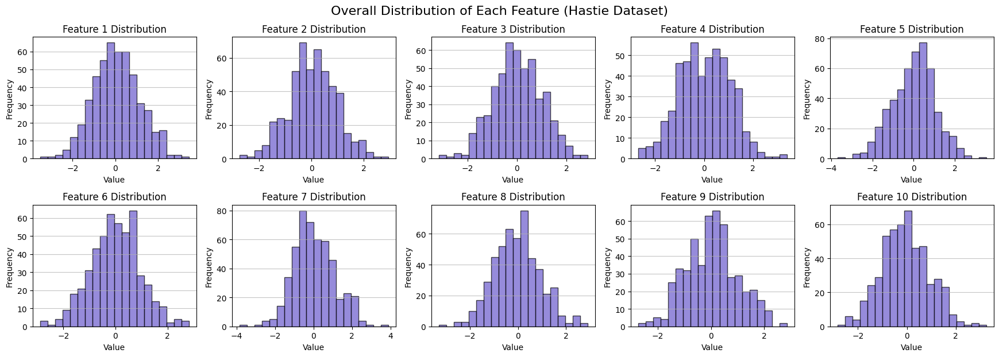


--- Feature Distributions by Class (Hastie Dataset) ---


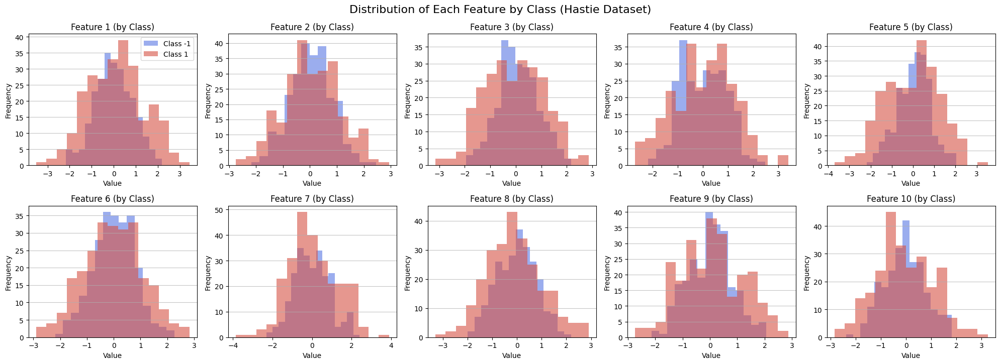

In [128]:
import matplotlib.pyplot as plt
import numpy as np

n_features_hastie = X_hastie.shape[1]

# --- Plotting Histograms for Each Feature (Overall Distribution) ---
print("--- Overall Feature Distributions (Hastie Dataset) ---")
n_cols_hastie = 5
n_rows_hastie = int(np.ceil(n_features_hastie / n_cols_hastie))

plt.figure(figsize=(n_cols_hastie * 3.5, n_rows_hastie * 3))
for i in range(n_features_hastie):
    plt.subplot(n_rows_hastie, n_cols_hastie, i + 1)
    plt.hist(X_hastie[:, i], bins=20, color='slateblue', edgecolor='black', alpha=0.7)
    plt.title(f'Feature {i+1} Distribution')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.suptitle('Overall Distribution of Each Feature (Hastie Dataset)', fontsize=16, y=1.03)
plt.show()


# --- Plotting Histograms for Each Feature, Separated by Class ---
print("\n--- Feature Distributions by Class (Hastie Dataset) ---")
unique_classes_hastie = np.unique(y_hastie)
colors_hastie = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(unique_classes_hastie)))

plt.figure(figsize=(n_cols_hastie * 4, n_rows_hastie * 3.5))
for i in range(n_features_hastie):
    plt.subplot(n_rows_hastie, n_cols_hastie, i + 1)
    for cls_idx, cls_label in enumerate(unique_classes_hastie):
        plt.hist(X_hastie[y_hastie == cls_label, i], bins=15, alpha=0.6,
                 label=f'Class {int(cls_label)}', color=colors_hastie[cls_idx])
    plt.title(f'Feature {i+1} (by Class)')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    if i == 0 :
        plt.legend()
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.suptitle('Distribution of Each Feature by Class (Hastie Dataset)', fontsize=16, y=1.03)
plt.show()

As we can see all features closly follow a normal distribtuion thus we will use a standard scalar to sacle them in the next section

### 6.1.2. Splitting & Scaling

Here we will split the data and use a standard scalar to scale them for later use in algorithms.

In [129]:
X_train_hastie, X_test_hastie, y_train_hastie, y_test_hastie = train_test_split(
    X_hastie, y_hastie, test_size=0.3, random_state=random_state, stratify=y_hastie
)
scaler_hastie = StandardScaler()

scaler_hastie.fit(X_train_hastie)

X_train_hastie_scaled = scaler_hastie.transform(X_train_hastie)
X_test_hastie_scaled = scaler_hastie.transform(X_test_hastie)

## 6.2. Model Training and Hyperparamter Tuning

### 6.2.1. Preceptron

#### 6.2.1.1. Training

Here we will train a simple preceptron and tune its parameters, since the data isn't very well linearly seperable (guessing based on how it was created), we don't excpect the preceptron to get a very high accuracy.

In [130]:
print("--- Training Perceptron on Hastie Dataset ---")
print("NOTE: This is a challenging 10D dataset; we are testing the Perceptron's performance in a high-dimensional space.")

print("\n1. Training a baseline Perceptron model...")
perceptron_hastie_base = Perceptron(random_state=random_state)
perceptron_hastie_base.fit(X_train_hastie_scaled, y_train_hastie)

y_pred_hastie_base = perceptron_hastie_base.predict(X_test_hastie_scaled)
base_accuracy_hastie = accuracy_score(y_test_hastie, y_pred_hastie_base)
print(f"Baseline Perceptron Accuracy: {base_accuracy_hastie:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_hastie, y_pred_hastie_base, zero_division=0))

--- Training Perceptron on Hastie Dataset ---
NOTE: This is a challenging 10D dataset; we are testing the Perceptron's performance in a high-dimensional space.

1. Training a baseline Perceptron model...
Baseline Perceptron Accuracy: 0.4800
Baseline Classification Report:
              precision    recall  f1-score   support

        -1.0       0.47      0.29      0.36        75
         1.0       0.49      0.67      0.56        75

    accuracy                           0.48       150
   macro avg       0.48      0.48      0.46       150
weighted avg       0.48      0.48      0.46       150



The simple model achieved a 48% accuracy which is average, but at the very least it didn't guess all instances as the same class which is better thant its performance on the circles dataset!

#### 6.2.1.2. Hyperparameter Tuning

To improve the preformance further we will preform a grid search to find the best hyperparameters, we will also use cross validation (cv = 5) to get a solid result regardell of the split.


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters found: {'alpha': 0.0001, 'eta0': 1.0, 'max_iter': 1000, 'penalty': 'elasticnet'}

3. Evaluating the tuned Perceptron model...
Tuned Perceptron Accuracy: 0.4733
Tuned Model Classification Report:
              precision    recall  f1-score   support

        -1.0       0.45      0.24      0.31        75
         1.0       0.48      0.71      0.57        75

    accuracy                           0.47       150
   macro avg       0.47      0.47      0.44       150
weighted avg       0.47      0.47      0.44       150

Tuned Model Confusion Matrix:


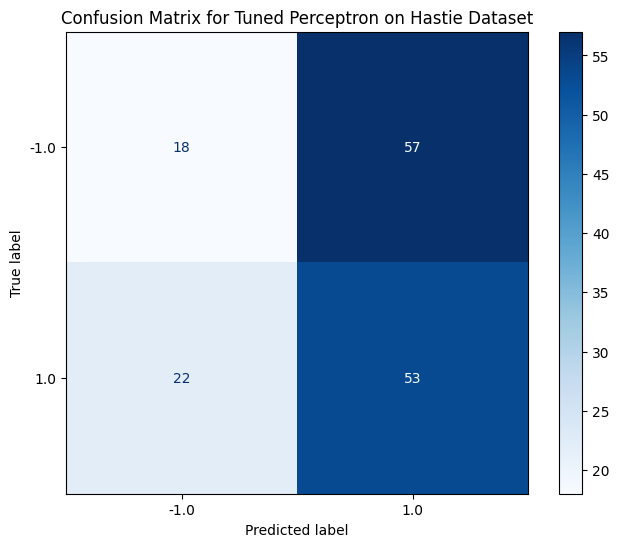

In [131]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_perceptron = {
    'eta0': [0.0001, 0.001, 0.01, 0.1, 1.0],
    'max_iter': [1000, 2000, 3000],
    'penalty': ['l2', 'l1', 'elasticnet', None],
    'alpha': [0.0001, 0.001, 0.01]
}

grid_search_hastie = GridSearchCV(Perceptron(random_state=random_state), param_grid_perceptron, cv=5, n_jobs=-1, verbose=1)
grid_search_hastie.fit(X_train_hastie_scaled, y_train_hastie)

print("\nBest parameters found:", grid_search_hastie.best_params_)
best_perceptron_hastie = grid_search_hastie.best_estimator_

print("\n3. Evaluating the tuned Perceptron model...")
y_pred_hastie_tuned = best_perceptron_hastie.predict(X_test_hastie_scaled)
tuned_accuracy_hastie = accuracy_score(y_test_hastie, y_pred_hastie_tuned)

print(f"Tuned Perceptron Accuracy: {tuned_accuracy_hastie:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_hastie, y_pred_hastie_tuned, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_perceptron_hastie, X_test_hastie_scaled, y_test_hastie, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Perceptron on Hastie Dataset')
plt.show()

Fine tuning the parameters didn't yield much results and it made the model regress tword guessing -1 for most of the examples (hence the imbalance between precision and recall) which is evident from the confustion matrix.

#### 6.2.1.3. Visualising the Predictions

Since we had 10 features, we can't really visualise the desicion boundry of the model in a meaningful way!

### 6.2.2. Logistic Regression

#### 6.2.2.1. Training

Here we will train a simple logistic regression and tune its parameters.

Based on the performance of the preceptron (48% accuracy) we can guess that the data isn't easily seperated with a line, so we excpect the accuracy of the logistic regression to be in the same ballpark.

In [132]:
print("--- Training Logistic Regression on Hastie Dataset ---")
print("NOTE: This is a challenging 10D dataset; we are testing Logistic Regression's performance in a high-dimensional space.")

print("\n1. Training a baseline Logistic Regression model...")
log_reg_hastie_base = LogisticRegression(random_state=random_state, max_iter=1000)
log_reg_hastie_base.fit(X_train_hastie_scaled, y_train_hastie)

y_pred_hastie_base_lr = log_reg_hastie_base.predict(X_test_hastie_scaled)
base_accuracy_hastie_lr = accuracy_score(y_test_hastie, y_pred_hastie_base_lr)
print(f"Baseline Logistic Regression Accuracy: {base_accuracy_hastie_lr:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_hastie, y_pred_hastie_base_lr, zero_division=0))

--- Training Logistic Regression on Hastie Dataset ---
NOTE: This is a challenging 10D dataset; we are testing Logistic Regression's performance in a high-dimensional space.

1. Training a baseline Logistic Regression model...
Baseline Logistic Regression Accuracy: 0.5000
Baseline Classification Report:
              precision    recall  f1-score   support

        -1.0       0.50      0.53      0.52        75
         1.0       0.50      0.47      0.48        75

    accuracy                           0.50       150
   macro avg       0.50      0.50      0.50       150
weighted avg       0.50      0.50      0.50       150



Logistic regression got a slightly higher accuracy (50%) but it's still as bad as randomly guessing the classes, idicating that the dataset isn't linearly seperable.

Next we will try to tune the parameters to see if we can improve this or not!

#### 6.2.2.2. Hyperparameter Tuning


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found: {'C': 1, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'liblinear'}

3. Evaluating the tuned Logistic Regression model...
Tuned Logistic Regression Accuracy: 0.5067
Tuned Model Classification Report:
              precision    recall  f1-score   support

        -1.0       0.51      0.55      0.53        75
         1.0       0.51      0.47      0.49        75

    accuracy                           0.51       150
   macro avg       0.51      0.51      0.51       150
weighted avg       0.51      0.51      0.51       150

Tuned Model Confusion Matrix:


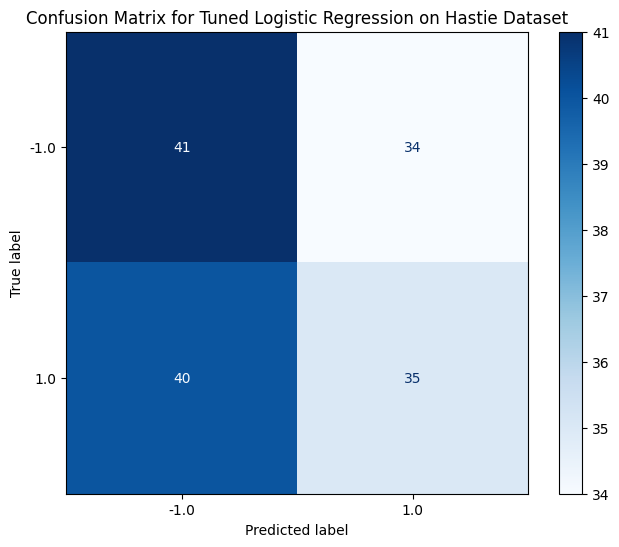

In [133]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_lr = [
    {
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'saga'],
        'max_iter': [2000, 3000]
    },
    {
        'penalty': ['elasticnet'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['saga'],
        'l1_ratio': [0.5],
        'max_iter': [2000, 3000]
    }
]

grid_search_hastie_lr = GridSearchCV(LogisticRegression(random_state=random_state),
                                     param_grid_lr, cv=5, n_jobs=-1, verbose=1)
grid_search_hastie_lr.fit(X_train_hastie_scaled, y_train_hastie)

print("\nBest parameters found:", grid_search_hastie_lr.best_params_)
best_log_reg_hastie = grid_search_hastie_lr.best_estimator_


print("\n3. Evaluating the tuned Logistic Regression model...")
y_pred_hastie_tuned_lr = best_log_reg_hastie.predict(X_test_hastie_scaled)
tuned_accuracy_hastie_lr = accuracy_score(y_test_hastie, y_pred_hastie_tuned_lr)

print(f"Tuned Logistic Regression Accuracy: {tuned_accuracy_hastie_lr:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_hastie, y_pred_hastie_tuned_lr, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_log_reg_hastie, X_test_hastie_scaled, y_test_hastie, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Logistic Regression on Hastie Dataset')
plt.show()

Even after fine tuning the parameters, the accuracy of the model increased only by 1 percent.

From the confusion matrix we can see that the model is reletaively balanced and it doesn't classify every data as a single class (heche the 0.49 f1-score)

#### 5.2.2.3. Visualising the Predictions

Due to the high dimensionality of the data, it could not be visualised!

### 6.2.3. SVM (no kernels!)

#### 6.2.3.1. Training

Here we will train a simple SVM and tune its parameters.

Based on the performance of the preceptron (48% accuracy) and logistic regression (51%) we can guess that the data isn't easily separated with a line, so we expect the accuracy of the SVM to be in the same ballpark.

In [134]:
print("--- Training Linear SVM on Hastie Dataset ---")

print("\n1. Training a baseline Linear SVM model...")
svm_hastie_base = SVC(kernel='linear', random_state=random_state)
svm_hastie_base.fit(X_train_hastie_scaled, y_train_hastie)

y_pred_base_svm_hastie = svm_hastie_base.predict(X_test_hastie_scaled)
base_accuracy_svm_hastie = accuracy_score(y_test_hastie, y_pred_base_svm_hastie)
print(f"Baseline Linear SVM Accuracy: {base_accuracy_svm_hastie:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_hastie, y_pred_base_svm_hastie, zero_division=0))

--- Training Linear SVM on Hastie Dataset ---

1. Training a baseline Linear SVM model...
Baseline Linear SVM Accuracy: 0.4867
Baseline Classification Report:
              precision    recall  f1-score   support

        -1.0       0.49      0.59      0.53        75
         1.0       0.48      0.39      0.43        75

    accuracy                           0.49       150
   macro avg       0.49      0.49      0.48       150
weighted avg       0.49      0.49      0.48       150



SVM got a about the same accuracy (49%) and it's still as bad as randomly guessing the classes, indicating that the dataset isn't linearly separable.

Next we will try to tune the parameters to see if we can improve this or not!

#### 6.2.3.2. Hyperparameter Tuning


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best parameters found: {'C': 1}

3. Evaluating the tuned Linear SVM model...
Tuned Linear SVM Accuracy: 0.4867
Tuned Model Classification Report:
              precision    recall  f1-score   support

        -1.0       0.49      0.59      0.53        75
         1.0       0.48      0.39      0.43        75

    accuracy                           0.49       150
   macro avg       0.49      0.49      0.48       150
weighted avg       0.49      0.49      0.48       150

Tuned Model Confusion Matrix:


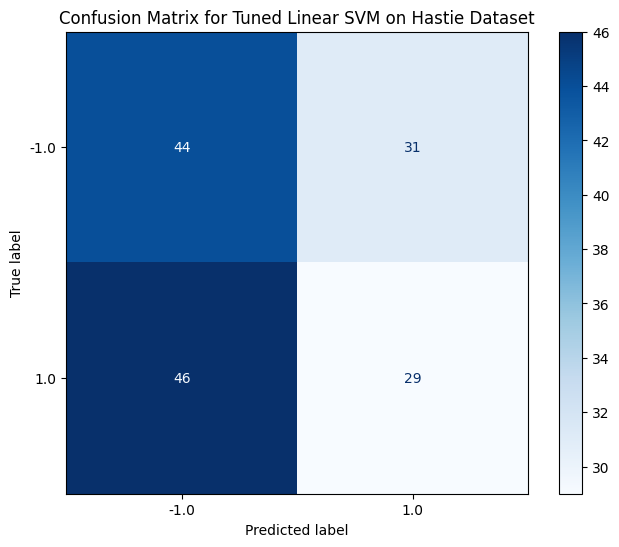

In [135]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_svm = {
    'C': [0.1, 1, 10, 100, 1000]
}

grid_search_svm_hastie = GridSearchCV(SVC(kernel='linear', random_state=random_state),
                                      param_grid_svm, cv=5, n_jobs=-1, verbose=1)

grid_search_svm_hastie.fit(X_train_hastie_scaled, y_train_hastie)

print("\nBest parameters found:", grid_search_svm_hastie.best_params_)
best_svm_hastie = grid_search_svm_hastie.best_estimator_


print("\n3. Evaluating the tuned Linear SVM model...")
y_pred_tuned_svm_hastie = best_svm_hastie.predict(X_test_hastie_scaled)
tuned_accuracy_svm_hastie = accuracy_score(y_test_hastie, y_pred_tuned_svm_hastie)

print(f"Tuned Linear SVM Accuracy: {tuned_accuracy_svm_hastie:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_hastie, y_pred_tuned_svm_hastie, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_svm_hastie, X_test_hastie_scaled, y_test_hastie, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Linear SVM on Hastie Dataset')
plt.show()

Even after fine tuning the parameters, the accuracy of the model didn't increase.

From the confusion matrix we can see that the model isn't balanced and it has trouble classifying instances of class 1 correctly

#### 5.2.3.3. Visualising the Predictions

Due to the high dimensionality of the data, it could not be visualised!

### 6.2.4. SVM (with kernels!)

#### 6.2.4.1. Training

Here we will train a simple SVM and tune its parameters.

Based on the performance of the preceptron (48% accuracy) and logistic regression (51%) and SVM (49%) we can guess that the data isn't easily separated with a line, so we expect the accuracy of the kernel SVM to be quite better.

In [136]:
print("--- Training Kernel SVM on Hastie Dataset ---")

print("\n1. Training a baseline Kernel SVM model (RBF kernel)...")
ksvm_hastie_base = SVC(random_state=random_state)
ksvm_hastie_base.fit(X_train_hastie_scaled, y_train_hastie)

y_pred_base_ksvm_hastie = ksvm_hastie_base.predict(X_test_hastie_scaled)
base_accuracy_ksvm_hastie = accuracy_score(y_test_hastie, y_pred_base_ksvm_hastie)
print(f"Baseline Kernel SVM Accuracy: {base_accuracy_ksvm_hastie:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_hastie, y_pred_base_ksvm_hastie, zero_division=0))

--- Training Kernel SVM on Hastie Dataset ---

1. Training a baseline Kernel SVM model (RBF kernel)...
Baseline Kernel SVM Accuracy: 0.9200
Baseline Classification Report:
              precision    recall  f1-score   support

        -1.0       0.90      0.95      0.92        75
         1.0       0.94      0.89      0.92        75

    accuracy                           0.92       150
   macro avg       0.92      0.92      0.92       150
weighted avg       0.92      0.92      0.92       150



As expected the kernel SVM outperformed previous models quite significantly by getting a 92% accuracy, showing that introducing some non linearity was indeed quite necessary.

Next we will try to tune the parameters to see if we can improve this or not!

#### 6.2.3.2. Hyperparameter Tuning


2. Performing Expanded Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best parameters found: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}

3. Evaluating the tuned Kernel SVM model...
Tuned Kernel SVM Accuracy: 0.9133
Tuned Model Classification Report:
              precision    recall  f1-score   support

        -1.0       0.91      0.92      0.91        75
         1.0       0.92      0.91      0.91        75

    accuracy                           0.91       150
   macro avg       0.91      0.91      0.91       150
weighted avg       0.91      0.91      0.91       150

Tuned Model Confusion Matrix:


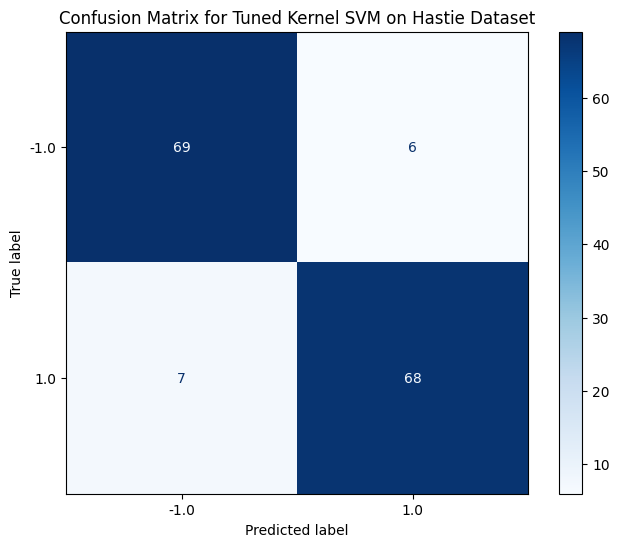

In [137]:
print("\n2. Performing Expanded Hyperparameter Tuning with GridSearchCV...")

param_grid_ksvm_expanded = [
    {'C': [0.001, 0.1, 1, 10, 100, 150], 'gamma': ['scale', 10, 1, 0.1, 0.01], 'kernel': ['rbf']},
    {'C': [0.001, 0.1, 1, 10, 100, 150], 'degree': [2, 3, 4], 'kernel': ['poly']},
    {'C': [0.001, 0.1, 1, 10, 100, 150], 'gamma': ['scale', 'auto'], 'kernel': ['sigmoid']}
]

grid_search_ksvm_hastie = GridSearchCV(SVC(random_state=random_state),
                                       param_grid_ksvm_expanded, cv=5, n_jobs=-1, verbose=1)

grid_search_ksvm_hastie.fit(X_train_hastie_scaled, y_train_hastie)

print("\nBest parameters found:", grid_search_ksvm_hastie.best_params_)
best_ksvm_hastie = grid_search_ksvm_hastie.best_estimator_


print("\n3. Evaluating the tuned Kernel SVM model...")
y_pred_tuned_ksvm_hastie = best_ksvm_hastie.predict(X_test_hastie_scaled)
tuned_accuracy_ksvm_hastie = accuracy_score(y_test_hastie, y_pred_tuned_ksvm_hastie)

print(f"Tuned Kernel SVM Accuracy: {tuned_accuracy_ksvm_hastie:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_hastie, y_pred_tuned_ksvm_hastie, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_ksvm_hastie, X_test_hastie_scaled, y_test_hastie, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Kernel SVM on Hastie Dataset')
plt.show()

After tuning the parameters the accuracy of the model didn't show any significant improvement, indicating that this is the limit of the separation we can do based on the given features, maybe with the use of some dimensionality reduction we would be able to distill the features and get better results.

#### 6.2.4.3. Visualising the Predictions

Due to the high dimensionality of the data, it could not be visualised!

### 6.2.5. Decision Tree

#### 6.2.5.1. Training

Here we will train a single decision tree and later tune its parameters, decision trees are quite prone to overfitting so in order to remedy this we need to carefully set the hyperparameters (or use random forests which is the next algorithm we will look at!)

This is a high dimensional and non linear dataset where all the nonlinear models from before got around 50% accuracy on it, but since the kernel SVM managed to get 90+% we can guess unless the decision tree overfits, it should be able to get a high accuracy.

In [138]:
print("--- Training Decision Tree on Hastie Dataset ---")

print("\n1. Training a baseline Decision Tree model...")
dt_hastie_base = DecisionTreeClassifier(random_state=random_state)
dt_hastie_base.fit(X_train_hastie_scaled, y_train_hastie)

y_pred_base_dt_hastie = dt_hastie_base.predict(X_test_hastie_scaled)
base_accuracy_dt_hastie = accuracy_score(y_test_hastie, y_pred_base_dt_hastie)
print(f"Baseline Decision Tree Accuracy: {base_accuracy_dt_hastie:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_hastie, y_pred_base_dt_hastie, zero_division=0))

--- Training Decision Tree on Hastie Dataset ---

1. Training a baseline Decision Tree model...
Baseline Decision Tree Accuracy: 0.6133
Baseline Classification Report:
              precision    recall  f1-score   support

        -1.0       0.62      0.60      0.61        75
         1.0       0.61      0.63      0.62        75

    accuracy                           0.61       150
   macro avg       0.61      0.61      0.61       150
weighted avg       0.61      0.61      0.61       150



As we can see the decision tree only got a 61% accuracy which is only 10% better than guessing randomly, I suspect this either because the hyperparameters aren't tuned or a single tree overfits on this dataset and we need to use a random forest (which we will see on the next algorithm)

#### 6.2.5.2. Hyperparameter Tuning


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 160 candidates, totalling 800 fits

Best parameters found: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 15}

3. Evaluating the tuned Decision Tree model...
Tuned Decision Tree Accuracy: 0.6400
Tuned Model Classification Report:
              precision    recall  f1-score   support

        -1.0       0.64      0.64      0.64        75
         1.0       0.64      0.64      0.64        75

    accuracy                           0.64       150
   macro avg       0.64      0.64      0.64       150
weighted avg       0.64      0.64      0.64       150

Tuned Model Confusion Matrix:


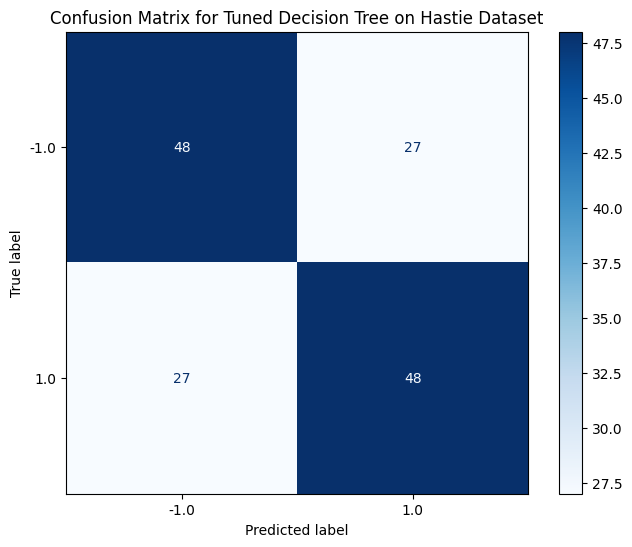

In [139]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8]
}

grid_search_dt_hastie = GridSearchCV(DecisionTreeClassifier(random_state=random_state),
                                     param_grid_dt, cv=5, n_jobs=-1, verbose=1)

grid_search_dt_hastie.fit(X_train_hastie_scaled, y_train_hastie)

print("\nBest parameters found:", grid_search_dt_hastie.best_params_)
best_dt_hastie = grid_search_dt_hastie.best_estimator_


print("\n3. Evaluating the tuned Decision Tree model...")
y_pred_tuned_dt_hastie = best_dt_hastie.predict(X_test_hastie_scaled)
tuned_accuracy_dt_hastie = accuracy_score(y_test_hastie, y_pred_tuned_dt_hastie)

print(f"Tuned Decision Tree Accuracy: {tuned_accuracy_dt_hastie:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_hastie, y_pred_tuned_dt_hastie, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_dt_hastie, X_test_hastie_scaled, y_test_hastie, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Decision Tree on Hastie Dataset')
plt.show()

Even after tuning the hyperparameters we only managed to increase the accuracy by only 3% which is still quite bad, this could be due to the fact that the tree has overfitted in this complex dataset.

#### 6.2.5.3. Visualising the Predictions

Due to the high dimensionality of the data, it could not be visualised!

### 6.2.6. Random Forest

#### 6.2.6.1. Training

Here we will train a random forest and later tune its parameters, random forest consist of multiple decision trees that have each been train of a portion of the data and then the final decision is made majority voting, the reason we use multiple decision trees is to prevent them from over fitting, another advantage of the random forest is the fact that it usually doesn't need much tuning.

This is a high dimensional and non linear dataset where all the nonlinear models from before got around 50% accuracy on it, and since the decision tree managed to get 61% accuracy we can guess using multple decision tree should be able to get a high accuracy.

In [140]:
print("--- Training Random Forest on Hastie Dataset ---")

print("\n1. Training a baseline Random Forest model...")
rf_hastie_base = RandomForestClassifier(random_state=random_state, n_jobs=-1)
rf_hastie_base.fit(X_train_hastie_scaled, y_train_hastie)

y_pred_base_rf_hastie = rf_hastie_base.predict(X_test_hastie_scaled)
base_accuracy_rf_hastie = accuracy_score(y_test_hastie, y_pred_base_rf_hastie)
print(f"Baseline Random Forest Accuracy: {base_accuracy_rf_hastie:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_hastie, y_pred_base_rf_hastie, zero_division=0))

--- Training Random Forest on Hastie Dataset ---

1. Training a baseline Random Forest model...
Baseline Random Forest Accuracy: 0.7467
Baseline Classification Report:
              precision    recall  f1-score   support

        -1.0       0.75      0.73      0.74        75
         1.0       0.74      0.76      0.75        75

    accuracy                           0.75       150
   macro avg       0.75      0.75      0.75       150
weighted avg       0.75      0.75      0.75       150



The random forest managed to ge an accuracy of 75% in this dataset, improving a single decision tree by 14% but still falls well short of the 90+% accuracy of the kernel SVM, indicating that there might be some sort of nonlinear relation in the dataset that the vertical and horizontal lines of the random forests can't model.

#### 6.2.6.2. Hyperparameter Tuning


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters found: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 100}

3. Evaluating the tuned Random Forest model...
Tuned Random Forest Accuracy: 0.7400
Tuned Model Classification Report:
              precision    recall  f1-score   support

        -1.0       0.77      0.68      0.72        75
         1.0       0.71      0.80      0.75        75

    accuracy                           0.74       150
   macro avg       0.74      0.74      0.74       150
weighted avg       0.74      0.74      0.74       150

Tuned Model Confusion Matrix:


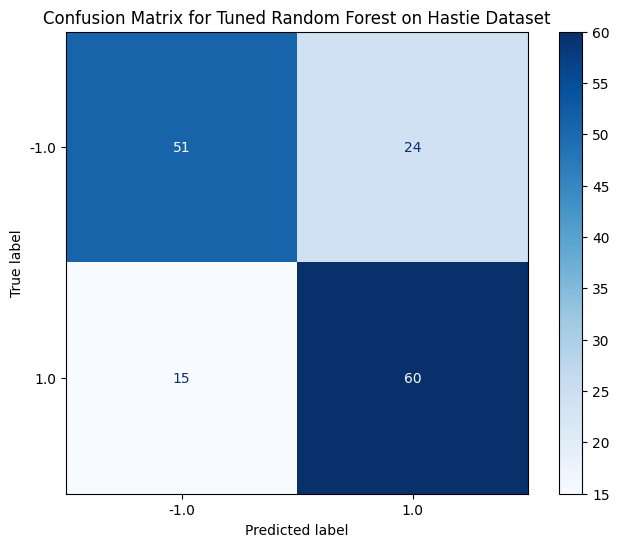

In [141]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_rf = {
    'n_estimators': [50, 100, 200, 300, 1000],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 7],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf_hastie = GridSearchCV(RandomForestClassifier(random_state=random_state, n_jobs=-1),
                                     param_grid_rf, cv=5, n_jobs=-1, verbose=1)

grid_search_rf_hastie.fit(X_train_hastie_scaled, y_train_hastie)

print("\nBest parameters found:", grid_search_rf_hastie.best_params_)
best_rf_hastie = grid_search_rf_hastie.best_estimator_


print("\n3. Evaluating the tuned Random Forest model...")
y_pred_tuned_rf_hastie = best_rf_hastie.predict(X_test_hastie_scaled)
tuned_accuracy_rf_hastie = accuracy_score(y_test_hastie, y_pred_tuned_rf_hastie)

print(f"Tuned Random Forest Accuracy: {tuned_accuracy_rf_hastie:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_hastie, y_pred_tuned_rf_hastie, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_rf_hastie, X_test_hastie_scaled, y_test_hastie, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned Random Forest on Hastie Dataset')
plt.show()

Even after tuning the hyperparameters we didn't managed to increase the accuracy.

#### 6.2.6.3. Visualising the Predictions

Due to the high dimensionality of the data, it could not be visualised!

#### 6.2.7. KNN

KNN is fundamentally different from all the previous models. It's a non-parametric algorithm, meaning it doesn't try to learn a model or a function from the training data. Instead, it memorizes the entire training dataset.

This is a high dimensional and non linear dataset where all the previous models other than random forest (75%) and kernel SVM (90+%) have performed poorly on. Due to the high dimensionality of the dataset, there's a good chance that KNN would perform poorly too, since in higher dimensions distance might not be as meaning full.

In [151]:
print("--- Training K-Nearest Neighbors (KNN) on Hastie Dataset ---")

print("\n1. Training a baseline KNN model (K=5)...")
knn_hastie_base = KNeighborsClassifier(n_neighbors=5)
knn_hastie_base.fit(X_train_hastie_scaled, y_train_hastie)

y_pred_base_knn_hastie = knn_hastie_base.predict(X_test_hastie_scaled)
base_accuracy_knn_hastie = accuracy_score(y_test_hastie, y_pred_base_knn_hastie)
print(f"Baseline KNN Accuracy: {base_accuracy_knn_hastie:.4f}")
print("Baseline Classification Report:")
print(classification_report(y_test_hastie, y_pred_base_knn_hastie, zero_division=0))

--- Training K-Nearest Neighbors (KNN) on Hastie Dataset ---

1. Training a baseline KNN model (K=5)...
Baseline KNN Accuracy: 0.5867
Baseline Classification Report:
              precision    recall  f1-score   support

        -1.0       0.55      0.99      0.70        75
         1.0       0.93      0.19      0.31        75

    accuracy                           0.59       150
   macro avg       0.74      0.59      0.51       150
weighted avg       0.74      0.59      0.51       150



As excepted KNN got a low 59% accuracy, in order to improve it we will try to tune the hyperparameters.

#### 6.2.7.2. Hyperparameter Tuning


2. Performing Hyperparameter Tuning with GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

Best parameters found: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}

3. Evaluating the tuned KNN model...
Tuned KNN Accuracy: 0.6667
Tuned Model Classification Report:
              precision    recall  f1-score   support

        -1.0       0.61      0.92      0.73        75
         1.0       0.84      0.41      0.55        75

    accuracy                           0.67       150
   macro avg       0.72      0.67      0.64       150
weighted avg       0.72      0.67      0.64       150

Tuned Model Confusion Matrix:


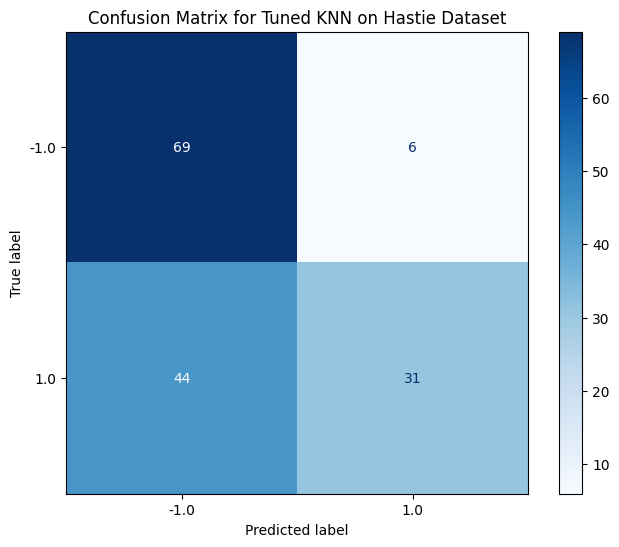

In [152]:
print("\n2. Performing Hyperparameter Tuning with GridSearchCV...")

param_grid_knn = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search_knn_hastie = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, n_jobs=-1, verbose=1)

grid_search_knn_hastie.fit(X_train_hastie_scaled, y_train_hastie)

print("\nBest parameters found:", grid_search_knn_hastie.best_params_)
best_knn_hastie = grid_search_knn_hastie.best_estimator_


print("\n3. Evaluating the tuned KNN model...")
y_pred_tuned_knn_hastie = best_knn_hastie.predict(X_test_hastie_scaled)
tuned_accuracy_knn_hastie = accuracy_score(y_test_hastie, y_pred_tuned_knn_hastie)

print(f"Tuned KNN Accuracy: {tuned_accuracy_knn_hastie:.4f}")
print("Tuned Model Classification Report:")
print(classification_report(y_test_hastie, y_pred_tuned_knn_hastie, zero_division=0))

print("Tuned Model Confusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_knn_hastie, X_test_hastie_scaled, y_test_hastie, ax=ax, cmap='Blues')
plt.title('Confusion Matrix for Tuned KNN on Hastie Dataset')
plt.show()